# 모델 만들기

## Autograd
텐서(Tensor)에서 모든 연산에 대해 자동 미분 순전파(Forward) 그래프에 의해 역전파(Backward) 그래프가 자동으로 정의됩니다!

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 모델의 심장, Autograd 완벽 이해]
#
# [개념적 개요]
# Autograd는 '자동 미분' 시스템으로, 딥러닝 모델이 학습하는 원리인 '역전파(Backpropagation)'를 자동으로 계산해주는 마법 같은 도구입니다.
# 모델이 예측을 틀렸을 때, 각 부품(가중치, 파라미터)들이 얼마나 잘못에 책임이 있는지(기울기, Gradient)를 알아서 계산해줍니다.
# 모델은 이 '책임량(기울기)'을 보고 자신을 수정하며 점점 똑똑해집니다.
#
# [핵심 비유: 레스토랑 주방의 총주방장]
# - 텐서(requires_grad=True): 레시피에 따라 맛을 내는 '요리사'들.
# - 연산(+, *): 요리사들이 재료를 섞는 '요리 과정'.
# - 최종 결과(f): 완성된 '요리'.
# - Autograd: 완성된 요리의 맛을 보고(최종 결과 f), 각 요리 과정과 요리사(텐서)들이 맛에 얼마나 영향을 미쳤는지(기울기)를
#             정확히 역추적하여 계산해내는 '총주방장'.
# ====================================================================================================


# --- 1. 방법 1: `torch.autograd.grad` - 원하는 변수만 콕 집어 미분하기 ---
# [흐름] 특정 결과에 대해, 특정 입력 변수들이 미치는 영향(기울기)만을 명시적으로 계산하는 방법입니다.

# [구동 과정] `torch` 라이브러리를 현재 작업 환경으로 가져옵니다.
import torch
# [구동 과정] `torch.autograd` 모듈에서 기울기 계산 전용 함수인 `grad`를 가져옵니다.
from torch.autograd import grad

In [ ]:
# --- [1-1. 계산에 사용할 변수(텐서) 준비] ---
# [구동 과정] `torch.tensor()` 함수를 사용해 숫자 2.0을 담은 텐서 객체를 생성합니다.
#            `requires_grad=True` 옵션은 Autograd 시스템에게 "지금부터 이 `x1` 텐서와 관련된 모든 연산을 추적해줘!" 라고 지시하는 스위치입니다.
#            이 스위치가 켜져야만 나중에 기울기를 계산할 수 있습니다. `x1` 변수에 이 텐서가 저장됩니다.
x1 = torch.tensor(2., requires_grad=True)
# [구동 과정] 위와 동일하게, 숫자 3.0을 담고 기울기 추적이 활성화된 텐서를 생성하여 `x2` 변수에 저장합니다.
x2 = torch.tensor(3., requires_grad=True)
# [구동 과정] 숫자 1.0을 담고 기울기 추적이 활성화된 텐서를 생성하여 `x3` 변수에 저장합니다.
x3 = torch.tensor(1., requires_grad=True)
# [구동 과정] 숫자 4.0을 담고 기울기 추적이 활성화된 텐서를 생성하여 `x4` 변수에 저장합니다.
x4 = torch.tensor(4., requires_grad=True)

# --- [1-2. 순전파(Forward Pass) 연산 및 계산 그래프 생성] ---
# [흐름] 입력 변수들을 이용해 최종 결과값 `f`를 만들어가는 과정입니다.
#      Autograd는 이 모든 과정을 뒤에서 지켜보며 '계산 그래프(Computational Graph)'라는 연결도를 머릿속에 그립니다.

# [구동 과정] `x1`의 값(2.0)과 `x2`의 값(3.0)을 곱합니다.
#            Autograd는 이 곱셈 연산을 기억하고, 그 결과(6.0)를 담은 새로운 텐서 `z1`을 생성합니다.
#            `z1` 텐서는 자신이 `x1`과 `x2`의 곱셈으로 만들어졌다는 '족보(history)'를 갖게 됩니다.
z1 = x1 * x2
# [구동 과정] `x3`의 값(1.0)과 `x4`의 값(4.0)을 곱합니다.
#            그 결과(4.0)를 담은 새로운 텐서 `z2`가 생성되며, `z2` 역시 자신의 '족보'를 기억합니다.
z2 = x3 * x4
# [구동 과정] `z1`의 값(6.0)과 `z2`의 값(4.0)을 더합니다.
#            그 최종 결과(10.0)를 담은 텐서 `f`가 생성됩니다. `f`는 자신이 `z1`과 `z2`의 덧셈으로 만들어졌음을 기억합니다.
# [최종 상태] Autograd는 `x1, x2 -> z1`, `x3, x4 -> z2`, `z1, z2 -> f` 로 이어지는 전체 계산 흐름도를 완성했습니다.
f = z1 + z2

# --- [1-3. `grad` 함수로 기울기 계산] ---
# [흐름] 완성된 계산 그래프를 거꾸로 탐색하여, 우리가 지정한 입력 변수들의 기울기를 계산합니다.

# [구동 과정] `grad` 함수를 호출합니다.
# `outputs=f`: "최종 목표는 `f`다. `f`에서부터 계산을 시작해라."
# `inputs=[x1, x2, x3, x4]`: "내가 알고 싶은 기울기는 `x1`, `x2`, `x3`, `x4` 이 4개 변수에 대한 것이다."
# Autograd는 `f`에서부터 계산 그래프를 역으로 따라가면서, 각 단계에서 미분의 연쇄 법칙(Chain Rule)을 적용합니다.
# (예: ∂f/∂x1 = (∂f/∂z1) * (∂z1/∂x1))
# 계산된 4개의 기울기 값을 튜플 형태로 묶어서 `df_dx` 변수에 저장합니다.
df_dx = grad(outputs=f, inputs=[x1, x2, x3, x4])

# --- [1-4. 결과 확인] ---
# [구동 과정] `df_dx` 튜플 전체를 출력합니다.
print(f'gradients: {df_dx}')
# [구동 과정] `df_dx` 튜플의 첫 번째 원소(x1의 기울기)를 출력합니다. ∂f/∂x1 = x2 = 3.0
print(f'gradients: of x1 = {df_dx[0]}')
# [구동 과정] `df_dx` 튜플의 두 번째 원소(x2의 기울기)를 출력합니다. ∂f/∂x2 = x1 = 2.0
print(f'gradients: of x2 = {df_dx[1]}')
# [구동 과정] `df_dx` 튜플의 세 번째 원소(x3의 기울기)를 출력합니다. ∂f/∂x3 = x4 = 4.0
print(f'gradients: of x3 = {df_dx[2]}')
# [구동 과정] `df_dx` 튜플의 네 번째 원소(x4의 기울기)를 출력합니다. ∂f/∂x4 = x3 = 1.0
print(f'gradients: of x4 = {df_dx[3]}')

gradients: (tensor(3.), tensor(2.), tensor(4.), tensor(1.))
gradients: of x1 = 3.0
gradients: of x2 = 2.0
gradients: of x3 = 4.0
gradients: of x4 = 1.0


In [ ]:
# --- 2. 방법 2: `.backward()` - 일반적인 모델 학습의 표준 ---
# [흐름] 최종 결과로부터 연결된 모든 변수들의 기울기를 한 번에 계산하여 각 변수에 직접 저장하는, 가장 보편적인 방법입니다.

# [구동 과정] `torch`와 `torch.optim` 모듈을 가져옵니다. `optim`은 경사하강법 등 최적화 알고리즘을 담고 있습니다.
import torch
import torch.optim as optim

# --- [2-1. 변수(텐서) 및 옵티마이저 준비] ---
# [구동 과정] 방법 1과 동일하게, 기울기 추적이 활성화된 4개의 텐서를 생성하여 각 변수에 저장합니다.
x1 = torch.tensor(2., requires_grad=True)
x2 = torch.tensor(3., requires_grad=True)
x3 = torch.tensor(1., requires_grad=True)
x4 = torch.tensor(4., requires_grad=True)

# [구동 과정] `optim.SGD` 클래스로 옵티마이저 객체를 생성하여 `opt` 변수에 저장합니다.
# `params=[x1, x2, x3, x4]`: 옵티마이저에게 "앞으로 네가 관리하고 업데이트할 파라미터는 이 4개야" 라고 알려줍니다.
# `lr=0.001`: 학습률(learning rate)을 0.001로 설정합니다. 나중에 `.step()`이 호출될 때 이 값만큼 파라미터를 수정하게 됩니다.
opt = optim.SGD(params=[x1, x2, x3, x4], lr=0.001)

# [구동 과정] `opt` 옵티마이저의 `zero_grad()` 메서드를 호출합니다.
# 이 메서드는 자신이 관리하는 모든 파라미터(`x1`~`x4`)를 찾아가, 각 파라미터의 `.grad` 속성 값을 0 또는 None으로 깨끗하게 지웁니다.
# 이는 이전 계산에서 남은 기울기 값이 다음 계산에 영향을 주지 않도록 하기 위한 필수적인 '청소' 과정입니다.
opt.zero_grad()

# --- [2-2. 순전파(Forward Pass) 연산] ---
# [구동 과정] 방법 1과 동일하게, `x1`부터 `f`까지의 연산을 수행하며 Autograd가 계산 그래프를 생성합니다.
z1 = x1 * x2
z2 = x3 * x4
f = z1 + z2

# --- [2-3. `.backward()`로 기울기 계산] ---
# [흐름] 총주방장이 "전원, 각자 책임 소재를 파악하라!"고 외치는 것과 같습니다.

# [구동 과정] 최종 결과 텐서 `f`의 `backward()` 메서드를 호출합니다.
# 1. Autograd는 `f`에서부터 시작하여, `f`와 연결된 계산 그래프를 거꾸로 탐색합니다.
# 2. 역방향으로 진행하며 만나는 모든 텐서(`z1`, `z2`, `x1`, `x2`, `x3`, `x4`)에 대해 기울기를 계산합니다.
# 3. 계산된 기울기 값을 각 텐서의 `.grad`라는 속성(저장 공간)에 직접 저장합니다.
#    (예: `x1`의 기울기 3.0이 계산되어 `x1.grad`에 저장됨)
# 4. 이 과정은 `requires_grad=True`로 설정된 모든 텐서에 대해 자동으로 수행됩니다.
f.backward()

# [구동 과정] 주석 처리되어 실행되지 않습니다. 만약 실행된다면, `opt` 옵티마이저는 자신이 관리하는 파라미터들의 `.grad` 값을 보고
#            `새 파라미터 = 기존 파라미터 - 학습률(lr) * 기울기(.grad)` 공식에 따라 파라미터 값을 업데이트합니다.
opt.step()

# --- [2-4. 결과 확인] ---
print(f'\ngradients')
# [구동 과정] `x1` 텐서의 `.grad` 속성에 저장된 값을 출력합니다. `f.backward()` 호출 시 3.0이 저장되었습니다.
print(f'gradients: of x1 = {x1.grad}')
# [구동 과정] `x2` 텐서의 `.grad` 속성에 저장된 값을 출력합니다. 2.0이 저장되었습니다.
print(f'gradients: of x2 = {x2.grad}')
# [구동 과정] `x3` 텐서의 `.grad` 속성에 저장된 값을 출력합니다. 4.0이 저장되었습니다.
print(f'gradients: of x3 = {x3.grad}')
# [구동 과정] `x4` 텐서의 `.grad` 속성에 저장된 값을 출력합니다. 1.0이 저장되었습니다.
print(f'gradients: of x4 = {x4.grad}')

# backward() 메서드의 특징:
# - requires_grad=True로 설정된 모든 변수의 기울기를 자동으로 계산합니다.
# - 계산된 기울기는 각 변수의 .grad 속성에 저장됩니다.
# - opt.zero_grad()를 사용해 이전 계산의 기울기 값을 초기화해야 누적된 기울기를 방지할 수 있습니다.
# - 장점: 코드가 간결하며, 다수의 변수에 대해 빠르게 기울기를 계산할 수 있습니다.


gradients
gradients: of x1 = 3.0
gradients: of x2 = 2.0
gradients: of x3 = 4.0
gradients: of x4 = 1.0


In [ ]:
# --- 3. [심화] 기울기 초기화(`zero_grad`)의 중요성 ---
# [흐름] 만약 옵티마이저가 기울기를 청소(`zero_grad`)해주지 않으면 어떤 일이 벌어지는지 직접 확인합니다.

# [구동 과정] 필요한 라이브러리를 다시 가져오고, 4개의 텐서와 옵티마이저를 새로 생성합니다.
import torch
import torch.optim as optim

x1 = torch.tensor(2., requires_grad=True)
x2 = torch.tensor(3., requires_grad=True)
x3 = torch.tensor(1., requires_grad=True)
x4 = torch.tensor(4., requires_grad=True)
opt = optim.SGD(params=[x1, x2, x3, x4], lr=0.001)

# [구동 과정] `for` 반복문이 3번 실행되도록 시작합니다.
for i in range(3):
    # [주목!] `opt.zero_grad()` 호출 부분이 주석 처리되어 실행되지 않습니다.
    # 즉, 기울기를 청소하는 과정이 생략됩니다.

    # [구동 과정] 순전파 연산을 통해 `f`를 계산합니다. (매번 동일한 계산)
    z1 = x1 * x2
    z2 = x3 * x4
    f = z1 + z2

    # [구동 과정] `f.backward()`를 호출하여 기울기를 계산합니다.
    # PyTorch의 기본 동작 방식은, `.grad` 속성에 이미 값이 있으면 새로 계산된 기울기를 거기에 '더합니다'(누적).
    f.backward()
    # [주석처리됨] opt.step()

    # [구동 과정] `i`값과 함께 각 텐서의 `.grad` 속성 값을 출력합니다.
    print(f'\n--- Iteration {i+1} ---')
    # 첫 번째 반복: x1.grad는 3.0이 됨.
    # 두 번째 반복: 기존 x1.grad(3.0)에 새로 계산된 3.0이 더해져 6.0이 됨.
    # 세 번째 반복: 기존 x1.grad(6.0)에 새로 계산된 3.0이 더해져 9.0이 됨.
    print(f'gradients: of x1 = {x1.grad}')
    print(f'gradients: of x2 = {x2.grad}')
    print(f'gradients: of x3 = {x3.grad}')
    print(f'gradients: of x4 = {x4.grad}')
# [결론] 기울기 초기화 없이는, 매번 계산된 기울기가 이전 값에 계속 더해져 엉뚱한 값으로 커집니다.
#       이는 모델 학습을 완전히 잘못된 방향으로 이끌기 때문에, 학습 루프 시작 시 `optimizer.zero_grad()`는 필수입니다.

# 기울기 누적 현상에 대한 상세 설명:
# 1. 초기화 없음: opt.zero_grad()가 없으면, 이전 계산의 기울기가 .grad 속성에 누적됩니다.
# 2. 기울기 누적 메커니즘:
#    - 첫 번째 반복: x1.grad = 3
#    - 두 번째 반복: x1.grad = 3 + 3 = 6 (누적)
#    - 세 번째 반복: x1.grad = 6 + 3 = 9 (누적)
# 3. 문제점: 누적된 기울기는 잘못된 방향과 크기로 매개변수를 업데이트하게 만듭니다.
# 4. 해결책: 모델 학습 시에는 항상 opt.zero_grad()를 사용해 기울기를 초기화해야 합니다.

# 두 방법의 차이점에 대한 심층 분석:
#
# torch.autograd.grad:
# - 명시적으로 지정한 inputs에 대한 기울기만 계산합니다.
# - 기울기를 반환값으로 받아 사용할 수 있습니다.
# - 계산 후 계산 그래프를 유지하지 않습니다 (create_graph=False가 기본값).
# - 메모리 효율적이지만, 여러 번 기울기를 계산해야 할 때는 비효율적일 수 있습니다.
#
# .backward():
# - requires_grad=True인 모든 텐서의 기울기를 계산합니다.
# - 기울기를 .grad 속성에 저장합니다.
# - 계산 그래프를 기본적으로 해제합니다 (메모리 freed).
# - 일반적인 학습 루프에서 더 편리하게 사용할 수 있습니다.
#
# 사용 시나리오 비교:
# - torch.autograd.grad: 2차 미분(hessian) 계산, 특정 변수에 대한 기울기만 필요한 경우
# - .backward(): 일반적인 신경망 학습, 모든 매개변수에 대한 기울기가 필요한 경우

# 추가 중요한 개념:
# 1. 계산 그래프 메모리 관리:
#    - 기본적으로 backward() 호출 후 계산 그래프는 자동으로 해제됩니다.
#    - retain_graph=True를 설정하면 그래프를 유지할 수 있습니다.
#
# 2. 비선형 함수의 미분:
#    - Autograd는 다양한 함수의 미분 법칙을 내장하고 있습니다.
#    - ReLU, Sigmoid, Tanh 등 활성화 함수의 미분도 자동으로 처리합니다.
#
# 3. 고차 미분:
#    - create_graph=True를 설정하면 2차 미분도 계산할 수 있습니다.
#    - 이는 hessian 행렬 계산이나 메타 학습에 사용됩니다.

# 실제 신경망 학습에서의 적용:
# 대부분의 파이토치 학습 루프는 다음과 같은 패턴을 따릅니다:
#
# for epoch in range(num_epochs):
#     for inputs, targets in dataloader:
#         optimizer.zero_grad()  # 기울기 초기화
#         outputs = model(inputs)  # 순전파
#         loss = criterion(outputs, targets)  # 손실 계산
#         loss.backward()  # 역전파 (기울기 계산)
#         optimizer.step()  # 매개변수 업데이트
#
# 이 패턴에서 backward()와 zero_grad()의 역할이 매우 중요합니다.

#     차이점 및 설명
# 1. **초기화 없음**: `opt.zero_grad()`가 없으면, 이전 계산의 기울기가 `.grad` 속성에 누적됩니다.
# 2. **기울기 누적**: 반복마다 기울기가 더해져, 계산 값이 점점 증가합니다. 이는 잘못된 학습 결과를 초래할 수 있습니다.
# 3. **초기화 필요성**: 모델 학습 시에는 항상 `opt.zero_grad()`를 사용해 기울기를 초기화해야
#                       정확한 경사 하강법(Gradient Descent)을 수행할 수 있습니다.


--- Iteration 1 ---
gradients: of x1 = 3.0
gradients: of x2 = 2.0
gradients: of x3 = 4.0
gradients: of x4 = 1.0

--- Iteration 2 ---
gradients: of x1 = 6.0
gradients: of x2 = 4.0
gradients: of x3 = 8.0
gradients: of x4 = 2.0

--- Iteration 3 ---
gradients: of x1 = 9.0
gradients: of x2 = 6.0
gradients: of x3 = 12.0
gradients: of x4 = 3.0




**두 방법의 차이점**

| 항목                        | `torch.autograd.grad`                            | `.backward()`                     |
|-----------------------------|--------------------------------------------------|------------------------------------|
| **기울기 계산 방식**         | 특정 입력 변수의 기울기 반환                    | 모든 `requires_grad=True` 변수의 기울기 저장 |
| **결과 저장 위치**           | 반환값(튜플)로 제공                             | 각 텐서의 `.grad` 속성에 저장      |
| **사용 편의성**              | 필요한 변수만 선택적으로 계산 가능               | 간단한 호출로 모든 변수 계산 가능  |
| **주요 사용 사례**           | 선택적 변수 기울기 계산, 반환값 활용이 필요한 경우 | 대부분의 딥러닝 모델 학습 과정    |
     
        
        

**정리**
- `torch.autograd.grad`는 특정 변수의 기울기만 필요하거나 반환값을 별도로 사용해야 할 때 적합합니다.
- `.backward()`는 일반적으로 모든 기울기를 계산하고 저장해야 하는 학습 과정에서 자주 사용됩니다.
- 두 방법 모두 PyTorch에서 기울기 계산의 핵심 기능을 제공하며, 용도에 따라 적절히 선택하여 사용할 수 있습니다.

# torch.nn

PyTorch에서는 딥러닝 모델을 간편하게 만들 수 있도록 `torch.nn` 모듈을 제공합니다. 이 모듈은 신경망을 구성하는 레이어, 활성화 함수, 손실 함수 등을 쉽게 구현할 수 있도록 다양한 클래스를 포함하고 있습니다.

`torch.nn` 모듈의 주요 기능

1. **레이어**: Fully Connected (`Linear`), Convolution, LSTM 등
2. **활성화 함수**: ReLU, Sigmoid, Softmax 등
3. **손실 함수**: MSE, CrossEntropy 등

간결성과 효율성

- `torch.nn` 모듈은 복잡한 연산 과정을 단순화하여 개발자가 빠르게 신경망을 설계할 수 있도록 돕습니다.
- 향후 더 다양한 레이어와 함수에 대해 학습하며 활용 방법을 익힐 수 있습니다.

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 딥러NING 모델의 설계도, torch.nn]
#
# [개념적 개요]
# `torch.nn`은 딥러닝 모델을 만드는 데 필요한 모든 부품(레이어, 활성화 함수, 손실 함수 등)이 들어있는 '레고 블록 상자'입니다.
# 우리가 직접 나사를 깎고 플라스틱을 녹여 블록을 만들 필요 없이, 이미 전문가들이 만들어 놓은 표준 규격의 블록들을
# 가져다가 조립만 하면 원하는 모델을 쉽고, 빠르고, 안정적으로 만들 수 있습니다.
#
# [핵심 비유: 가구 조립하기]
# - **수동 구현**: 나무를 베고, 못을 만들고, 설계도를 직접 그려서 처음부터 끝까지 가구를 만드는 방식. 매우 어렵고 실수가 잦습니다.
# - **torch.nn 사용**: IKEA에서 판매하는 가구 조립 키트를 사용하는 방식. 모든 부품이 규격에 맞게 준비되어 있고,
#                    설명서(forward 메서드)만 따라 조립하면 누구나 멋진 가구를 완성할 수 있습니다.
# ====================================================================================================


# --- 1. 사전 준비: 라이브러리 불러오기 ---

# [구동 과정] `torch` 라이브러리를 현재 작업 환경으로 가져옵니다.
import torch
# [구동 과정] `torch.nn` 모듈을 가져와서, 앞으로 `nn`이라는 짧은 별명으로 사용하도록 설정합니다.
#            `nn`은 Neural Network(신경망)의 약자입니다.
import torch.nn as nn

In [ ]:
# --- 2. 방법 1: `nn` 모듈 없이 직접 레이어 만들기 (The Hard Way) ---
# [흐름] `torch.nn`의 도움 없이, 순수 PyTorch 텐서 연산만으로 신경망의 기본 부품인 '완전 연결 레이어'를 만들어보는 과정입니다.
#      내부 동작 원리를 이해하는 데 도움이 됩니다.

# [구동 과정] `FullyConnectedLayer`라는 이름의 새로운 클래스(객체 설계도)를 정의합니다.
class FullyConnectedLayer:
    # [구동 과정] 이 클래스로 객체를 만들 때(`FullyConnectedLayer(...)`) 호출될 `__init__` 초기화 메서드를 정의합니다.
    def __init__(self, input_dim, output_dim):
        # [구동 과정] `torch.randn(input_dim, output_dim)`: (입력 차원 x 출력 차원) 크기의 행렬을 생성하고,
        #            평균 0, 표준편차 1의 정규분포를 따르는 무작위 숫자로 채웁니다.
        #            `* 0.01`: 초기 가중치 값을 작게 만들어, 학습 초기에 값이 폭발하는 것을 방지하고 안정적인 학습을 돕습니다.
        #            생성된 가중치 텐서를 객체 내부의 `self.weights` 변수에 저장합니다.
        self.weights = torch.randn(input_dim, output_dim) * 0.01

        # [구동 과정] `torch.zeros(output_dim)`: `output_dim` 개수만큼 0으로 채워진 1차원 텐서(벡터)를 생성합니다.
        #            생성된 편향 텐서를 객체 내부의 `self.bias` 변수에 저장합니다.
        self.bias = torch.zeros(output_dim)

    # [구동 과정] 입력 데이터 `x`가 들어왔을 때 어떤 계산을 수행할지 정의하는 `forward` 메서드를 만듭니다.
    def forward(self, x):
        # [구동 과정] 입력 텐서 `x`와 가중치 텐서 `self.weights`의 행렬 곱셈(`@`)을 수행합니다.
        #            그 결과에 편향 텐서 `self.bias`를 더합니다.
        #            이것이 완전 연결 레이어의 기본 연산(y = Wx + b)입니다. 최종 계산된 텐서를 반환합니다.
        return x @ self.weights + self.bias

# --- [방법 1 실행] ---
# [구동 과정] `FullyConnectedLayer` 설계도를 이용해, 입력 차원이 8이고 출력 차원이 4인 `layer` 객체를 생성합니다.
#            이때 `__init__` 메서드가 실행되어, `layer` 객체 내부에는 `self.weights`(8x4 크기)와 `self.bias`(크기 4) 텐서가 생성됩니다.
layer = FullyConnectedLayer(8, 4)

# [구동 과정] `torch.randn(2, 8)`: (2 x 8) 크기의, 즉 8개의 특성을 가진 데이터 샘플 2개를 무작위로 생성하여 `x` 변수에 저장합니다.
x = torch.randn(2, 8)

# [구동 과정] `layer` 객체의 `forward` 메서드를 직접 호출하고, 입력으로 `x`를 전달합니다.
#            `forward` 메서드 내부의 `x @ self.weights + self.bias` 연산이 수행되고, 그 결과 텐서가 `y` 변수에 저장됩니다.
y = layer.forward(x)

# [구동 과정] 최종 계산된 `y` 텐서(2x4 크기)의 내용을 화면에 출력합니다.
print("--- 1. 수동으로 구현한 레이어 결과 ---")
print(y)

--- 1. 수동으로 구현한 레이어 결과 ---
tensor([[ 0.0184, -0.0321,  0.0294,  0.0143],
        [ 0.0018, -0.0382, -0.0169,  0.0044]])


In [ ]:
# --- 3. 방법 2: `nn` 모듈로 레이어 만들기 (The Easy Way) ---
# [흐름] `torch.nn`에 미리 준비된 `nn.Linear`라는 레고 블록을 사용하여 똑같은 기능을 훨씬 간편하게 구현합니다.

# [구동 과정] `nn.Linear` 클래스의 `__init__` 메서드를 호출하여 `layer` 객체를 생성합니다.
# `in_features=8`: 입력 데이터의 특성 개수는 8개라고 알려줍니다.
# `out_features=4`: 출력 데이터의 특성 개수는 4개가 될 것이라고 알려줍니다.
# **[내부 동작]** 이 한 줄만으로 `nn.Linear`는 내부적으로 다음 모든 작업을 자동으로 수행합니다:
#   1. `weight`와 `bias` 텐서를 생성합니다.
#   2. 연구적으로 효과가 입증된 방법(Kaiming He 초기화 등)으로 `weight`와 `bias` 값을 초기화합니다.
#   3. 이 텐서들을 `nn.Parameter`로 감싸서,
#      "이들은 학습을 통해 업데이트되어야 할 파라미터"라고 Autograd 시스템에 자동으로 등록합니다 (`requires_grad=True`가 기본 설정됨).
layer = nn.Linear(in_features=8, out_features=4)

# [구동 과정] 방법 1과 동일하게 (2x8) 크기의 입력 데이터 `x`를 생성합니다.
x = torch.randn(2, 8)

# [구동 과정] `layer` 객체를 마치 함수처럼 호출합니다. `layer(x)`
# **[내부 동작]** `nn.Module`을 상속받은 모든 클래스(nn.Linear 포함)는 `__call__`이라는 특별 메서드를 가집니다.
#              `layer(x)`를 실행하면, 이 `__call__` 메서드가 자동으로 `layer.forward(x)`를 호출해줍니다.
#              따라서 `layer.forward(x)`라고 길게 쓸 필요 없이 간편하게 사용할 수 있습니다.
#              내부적으로 `nn.Linear`에 사전 정의된 `forward` 연산(`x @ W^T + b`)이 수행되고, 결과 텐서가 `y`에 저장됩니다.
y = layer(x)

# [구동 과정] `nn.Linear`를 통해 계산된 최종 `y` 텐서(2x4 크기)의 내용을 화면에 출력합니다.
print("\n--- 2. nn.Linear를 사용한 레이어 결과 ---")
print(y)

# nn.Linear의 내부 동작:
# 1. 가중치와 편향을 자동으로 초기화합니다 (기본적으로 균등 분포에서 초기화).
# 2. requires_grad가 자동으로 True로 설정되어 기울기 계산이 가능합니다.
# 3. 출력 텐서에는 grad_fn이 설정되어 자동 미분이 가능합니다.

# 두 방식의 주요 차이점:
#
# 수동 구현 (FullyConnectedLayer)                | nn.Linear 사용
# --------------------------------------------------------------------------
# 가중치 초기화를 수동으로 처리해야 함           | 자동으로 적절한 초기화 수행
# 역전파를 수동으로 구현해야 함                  | 자동 미분 시스템과 통합됨
# GPU 지원을 수동으로 처리해야 함                | 자동으로 GPU 연산 지원
# 다양한 옵션(편향 사용 여부 등)을 수동으로 처리 | 다양한 옵션을 매개변수로 제공
# 디버깅이 어려울 수 있음                        | 검증된 구현으로 안정적

# nn.Linear의 추가 기능:
# - bias 매개변수로 편향 사용 여부를 제어할 수 있습니다 (기본값: True).
# - device와 dtype 매개변수로 연산 장치와 데이터 타입을 지정할 수 있습니다.
# - weight와 bias 속성으로 가중치와 편향에 직접 접근할 수 있습니다.

# nn.Module의 장점:
# 1. 계층적 모델 구성: 모델을 다른 모듈의 조합으로 구성할 수 있습니다.
# 2. 파라미터 관리: parameters() 메서드로 모든 학습 가능한 매개변수에 접근할 수 있습니다.
# 3. GPU 지원: to() 메서드로 모델을 GPU로 이동할 수 있습니다.
# 4. 직렬화: state_dict()로 모델 상태를 저장하고 불러올 수 있습니다.
# 5. 전체 모델 구조: __repr__ 메서드로 모델 구조를 확인할 수 있습니다.


--- 2. nn.Linear를 사용한 레이어 결과 ---
tensor([[ 1.4775,  0.7195,  0.3790, -0.2698],
        [ 0.5522, -0.3318, -0.0382, -0.1135]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- 4. 실제 모델 조립하기: `nn.Module`로 나만의 모델 만들기 ---
# [흐름] `nn.Linear`와 같은 레고 블록들을 조립하여, 여러 층으로 구성된 실제 신경망 모델을 만듭니다.

# [구동 과정] `SimpleNet`이라는 이름의 새로운 클래스를 정의합니다. 이 클래스는 `nn.Module`을 상속받습니다.
#            `nn.Module`을 상속받는 순간, 이 클래스는 파라미터 관리, GPU 이동 등 수많은 강력한 기능을 자동으로 갖추게 됩니다.
class SimpleNet(nn.Module):
    # [구동 과정] `SimpleNet` 객체를 생성할 때 호출될 `__init__` 메서드를 정의합니다.
    def __init__(self, input_size, hidden_size, output_size):
        # [구동 과정] `super().__init__()`: 상속받은 부모 클래스(`nn.Module`)의 `__init__` 메서드를 반드시 먼저 호출해야 합니다.
        #            이 과정을 거쳐야 `nn.Module`의 모든 기능이 우리 `SimpleNet` 클래스에서 정상적으로 동작합니다.
        super(SimpleNet, self).__init__()
        # [구동 과정] 입력층에서 은닉층으로 가는 첫 번째 완전 연결 레이어(`nn.Linear`)를 생성하고, `self.fc1`이라는 속성에 저장합니다.
        #            `nn.Module`은 클래스의 속성으로 할당된 `nn` 모듈들을 자동으로 감지하고 자신의 '부품'으로 등록합니다.
        self.fc1 = nn.Linear(input_size, hidden_size)
        # [구동 과정] ReLU 활성화 함수 객체를 생성하고, `self.relu` 속성에 저장합니다.
        self.relu = nn.ReLU()
        # [구동 과정] 은닉층에서 출력층으로 가는 두 번째 완전 연결 레이어를 생성하고, `self.fc2` 속성에 저장합니다.
        self.fc2 = nn.Linear(hidden_size, output_size)

    # [구동 과정] 이 모델 객체가 호출될 때(`model(x)`) 데이터가 어떤 순서로 부품들을 통과할지 '조립 설명서'를 정의합니다.
    def forward(self, x):
        # [구동 과정] 1. 입력 `x`가 첫 번째 레이어 `self.fc1`을 통과하고, 그 결과가 다시 `x`에 덮어씌워집니다.
        x = self.fc1(x)
        # [구동 과정] 2. `fc1`을 통과한 `x`가 `self.relu` 활성화 함수를 통과하고, 그 결과가 다시 `x`에 덮어씌워집니다.
        x = self.relu(x)
        # [구동 과정] 3. ReLU를 통과한 `x`가 두 번째 레이어 `self.fc2`를 통과하고, 그 결과가 다시 `x`에 덮어씌워집니다.
        x = self.fc2(x)
        # [구동 과정] 4. 모든 과정을 거친 최종 결과 `x`를 반환합니다.
        return x

# --- [모델 조립 및 사용] ---
# [구동 과정] `SimpleNet` 설계도를 이용해, 입력 8, 은닉 16, 출력 4의 구조를 가진 `model` 객체를 생성합니다.
#            이때 `__init__`이 실행되어 `model` 객체 내부에 `fc1`, `relu`, `fc2` 부품들이 모두 생성되고 등록됩니다.
model = SimpleNet(8, 16, 4)

# [구동 과정] (2x8) 크기의 입력 데이터 `x`를 생성합니다.
x = torch.randn(2, 8)
# [구동 과정] `model` 객체를 함수처럼 호출합니다. `model(x)`
#            `__call__` 메서드가 자동으로 `forward` 메서드를 실행하며, `x`는 `forward`에 정의된 순서대로 (`fc1` -> `relu` -> `fc2`)를 통과합니다.
#            최종 결과가 `output` 변수에 저장됩니다.
output = model(x)
# [구동 과정] 모델을 통과한 최종 결과 `output` 텐서(2x4 크기)를 출력합니다.
print("\n--- 3. nn.Module로 만든 모델 결과 ---")
print(output)


--- 3. nn.Module로 만든 모델 결과 ---
tensor([[-0.1882,  0.4145, -0.0566,  0.3015],
        [ 0.0735, -0.1392,  0.0354, -0.0800]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- 5. 더 간편한 조립법: `nn.Sequential` ---
# [흐름] 레이어들이 복잡한 분기 없이 순차적으로만 연결되는 경우, `nn.Sequential`을 사용하면 훨씬 더 간결하게 모델을 만들 수 있습니다.

# [구동 과정] `nn.Sequential` 객체를 생성하여 `model` 변수에 저장합니다.
# `nn.Sequential`은 '컨테이너'처럼 동작하며, 안에 넣어준 모듈들을 순서대로 차례차례 실행하는 `forward` 메서드를 자동으로 만들어줍니다.
# 1. `nn.Linear(8, 16)`: 첫 번째로 실행될 레이어.
# 2. `nn.ReLU()`: 두 번째로 실행될 활성화 함수.
# 3. `nn.Linear(16, 4)`: 세 번째로 실행될 레이어.
# 이 코드는 위에서 `SimpleNet` 클래스로 길게 정의한 것과 완전히 동일한 모델을 단 세 줄로 만든 것입니다.
model = nn.Sequential(
    nn.Linear(8, 16),
    nn.ReLU(),
    nn.Linear(16, 4)
)

# [구동 과정] `nn.Sequential`로 만들어진 `model` 객체를 똑같이 함수처럼 호출하여 `x`를 통과시키고 결과를 `output`에 저장합니다.
output = model(x)
# [구동 과정] 최종 결과 `output` 텐서를 출력합니다.
print("\n--- 4. nn.Sequential로 만든 모델 결과 ---")
print(output)

# [최종 정리]
# - `torch.nn`은 복잡한 딥러닝 연산을 미리 만들어진 '부품(모듈)'처럼 제공하여 모델 개발을 매우 편리하게 해줍니다.
# - 직접 레이어를 만드는 것은 내부 원리 이해에 도움이 되지만, 실제로는 `nn.Linear`와 같은 검증된 모듈을 사용하는 것이 훨씬 효율적이고 안정적입니다.
# - `nn.Module`을 상속받아 `forward` 메서드를 정의하면 복잡한 구조의 커스텀 모델을 만들 수 있습니다.
# - `nn.Sequential`은 간단한 순차 모델을 매우 간결하게 만들 수 있는 훌륭한 도구입니다.


--- 4. nn.Sequential로 만든 모델 결과 ---
tensor([[-0.7614,  0.2225,  0.2001, -0.9893],
        [-0.3869,  0.2086, -0.0045, -0.2499]], grad_fn=<AddmmBackward0>)


# 활성화 함수

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 모델에 생명을 불어넣는 활성화 함수]
#
# [개념적 개요]
# 활성화 함수는 신경망이 단순한 '선형 계산기'의 한계를 넘어 복잡하고 구불구불한(비선형적인) 데이터를 학습할 수 있도록
# '생각하는 힘'을 부여하는 장치입니다.
# 만약 활성화 함수가 없다면, 아무리 많은 레이어를 쌓아도 결국 하나의 거대한 선형 계산에 불과하여 복잡한 패턴
# (예: 이미지 속 고양이 인식)을 학습할 수 없습니다.
#
# [핵심 비유: 인간 뉴런의 '발화' 과정]
# - **입력 신호**: 이전 뉴런들로부터 전달된 다양한 강도의 전기 신호.
# - **활성화 함수**: 뉴런이 이 신호들의 합을 받고, "발화할 것인가, 말 것인가?"를 결정하는 규칙.
#   - **ReLU**: 신호의 합이 특정 임계값(0)을 넘으면 그대로 전달하고, 넘지 않으면 무시(0)하는 단순하고 빠른 결정 방식.
#   - **Softmax**: 여러 선택지(클래스)에 대한 신호들을 받고,
#                  "이 중 어떤 선택지가 정답일 확률이 가장 높은가?"를 계산하여 확률 분포로 알려주는 복잡한 결정 방식.
# ====================================================================================================


# --- 1. 주요 활성화 함수(레고 블록) 준비하기 ---
# [흐름] `torch.nn`이라는 레고 상자에서 가장 자주 쓰이는 두 가지 활성화 함수 블록, ReLU와 Softmax를 꺼내 준비합니다.
#      이 블록들은 학습되는 가중치가 없는, 정해진 수학 공식을 수행하는 '기능성 블록'입니다.

# [구동 과정] `nn.ReLU` 클래스의 `__init__` 메서드를 호출하여 ReLU 기능을 수행하는 `relu` 객체를 생성합니다.
#            이 객체는 `f(x) = max(0, x)`라는 간단한 규칙을 내부에 가지고 있습니다.
relu = nn.ReLU()

# [구동 과정] `nn.Softmax` 클래스의 `__init__` 메서드를 호출하여 Softmax 기능을 수행하는 `softmax` 객체를 생성합니다.
# `dim=1`: [매우 중요!] Softmax를 계산할 '방향'을 지정합니다. 데이터가 (샘플 수, 특성 수) 형태일 때,
#          `dim=1`은 '특성' 방향으로 계산하라는 의미입니다. 즉, 각 샘플(각 행)의 특성 값들의 합이 1이 되도록 확률로 변환합니다.
#          이것이 다중 클래스 분류에서 일반적으로 사용되는 방식입니다.
softmax = nn.Softmax(dim=1)

# Softmax의 dim 매개변수에 대한 상세 설명:
# - dim=0: 첫 번째 차원(행 방향)을 따라 계산 (각 열의 합이 1이 됨)
# - dim=1: 두 번째 차원(열 방향)을 따라 계산 (각 행의 합이 1이 됨) ← 일반적으로 사용
# - dim=-1: 마지막 차원을 따라 계산

# Softmax의 수학적 표현: σ(z_i) = e^{z_i} / Σ_j e^{z_j}
# 특징:
# - 출력 값의 합은 항상 1이 됩니다.
# - 각 출력 값은 0과 1 사이의 확률로 해석될 수 있습니다.
# - dim 매개변수는 어떤 차원을 따라 합이 1이 되도록 할지 결정합니다.

# 자주 사용하는 활성화 함수도 nn에서 제공
# ReLU: 0 이상의 값은 그대로 출력, 0 미만은 0으로 출력
# Softmax: 출력 값들을 확률 분포로 변환

# 활성화 함수 선택 가이드:
# - ReLU: 대부분의 은닉층에 기본 선택 (간단하고 효율적)
# - Softmax: 다중 클래스 분류의 출력층에 사용
# - Sigmoid: 이진 분류의 출력층이나 게이트 메커니즘에 사용
# - Tanh: 출력 범위가 -1에서 1인 경우에 사용 (RNN 등)
# - Leaky ReLU: ReLU의 '죽은 뉴런' 문제를 해결할 때 사용

# 활성화 함수의 기울기(미분) 특성:
# - ReLU: x > 0에서 기울기 1, x <= 0에서 기울기 0
# - Softmax: 출력의 변화가 모든 뉴런에 영향을 미치는 복잡한 미분 특성
# - Sigmoid: 0에서 1까지 부드러운 곡선, 양 끝에서 기울기가 0에 가까움 (기울기 소실 문제)
# - Tanh: -1에서 1까지 부드러운 곡선, 양 끝에서 기울기가 0에 가까움

# 실제 적용 시 고려사항:
# 1. ReLU는 대부분의 경우 좋은 기본 선택이지만, 음수 값이 완전히 무시된다는 단점이 있습니다.
# 2. Softmax는 주로 출력층에서 사용되며, CrossEntropyLoss와 함께 사용됩니다.
# 3. 활성화 함수의 선택은 문제 유형, 네트워크 구조, 경험적 실험에 따라 달라질 수 있습니다.

In [ ]:
# --- 2. 실습용 데이터 준비 ---
# [흐름] 활성화 함수를 통과시켜 볼 가상의 입력 데이터를 만듭니다.
#      이 데이터는 신경망의 어떤 레이어를 통과한 직후의 '날것의 점수(logit)'라고 상상할 수 있습니다.

# [구동 과정] `torch.randn(3, 4)`: 3개의 행과 4개의 열을 가지는 (3x4) 크기의 텐서를 생성하고,
#            평균 0, 표준편차 1의 정규분포를 따르는 무작위 숫자로 내부를 채웁니다.
#            생성된 텐서가 `x` 변수에 저장됩니다. 이 텐서는 '3개의 데이터 샘플, 각 샘플은 4개의 특성'을 의미합니다.
x = torch.randn(3, 4)

In [ ]:
# --- 3. Softmax 적용 및 결과 확인 ---
# [흐름] 날것의 점수(`x`)를 Softmax 변환기에 통과시켜, 각 샘플이 4개의 클래스 중 어디에 속할지에 대한 '확률'로 변환해봅니다.

# [구동 과정] `softmax` 객체를 함수처럼 호출하고, 입력으로 `x` 텐서를 전달합니다.
# 1. `softmax` 객체는 `dim=1` 설정을 기억하고 있습니다.
# 2. `x` 텐서의 각 행(row)에 대해 개별적으로 Softmax 연산 `σ(z_i) = e^(z_i) / Σ e^(z_j)`을 수행합니다.
#    (예: 첫 번째 행 `[x1, x2, x3, x4]`가 `[p1, p2, p3, p4]`로 변환되며, 여기서 p1+p2+p3+p4 = 1 이 됩니다.)
# 3. 모든 행에 대해 변환을 마친 새로운 (3x4) 크기의 텐서를 생성하여 `y` 변수에 저장합니다.
y = softmax(x)

# [구동 과정] `print` 함수를 통해 `x` 텐서의 내용을 화면에 출력합니다.
#            변환 전의 날것의 점수들(음수, 양수 등이 섞여 있음)을 확인할 수 있습니다.
print("Input (before softmax):")
print(x)
# [구동 과정] `print` 함수를 통해 `y` 텐서의 내용을 화면에 출력합니다.
#            모든 값이 0과 1 사이의 확률값으로 변환되었고, 각 행의 합이 1이 된 것을 확인할 수 있습니다.
print("\nOutput (after softmax):")
print(y)

Input (before softmax):
tensor([[-1.5905,  0.8317,  0.3717,  0.9923],
        [ 0.9606,  0.4362,  0.0439, -0.7309],
        [ 1.7793, -0.7702, -1.9275,  1.3033]])

Output (after softmax):
tensor([[0.0307, 0.3455, 0.2181, 0.4057],
        [0.4595, 0.2720, 0.1837, 0.0847],
        [0.5801, 0.0453, 0.0142, 0.3604]])


In [ ]:
# --- [심화] Softmax의 `dim` 매개변수 동작 비교 ---
# [흐름] `dim` 값을 0과 1로 각각 설정했을 때, Softmax가 어떻게 다르게 동작하는지 직접 비교해봅니다.

# [구동 과정] `dim=0`으로 설정된 새로운 Softmax 객체 `softmax_dim0`를 생성합니다.
#            이 객체는 이제 각 '열(column)'의 합이 1이 되도록 계산합니다.
softmax_dim0 = nn.Softmax(dim=0)
# [구동 과정] `dim=1`로 설정된 Softmax 객체 `softmax_dim1`을 생성합니다.
softmax_dim1 = nn.Softmax(dim=1)

# [구동 과정] `softmax_dim0` 객체를 이용해 `x`를 변환하고, 결과를 `y_dim0`에 저장합니다.
y_dim0 = softmax_dim0(x)
# [구동 과정] `softmax_dim1` 객체를 이용해 `x`를 변환하고, 결과를 `y_dim1`에 저장합니다.
y_dim1 = softmax_dim1(x)

print("\nSoftmax with dim=0 (각 열(column)의 합이 1):")
# [구동 과정] `y_dim0` 텐서를 출력합니다.
print(y_dim0)
# [구동 과정] `y_dim0.sum(dim=0)`: `y_dim0` 텐서의 합계를 `dim=0`(열 방향)으로 계산하여 출력합니다.
#            결과는 `[1., 1., 1., 1.]`이 되어, 각 열의 합이 1임을 증명합니다.
print("각 열의 합:", y_dim0.sum(dim=0))

print("\nSoftmax with dim=1 (각 행(row)의 합이 1):")
# [구동 과정] `y_dim1` 텐서를 출력합니다.
print(y_dim1)
# [구동 과정] `y_dim1.sum(dim=1)`: `y_dim1` 텐서의 합계를 `dim=1`(행 방향)으로 계산하여 출력합니다.
#            결과는 `[1., 1., 1.]`이 되어, 각 행의 합이 1임을 증명합니다.
print("각 행의 합:", y_dim1.sum(dim=1))


Softmax with dim=0 (각 열(column)의 합이 1):
tensor([[0.0233, 0.5334, 0.5492, 0.3932],
        [0.2989, 0.3592, 0.3957, 0.0702],
        [0.6778, 0.1075, 0.0551, 0.5366]])
각 열의 합: tensor([1., 1., 1., 1.])

Softmax with dim=1 (각 행(row)의 합이 1):
tensor([[0.0307, 0.3455, 0.2181, 0.4057],
        [0.4595, 0.2720, 0.1837, 0.0847],
        [0.5801, 0.0453, 0.0142, 0.3604]])
각 행의 합: tensor([1.0000, 1.0000, 1.0000])


In [ ]:
# --- 4. 실제 모델에 활성화 함수 조립하기 ---
# [흐름] 앞에서 배운 `nn.Linear`와 활성화 함수 블록들을 조립하여 간단한 신경망 모델을 완성합니다.

# [구동 과정] `SimpleNetwork` 클래스를 `nn.Module`을 상속받아 정의합니다.
class SimpleNetwork(nn.Module):
    # [구동 과정] 객체 생성 시 호출될 `__init__` 메서드를 정의합니다.
    def __init__(self, input_size, hidden_size, output_size):
        # [구동 과정] 부모 클래스(`nn.Module`)의 초기화 메서드를 반드시 호출합니다.
        super(SimpleNetwork, self).__init__()
        # [구동 과정] (입력->은닉) `nn.Linear` 레이어를 생성하여 `self.fc1`에 저장합니다.
        self.fc1 = nn.Linear(input_size, hidden_size)
        # [구동 과정] `nn.ReLU` 활성화 함수 객체를 생성하여 `self.relu`에 저장합니다.
        self.relu = nn.ReLU()
        # [구동 과정] (은닉->출력) `nn.Linear` 레이어를 생성하여 `self.fc2`에 저장합니다.
        self.fc2 = nn.Linear(hidden_size, output_size)
        # [구동 과정] `nn.Softmax` 활성화 함수 객체를 생성하여 `self.softmax`에 저장합니다.
        self.softmax = nn.Softmax(dim=1)

    # [구동 과정] 데이터가 모델을 통과하는 순서를 정의하는 `forward` 메서드를 만듭니다.
    def forward(self, x):
        # [구동 과정] 1. 입력 `x`가 `self.fc1` 레이어를 통과하고, 그 결과가 `x`를 덮어씁니다.
        x = self.fc1(x)
        # [구동 과정] 2. `fc1`을 통과한 `x`가 `self.relu`를 통과합니다. 모든 음수 값이 0으로 바뀝니다.
        x = self.relu(x)
        # [구동 과정] 3. ReLU를 통과한 `x`가 `self.fc2` 레이어를 통과하여 최종 점수(logits)가 됩니다.
        x = self.fc2(x)
        # [구동 과정] 4. 최종 점수 `x`가 `self.softmax`를 통과하여 확률 분포로 변환됩니다.
        x = self.softmax(x)
        # [구동 과정] 5. 최종 확률 텐서를 반환합니다.
        return x

# [구동 과정] `SimpleNetwork` 설계도를 이용해, 입력 4, 은닉 10, 출력 3의 구조를 가진 `model` 객체를 생성합니다.
model = SimpleNetwork(4, 10, 3)
# [구동 과정] `model` 객체를 함수처럼 호출하여 앞서 만든 `x` 데이터를 통과시키고, 최종 결과를 `output`에 저장합니다.
output = model(x)

print("\nModel output (probabilities):")
# [구동 과정] 모델의 최종 출력(확률 분포)을 화면에 출력합니다.
print(output)
# [구동 과정] 최종 출력의 각 행의 합이 1인지 확인하여, Softmax가 올바르게 적용되었음을 검증합니다.
print("각 행의 합:", output.sum(dim=1))


Model output (probabilities):
tensor([[0.4271, 0.2564, 0.3165],
        [0.3918, 0.2561, 0.3521],
        [0.4396, 0.2740, 0.2864]], grad_fn=<SoftmaxBackward0>)
각 행의 합: tensor([1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


In [ ]:
# --- 5. 그 외의 주요 활성화 함수들 ---
# [흐름] ReLU, Softmax 외에 자주 사용되는 다른 활성화 함수들을 간단히 소개합니다.

# [구동 과정] `nn.Sigmoid` 객체를 생성합니다. 이 함수는 모든 입력 값을 0과 1 사이의 값으로 압축합니다. (이진 분류에 주로 사용)
sigmoid = nn.Sigmoid()
# [구동 과정] `nn.Tanh` 객체를 생성합니다. 이 함수는 모든 입력 값을 -1과 1 사이의 값으로 압축합니다.
tanh = nn.Tanh()
# [구동 과정] `nn.LeakyReLU` 객체를 생성합니다. ReLU와 유사하지만, 음수 입력에 대해 0 대신 아주 작은 기울기(`negative_slope=0.01`)를 부여하여
#            '죽은 뉴런' 문제를 완화합니다.
leaky_relu = nn.LeakyReLU(negative_slope=0.01)

# 손실함수(Loss Function)

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 모델의 나침반, 손실 함수(Loss Function)]
#
# [개념적 개요]
# 손실 함수는 딥러닝 모델의 '네비게이션 시스템'입니다. 모델이 내놓은 예측이 '정답'으로부터 얼마나 멀리 떨어져 있는지(오차)를
# 구체적인 숫자(손실 값, loss)로 계산해줍니다. 모델은 이 '손실 값'을 최소화하는 방향으로 자신의 파라미터(가중치와 편향)를
# 계속해서 수정해 나갑니다. 즉, 손실 함수는 모델이 가야 할 올바른 방향을 알려주는 필수적인 나침반 역할을 합니다.
#
# [핵심 비유: 양궁 선수의 훈련 과정]
# - **예측 값**: 선수가 쏜 화살이 꽂힌 위치.
# - **실제 값**: 과녁의 정중앙(10점).
# - **손실 함수**: 화살이 꽂힌 위치와 과녁 중앙 사이의 '거리'를 측정하는 규칙.
# - **손실 값**: 측정된 거리 값. (예: 5cm)
# 선수는 이 '거리(손실 값)'를 줄이기 위해 자신의 자세, 호흡 등(모델의 파라미터)을 미세하게 조정합니다.
# 손실 값이 0에 가까워질수록, 모델의 예측은 정답에 가까워집니다.
# ====================================================================================================


# --- 1. 사전 준비: 라이브러리 불러오기 ---

# [구동 과정] `torch` 라이브러리를 현재 작업 환경으로 가져옵니다.
import torch
# [구동 과정] `torch.nn` 모듈을 가져와서, 앞으로 `nn`이라는 짧은 별명으로 사용하도록 설정합니다.
#            손실 함수들은 대부분 `nn` 모듈 안에 클래스 형태로 미리 정의되어 있습니다.
import torch.nn as nn

In [ ]:
# --- 2. 주요 손실 함수(측정 도구) 알아보기 ---
# [흐름] 문제의 종류(회귀, 분류 등)에 따라 사용하는 '거리 측정 방식'이 다릅니다.
#      가장 대표적인 세 가지 측정 도구를 준비하는 과정입니다.

# --- [2-1. 회귀 문제용: MSELoss (평균 제곱 오차)] ---
# [언제 사용?] 집 값, 주가, 온도처럼 연속적인 숫자를 예측하는 '회귀(Regression)' 문제에 사용됩니다.
# [비유] 두 지점 사이의 '직선 거리'를 제곱하여 오차를 계산하는 방식.
# 이상치(outlier)에 민감하게 반응합니다 (오차가 클수록 제곱으로 인해 더 큰 패널티).

# [구동 과정] `nn.MSELoss` 클래스의 `__init__` 메서드를 호출하여, 평균 제곱 오차를 계산하는 기능을 가진 `loss_mse` 객체를 생성합니다.
#             이 객체는 `손실값 = (1/n) * Σ(정답 - 예측)²` 이라는 수학 공식을 내부에 품고 있습니다.
loss_mse = nn.MSELoss()

# --- [2-2. 다중 클래스 분류용: CrossEntropyLoss] ---
# [언제 사용?] 여러 개의 선택지 중 하나를 맞추는 '다중 클래스 분류' 문제에 사용됩니다. (예: 0~9 숫자 맞추기, 개/고양이/새 이미지 분류)
# [비유] 모델이 내놓은 '확률 예상표'가 실제 정답과 얼마나 다른지를 측정하는 방식.
# 출력 값이 클래스 인덱스인 문제에 적합합니다.
# 클래스 간의 확률 분포 차이를 측정합니다.

# [구동 과정] `nn.CrossEntropyLoss` 클래스의 `__init__` 메서드를 호출하여, 크로스 엔트로피 손실을 계산하는 `loss_ce` 객체를 생성합니다.
# [!!! 매우 중요 !!!] 이 `loss_ce` 객체는 내부적으로 **Softmax 활성화 함수 기능을 포함**하고 있습니다.
#                    따라서 이 손실 함수를 사용할 때는 모델의 마지막 레이어에서 Softmax를 적용하면 **안 됩니다.**
#                    모델은 날것의 점수(logit)를 출력하고, `loss_ce`가 알아서 Softmax를 적용한 뒤 손실을 계산합니다.
loss_ce = nn.CrossEntropyLoss()

# --- [2-3. 이진 분류용: BCELoss (이진 크로스 엔트로피)] ---
# [언제 사용?] 'Yes/No', '합격/불합격'처럼 두 개의 선택지 중 하나를 맞추는 '이진 분류' 문제에 사용됩니다.
# [비유] 동전 던지기의 앞/뒤 확률 예측이 실제 결과와 얼마나 다른지 측정하는 방식.

# [구동 과정] `nn.BCELoss` 클래스의 `__init__` 메서드를 호출하여, 이진 크로스 엔트로피 손실을 계산하는 `loss_bce` 객체를 생성합니다.
# [!!! 중요 !!!] 이 `loss_bce` 객체는 입력값이 0과 1 사이의 확률 값이라고 가정합니다.
#                따라서 이 손실 함수를 사용하려면, 모델의 마지막 레이어에서 **반드시 Sigmoid 활성화 함수를 통과시켜**
#                결과를 확률값으로 만들어주어야 합니다.
loss_bce = nn.BCELoss()

# --- 3. [추천] 이진 분류를 위한 더 안전하고 편리한 방법: BCEWithLogitsLoss ---
# [흐름] `BCELoss`의 불편함(Sigmoid를 직접 적용해야 함)과 수치적 불안정성을 개선한 '업그레이드 버전'입니다.
#      실제 이진 분류 문제에서는 `BCELoss`보다 `BCEWithLogitsLoss` 사용이 강력하게 권장됩니다.

# [구동 과정] `nn.BCEWithLogitsLoss` 클래스의 `__init__` 메서드를 호출하여 `loss_bce_logits` 객체를 생성합니다.
# [내부 동작] 이 객체는 **Sigmoid 활성화 함수 + BCELoss 계산**을 하나로 합쳐놓은 '2-in-1' 패키지입니다.
#            `CrossEntropyLoss`처럼, 모델의 마지막 레이어에서 활성화 함수(Sigmoid)를 적용할 필요 없이
#            날것의 점수(logit)를 바로 입력으로 받을 수 있어 편리하고, 내부적으로 log-sum-exp 트릭을 사용하여
#            수치적으로 훨씬 안정적인 계산을 보장합니다.
loss_bce_logits = nn.BCEWithLogitsLoss()

# 손실 함수 선택 가이드:
# - MSE: 회귀 문제 (예: 주가 예측, 온도 예측)
# - CrossEntropy: 다중 클래스 분류 (예: MNIST 손글씨 숫자 인식, CIFAR-10 이미지 분류)
# - BCE: 이진 분류 (예: 스팸 메일 분류, 질병 진단)

# 중요한 개념:
# 1. CrossEntropyLoss는 Softmax + Negative Log Likelihood를 결합한 형태입니다.
#    따라서 모델의 마지막 층에서 Softmax를 적용하지 않고 로짓(logit) 값을 직접 출력해야 합니다.
# 2. BCELoss는 Sigmoid를 적용한 값을 입력으로 받습니다.
# 3. 모든 손실 함수는 미분 가능해야 합니다 (기울기 계산을 통해 역전파가 가능하도록).

# 손실 함수와 활성화 함수의 조합:
# - CrossEntropyLoss: 마지막 층에 활성화 함수 없이 로짓 값 사용
# - BCELoss: 마지막 층에 Sigmoid 활성화 함수 사용
# - MSELoss: 마지막 층에 활성화 함수 없이 선형 출력 사용

# 손실 함수의 중요성:
# 1. 올바른 손실 함수 선택은 모델 학습의 성공 여부를 결정합니다.
# 2. 문제의 유형 (회귀/분류)과 출력 형태에 따라 적절한 손실 함수를 선택해야 합니다.
# 3. 일부 문제에서는 여러 손실 함수를 조합하여 사용하기도 합니다 (다중 작업 학습).

# 정리:
# - MSE: 회귀 문제에 사용, 연속적인 실수 값 예측
# - CrossEntropy: 다중 클래스 분류에 사용, 클래스 인덱스 예측
# - BCE: 이진 분류에 사용, 0 또는 1 예측
# - 올바른 손실 함수 선택은 모델의 성능에 직접적인 영향을 미칩니다.

In [ ]:
# --- 4. 실제 손실 계산 예시 ---
# [흐름] `BCEWithLogitsLoss`를 사용하여 모델의 예측과 실제 정답 사이의 손실(오차)을 직접 계산해봅니다.

# [구동 과정] `torch.tensor()`를 이용해 3개의 데이터에 대한 모델의 '최종 예측 점수(logit)'를 담은 텐서를 생성합니다.
#             이 값들은 활성화 함수를 통과하기 전의 날것의 점수이며, 양수일수록 1(True)에 가깝다고 예측한 것이고
#             음수일수록 0(False)에 가깝다고 예측한 것입니다.
#             이 텐서가 `y_pred_logits` 변수에 저장됩니다.
y_pred_logits = torch.tensor([2.0, -1.0, 0.5], dtype=torch.float32)

# [구동 과정] `torch.tensor()`를 이용해 위 3개 데이터에 대한 '실제 정답'을 담은 텐서를 생성합니다.
#             1.0은 True, 0.0은 False를 의미합니다. 이 텐서가 `y_true_bin` 변수에 저장됩니다.
y_true_bin = torch.tensor([1.0, 0.0, 1.0], dtype=torch.float32)


# [구동 과정] `loss_bce_logits` 객체를 함수처럼 호출합니다.
# 1. `loss_bce_logits`는 입력으로 받은 `y_pred_logits`(`[2.0, -1.0, 0.5]`)에 내부적으로 Sigmoid 함수를 먼저 적용합니다.
#    - Sigmoid 변환 결과 (임시): `[0.88, 0.27, 0.62]` (각각 1일 확률)
# 2. 이 변환된 확률값과 실제 정답 `y_true_bin`(`[1.0, 0.0, 1.0]`)을 사용하여, 각 데이터 포인트마다 BCE 손실 공식을 적용하여 손실을 계산합니다.
# 3. 계산된 3개의 손실 값의 평균을 구하여, 최종적인 단일 손실 값을 만듭니다.
# 4. 이 최종 손실 값이 담긴 텐서(0차원)가 `bce_logits_loss` 변수에 저장됩니다.
bce_logits_loss = loss_bce_logits(y_pred_logits, y_true_bin)

# [구동 과정] `print` 함수를 통해 결과를 출력합니다.
# `bce_logits_loss`는 텐서 객체이므로, `.item()` 메서드를 호출하여 내부에 있는 순수한 숫자 값만 추출하여 화면에 보여줍니다.
print(f"BCEWithLogits Loss: {bce_logits_loss.item()}")

BCEWithLogits Loss: 0.3047555983066559


# 텐서의 차원

딥러닝에서 '차원'이라는 단어는 여러 맥락에서 사용됩니다. 텐서의 차원과 레이어의 입출력 차원은 뜻이 다르며, 이를 혼동하지 않는 것이 중요합니다. 여기에서 텐서의 차원과 레이어 입출력 차원의 차이를 살펴보겠습니다.

In [ ]:
# 딥러닝에서 차원(Dimension) 개념에 대한 상세 설명
# 차원이라는 용어는 맥락에 따라 다른 의미로 사용되므로 명확히 이해하는 것이 중요합니다.

# 1. 텐서의 차원(Dimension) vs 레이어의 입출력 차원(Feature Dimension)
# - 텐서의 차원: 텐서의 축(axis) 개수를 의미하며, ndim 속성으로 확인할 수 있습니다.
# - 레이어의 입출력 차원: 특정 축을 따라 있는 요소의 개수를 의미하며, size()로 확인할 수 있습니다.

# 2. 딥러닝에서의 차원 해석
# 텐서의 차원 수(ndim)와 각 차원의 의미를 구분하는 것이 중요합니다.
# 예를 들어 3차원 텐서의 크기가 [2, 2, 3]인 경우:
# - 첫 번째 차원(크기 2): 배치 크기 또는 외부 차원
# - 두 번째 차원(크기 2): 특징 차원 또는 중간 차원
# - 세 번째 차원(크기 3): 가장 내부적인 특징 차원

# 3. 파이토치의 배치 차원 관례
# 파이토치에서는 일반적으로 텐서의 0번 차원을 배치(batch) 차원으로 사용합니다.
# 이는 딥러닝 모델이 여러 데이터 샘플을 동시에 처리하기 위한 중요한 설계 원칙입니다.

# ====================================================================================================
# [전체적인 목표]
# 이 코드의 전체적인 목표는 딥러닝에서 가장 기본이 되는 데이터 구조인 '텐서(Tensor)'와,
# 그 텐서의 '모양(Shape)'을 결정하는 '차원(Dimension)'의 개념을 이해하는 것입니다.
# 컴퓨터는 숫자만 이해할 수 있으므로, 이미지, 텍스트, 소리 등 모든 데이터를 숫자로 된
# 컨테이너에 담아야 하는데, 이 컨테이너가 바로 '텐서'입니다.
# 그리고 '차원'은 이 컨테이너가 얼마나 복잡한 구조로 숫자를 담고 있는지를 설명하는 방법입니다.
# 딥러닝 모델을 다루려면 모델이 요구하는 정확한 모양의 텐서를 입력으로 넣어주어야 하므로,
# 이 개념을 이해하는 것은 매우 중요합니다.
# ====================================================================================================

# [라이브러리 임포트]
# 'torch'는 파이토치(PyTorch) 라이브러리를 의미합니다. 파이토치는 텐서를 생성하고,
# 딥러닝 모델을 만들고, GPU를 사용해 계산을 가속하는 등 딥러닝에 필요한 거의 모든 기능을 제공합니다.
# 이 라이브러리를 사용하기 위해 가장 먼저 'import'를 통해 파이썬 스크립트로 불러오는 과정입니다.
import torch

# [기본 개념 설명]
# 텐서의 차원(Dimension): 텐서가 얼마나 많은 '축(axis)'을 가지고 있는지를 의미합니다.
# 대괄호([])가 몇 번 중첩되어 있는지를 세어보면 쉽게 알 수 있습니다.
# 예를 들어, 리스트의 리스트는 2차원, 리스트의 리스트의 리스트는 3차원입니다.
# 레이어의 입출력 차원: 이것은 텐서의 차원과는 다른 개념입니다.
# 예를 들어, '입력 차원이 10인' 레이어는, 10개의 숫자(특성)로 이루어진 1차원 텐서(벡터)를
# 입력으로 받는다는 의미입니다. 텐서 자체의 차원 수(ndim)와 혼동하면 안 됩니다.

# --- 텐서의 차원별 생성 예시 ---

# [0차원 텐서 (스칼라) 생성]
# tensor_0d 라는 변수에 0차원 텐서를 만들어서 저장합니다.
# 0차원 텐서는 '스칼라(Scalar)'라고도 부르며, 숫자 '하나'만을 값으로 가집니다.
# 대괄호가 하나도 없다는 점에 주목하세요. 이것은 차원이 없다는 뜻입니다.
# 비유: 온도계가 가리키는 현재 온도 '5도'와 같이, 단 하나의 값입니다.
tensor_0d = torch.tensor(5)

# [1차원 텐서 (벡터) 생성]
# tensor_1d 라는 변수에 1차원 텐서를 만들어서 저장합니다.
# 1차원 텐서는 '벡터(Vector)'라고도 부르며, 숫자들을 '한 줄'로 나열한 형태입니다.
# 대괄호가 한 겹([ ... ])으로 감싸져 있습니다. 즉, 축이 1개(방향이 1개)라는 의미입니다.
# 비유: 한 학생의 [국어, 영어, 수학] 점수처럼, 연관된 숫자들의 리스트입니다.
tensor_1d = torch.tensor([1, 2, 3])

# [2차원 텐서 (행렬) 생성]
# tensor_2d 라는 변수에 2차원 텐서를 만들어서 저장합니다.
# 2차원 텐서는 '행렬(Matrix)'이라고도 부르며, 숫자들이 '표(테이블)' 형태로 배열된 것입니다.
# 대괄호가 두 겹([[ ... ]])으로 감싸져 있습니다. 축이 2개(세로 방향의 행, 가로 방향의 열)라는 의미입니다.
# 비유: 여러 학생의 [국어, 영어, 수학] 점수를 모아놓은 성적표와 같습니다.
# [[학생1 점수], [학생2 점수]] 와 같은 구조입니다.
tensor_2d = torch.tensor([[1, 2, 3],
                          [4, 5, 6]])

# [3차원 텐서 생성]
# tensor_3d 라는 변수에 3차원 텐서를 만들어서 저장합니다.
# 3차원 텐서는 2차원 행렬(표)이 여러 개 '쌓여있는' 형태입니다.
# 대괄호가 세 겹([[[ ... ]]])으로 감싸져 있습니다. 축이 3개(쌓인 깊이, 세로 행, 가로 열)라는 의미입니다.
# 비유: 여러 반의 성적표를 한 권의 책으로 묶은 것과 같습니다.
# [[[학생1 점수], [학생2 점수]],  <- 1반 성적표
#  [[학생1 점수], [학생2 점수]]]  <- 2반 성적표
# 흑백 영화 필름(높이, 너비, 시간)이나 컬러 이미지(높이, 너비, 채널)가 대표적인 예시입니다.
tensor_3d = torch.tensor([[[1, 2, 3],
                           [4, 5, 6]],
                          [[1, 2, 3],
                           [4, 5, 6]]])

# [4차원 텐서 생성]
# tensor_4d 라는 변수에 4차원 텐서를 만들어서 저장합니다.
# 4차원 텐서는 3차원 텐서 덩어리가 여러 개 '모여있는' 형태입니다.
# 대괄호가 네 겹([[[[ ... ]]]])으로 감싸져 있습니다.
# 비유: 여러 학교의 '반 성적표 묶음'들을 모아놓은 것입니다.
# 딥러닝에서 가장 흔하게 볼 수 있는 형태로, 보통 (데이터 개수, 채널, 높이, 너비) 순서로 구성됩니다.
# 여러 장의 컬러 이미지를 한 번에 처리할 때 사용됩니다.
tensor_4d = torch.tensor([[[[1, 2, 3],
                            [4, 5, 6]],
                           [[1, 2, 3],
                            [4, 5, 6]]],
                          [[[1, 2, 3],
                            [4, 5, 6]],
                           [[1, 2, 3],
                            [4, 5, 6]]]])

# --- 생성된 텐서의 정보 확인 ---

# [구동 과정 설명]
# 이제부터 print 함수를 사용하여 위에서 만든 각 텐서의 '차원 수(.ndim)'와 '크기(.size())'를 출력합니다.
# .ndim: Number of Dimensions의 약자로, 텐서의 차원 '개수'를 정수로 알려줍니다. (대괄호 중첩 수)
# .size(): 각 차원에 원소가 몇 개씩 들어있는지를 알려줍니다. '모양(Shape)'이라고도 부릅니다.

print(f'0-차원: {tensor_0d.ndim}, size: {tensor_0d.size()}')
# [결과 분석: 0-차원: 0, size: torch.Size([])]
# - 'ndim: 0': tensor_0d는 숫자 5 하나만 가지고 있으므로, 차원의 개수는 0개입니다.
# - 'size: torch.Size([])': 차원이 없기 때문에 각 차원의 크기를 나타낼 숫자도 없습니다. 그래서 빈 리스트[]로 표시됩니다.

print(f'1-차원: {tensor_1d.ndim}, size: {tensor_1d.size()}')
# [결과 분석: 1-차원: 1, size: torch.Size([3])]
# - 'ndim: 1': tensor_1d는 [1, 2, 3]으로, 대괄호가 한 겹이므로 1차원입니다.
# - 'size: torch.Size([3])': 그 1개의 차원(축)에 원소가 3개 들어있다는 의미입니다.

print(f'2-차원: {tensor_2d.ndim}, size: {tensor_2d.size()}')
# [결과 분석: 2-차원: 2, size: torch.Size([2, 3])]
# - 'ndim: 2': tensor_2d는 [[...], [...]]으로, 대괄호가 두 겹이므로 2차원입니다.
# - 'size: torch.Size([2, 3])': 첫 번째 차원에는 2개의 원소(리스트 2개)가 있고,
#   두 번째 차원에는 각 리스트마다 3개의 원소(숫자 3개)가 있다는 의미입니다. 직관적으로 '2행 3열'의 표를 생각하면 됩니다.

print(f'3-차원: {tensor_3d.ndim}, size: {tensor_3d.size()}')
# [결과 분석: 3-차원: 3, size: torch.Size([2, 2, 3])]
# - 'ndim: 3': tensor_3d는 [[[...], [...]], [[...], [...]]]으로, 대괄호가 세 겹이므로 3차원입니다.
# - 'size: torch.Size([2, 2, 3])': 2개의 '묶음'이 있고(첫 번째 차원), 각 묶음은 2개의 '행'을 가지며(두 번째 차원),
#   각 행은 3개의 '숫자'를 가집니다(세 번째 차원). 즉, '2행 3열'짜리 표가 '2장' 쌓여있는 모습입니다.

print(f'4-차원: {tensor_4d.ndim}, size: {tensor_4d.size()}')
# [결과 분석: 4-차원: 4, size: torch.Size([2, 2, 2, 3])]
# - 'ndim: 4': tensor_4d는 3차원 텐서 덩어리가 2개 모여있으므로 4차원입니다.
# - 'size: torch.Size([2, 2, 2, 3])': '2x2x3' 모양의 3차원 텐서 덩어리가 '2개' 있다는 의미입니다.

0-차원: 0, size: torch.Size([])
1-차원: 1, size: torch.Size([3])
2-차원: 2, size: torch.Size([2, 3])
3-차원: 3, size: torch.Size([2, 2, 3])
4-차원: 4, size: torch.Size([2, 2, 2, 3])


PyTorch에서는 일반적으로 텐서의 0번 차원이 **배치(batch)** 차원으로 사용됩니다.

예를 들어:

- 이미지 데이터는 채널, 높이, 너비로 구성된 **3차원 데이터**입니다.
- PyTorch에서 실제로 사용하는 텐서는 **배치, 채널, 높이, 너비**로 구성된 **4차원 텐서**입니다.
    - 이 형태를 **BCHW**(Batch, Channels, Height, Width)로 표현합니다.

**예시**:

- 이미지 데이터: 크기 `(3, 224, 224)`의 RGB 이미지 (채널, 높이, 너비)
- 텐서 형태: 크기 `(32, 3, 224, 224)`의 배치 데이터 (배치, 채널, 높이, 너비)

따라서 데이터를 다룰 때, **데이터의 차원**과 **텐서의 차원**을 구분해야 합니다.

In [ ]:
# ====================================================================================================
# [실제 데이터 예시: 이미지 데이터]
# 이론적인 개념을 실제 데이터에 적용해보는 과정입니다.
# 딥러닝, 특히 컴퓨터 비전 분야에서는 이미지를 텐서로 다루는데, 이때 '배치(Batch)'라는 개념이 추가됩니다.
# 배치: 여러 개의 데이터를 한 묶음으로 만들어 동시에 처리하는 방식.
#       GPU의 병렬 처리 능력을 최대한 활용하여 학습 속도를 높이기 위해 반드시 필요합니다.
#
# 이미지 데이터의 차원: (채널, 높이, 너비) -> 3차원 데이터
#   - 채널(Channel): 이미지의 색상 정보 (예: 흑백=1, RGB 컬러=3)
#   - 높이(Height): 이미지의 세로 픽셀 수
#   - 너비(Width): 이미지의 가로 픽셀 수
#
# 딥러닝 모델에 입력되는 텐서의 차원: (배치 크기, 채널, 높이, 너비) -> 4차원 텐서
#   - 배치 크기(Batch Size): 한 번에 처리할 이미지의 장 수.
#   - 이처럼 '원본 데이터의 차원'과 '모델에 입력되는 텐서의 차원'은 다를 수 있으며,
#     보통 '배치' 차원이 맨 앞에 추가됩니다. 이를 BCHW(Batch, Channels, Height, Width) 순서라고 부릅니다.
# ====================================================================================================

# [가상의 이미지 텐서 생성]
# torch.randn(): 평균이 0이고 표준편차가 1인 정규분포에서 무작위 숫자를 뽑아 텐서를 생성합니다.
#                실제 이미지는 아니지만, 모델에 넣을 데이터의 '모양'을 흉내낼 때 자주 사용됩니다.

# [단일 이미지 데이터 생성]
# img 라는 변수에 '한 장'의 이미지를 표현하는 3차원 텐서를 생성합니다.
# (2, 256, 256): 채널이 2개이고, 세로 256픽셀, 가로 256픽셀 크기의 이미지라는 의미입니다.
#                 (일반적인 컬러 이미지는 채널이 3(RGB)이지만, 여기서는 예시로 2를 사용했습니다.)
img = torch.randn(2, 256, 256)

# [이미지 배치 데이터 생성]
# data 라는 변수에 '여러 장'의 이미지를 묶은 '배치'를 표현하는 4차원 텐서를 생성합니다.
# (10, 3, 256, 256): (배치 크기, 채널, 높이, 너비) 순서입니다.
#   - 10: 10장의 이미지를 한 묶음으로 만들었다는 의미 (배치 크기=10)
#   - 3: 각 이미지는 3개의 채널(RGB)을 가진다는 의미
#   - 256: 각 이미지의 세로 높이는 256 픽셀
#   - 256: 각 이미지의 가로 너비는 256 픽셀
data = torch.randn(10, 3, 256, 256)

# --- 이미지 텐서의 정보 확인 ---

print(img.size())
# [결과 분석: torch.Size([2, 256, 256])]
# - 위에서 정의한 대로 (채널, 높이, 너비) 모양을 가진 3차원 텐서의 크기를 보여줍니다.
# - 이것은 '한 장의 데이터'가 어떻게 생겼는지를 나타냅니다.

print(data.size())
# [결과 분석: torch.Size([10, 3, 256, 256])]
# - 위에서 정의한 대로 (배치 크기, 채널, 높이, 너비) 모양을 가진 4차원 텐서의 크기를 보여줍니다.
# - 이것은 '모델이 한 번에 처리할 데이터 묶음'이 어떻게 생겼는지를 나타냅니다.
# - 딥러닝 모델은 이처럼 여러 데이터를 묶은 '배치' 단위를 입력으로 받아 훨씬 효율적으로 학습을 진행합니다.

# 5. 다른 데이터 유형의 차원 구조
# 시계열 데이터: (배치, 시간步, 특징)
# 자연어 처리: (배치, 단어序列長, 임베딩차원)
# 오디오 데이터: (배치, 채널, 시간, 주파수)

# 6. 차원 변환 작업
# view(), reshape(), permute() 등의 함수로 텐서의 차원을 변환할 수 있습니다.
# 이는 다양한 신경망 레이어의 입력 요구사항에 맞추기 위해 중요합니다.

# 7. 차원 관련 주의사항
# - 레이어의 입력 차원 요구사항을 준수해야 합니다 (예: Linear 레이어는 2D 입력 필요).
# - 차원 불일치로 인한 오류는 딥러닝에서 흔히 발생하는 문제입니다.
# - squeeze()와 unsqueeze()로 불필요한 차원을 제거하거나 추가할 수 있습니다.

# 8. 배치 차원의 중요성
# 배치 처리는 다음과 같은 이점을 제공합니다:
# - GPU 병렬 처리 효율 향상
# -梯度의 더 안정적인 추정
# - 메모리 사용 최적화

# 9. 차원 관련 디버깅 팁
# - 모델의 각 층 입출력 크기를 확인하는 것이 좋습니다.
# - print(x.shape) 또는 print(x.size())로 중간 결과의 차원을 확인합니다.
# - 예상치 못한 차원 변화가 발생하는 지점을 찾아 수정합니다.

# 정리:
# - 텐서의 차원(ndim)은 축의 개수를 의미합니다.
# - 텐서의 크기(shape)는 각 축을 따른 요소의 개수를 의미합니다.
# - 파이토치는 0번 차원을 배치 차원으로 사용하는 관례가 있습니다.
# - 다양한 데이터 유형에 따라 다른 차원 구조를 가집니다.
# - 차원 변환은 모델 구성에서 빈번히 사용되는 중요한 작업입니다.
# - 차원 불일치는 흔한 오류 원인이므로 중간 결과의 차원을 확인하는 습관이 중요합니다.

torch.Size([2, 256, 256])
torch.Size([10, 3, 256, 256])


# 레이어의 입출력 차원

정의

- 레이어의 입출력 차원은 **입력 텐서와 출력 텐서의 크기**를 나타냅니다.
- 이는 텐서의 **피처(feature) 개수**로 이해할 수 있습니다.

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 '텐서의 차원'과 '신경망 레이어의 입출력 차원'이라는 두 개념의 차이를 명확히 이해하는 것입니다.
# '텐서의 차원'은 데이터가 담긴 상자의 구조적인 복잡성(몇 개의 축을 갖는가)을 의미하는 반면,
# '레이어의 입출력 차원'은 신경망의 한 부품(레이어)이 한 번에 처리하는 데이터의 '특성(feature) 개수'를 의미합니다.
# 신경망을 설계할 때, 각 레이어가 받을 수 있는 특성의 개수(in_features)와 처리 후 내보낼 특성의 개수(out_features)를
# 정확히 지정해야 하므로, 이 둘을 구분하는 것은 매우 중요합니다.
# ====================================================================================================

# [라이브러리 임포트]
# 'torch'는 파이토치 라이브러리입니다. 텐서를 다루는 기본 기능을 제공합니다.
import torch
# 'torch.nn'은 Neural Network(신경망)의 약자입니다.
# 신경망을 구성하는 다양한 종류의 '레이어(Layer)'나 활성화 함수, 손실 함수 등이
# 이 모듈 안에 클래스로 정의되어 있습니다. 'nn'이라는 별칭(alias)으로 줄여서 사용하는 것이 일반적입니다.
import torch.nn as nn

# --- 신경망 레이어(Linear Layer) 생성 ---

# [구동 과정 설명]
# 'nn.Linear'는 가장 기본적인 신경망 레이어 중 하나로, '완전 연결 계층(Fully-Connected Layer)'이라고도 부릅니다.
# 이 레이어는 입력으로 들어온 각 데이터의 특성(feature)들에 가중치(weight)를 곱하고 편향(bias)을 더하는
# 선형 변환(y = Wx + b)을 수행합니다.
# 이를 통해 입력 특성들을 새로운 특성들로 변환하거나, 최종 예측값을 만들어냅니다.

# [레이어 정의]
# layer 라는 변수에 nn.Linear 클래스의 인스턴스(실제 부품)를 생성하여 저장합니다.
# in_features=8: '입력 특성의 개수'가 8개라는 의미입니다.
#                이 레이어는 각 데이터 샘플이 8개의 숫자로 이루어져 있을 것이라고 기대합니다.
#                만약 8개가 아닌 다른 개수의 특성을 가진 데이터가 들어오면 에러가 발생합니다.
# out_features=4: '출력 특성의 개수'가 4개라는 의미입니다.
#                 이 레이어는 입력받은 8개의 특성을 조합하고 계산하여, 4개의 새로운 특성을 만들어 출력합니다.
# 비유: 8가지 재료(in_features)를 받아서 4가지 요리(out_features)를 만들어내는 요리 기계와 같습니다.
layer = nn.Linear(in_features=8, out_features=4)

# --- 입력 데이터 생성 및 레이어 통과 ---

# [입력 텐서 생성]
# x 라는 변수에 모델에 입력할 가상의 데이터를 생성합니다.
# torch.randn(3, 8): 평균 0, 표준편차 1의 정규분포에서 무작위 숫자를 뽑아 (3, 8) 모양의 텐서를 만듭니다.
#   - 3: '배치 크기(Batch Size)'를 의미합니다. 즉, 서로 다른 3개의 데이터 샘플을 한 묶음으로 처리하겠다는 뜻입니다.
#   - 8: '입력 특성의 개수(in_features)'를 의미합니다. 각 데이터 샘플은 8개의 숫자로 구성되어 있습니다.
#        이 숫자 8은 위에서 정의한 layer의 in_features=8과 반드시 일치해야 합니다.
# 이 텐서 x는 2차원 텐서(ndim=2)입니다. 모양은 (배치 크기, 특성 개수) 입니다.
x = torch.randn(3, 8)

# [레이어 순전파(Forward Pass)]
# y 라는 변수에 입력 데이터 x를 layer에 통과시킨 결과를 저장합니다.
# layer(x)는 생성된 'layer'라는 부품에 'x'라는 데이터를 집어넣는 행위입니다.
# 이 과정에서 레이어 내부적으로 (3, 8) 크기의 텐서 x와 레이어의 가중치 행렬(8, 4)이 행렬 곱셈을 수행하고,
# 편향이 더해져서 (3, 4) 크기의 결과 텐서 y가 생성됩니다.
# 중요한 점은, 레이어는 배치에 포함된 3개의 데이터 샘플 각각에 대해 독립적으로 동일한 계산을 수행한다는 것입니다.
# 그래서 배치 크기(3)는 변하지 않고, 특성의 개수만 8개에서 4개로 바뀝니다.
y = layer(x)

# --- 입출력 텐서의 값과 모양 확인 ---

print(x)
# [결과 분석: tensor([...])]
# - (3, 8) 모양, 즉 3개의 행과 8개의 열을 가진 2차원 텐서가 출력됩니다.
# - 각 행은 하나의 데이터 샘플을 의미하며, 8개의 숫자는 그 샘플이 가진 8개의 특성 값을 나타냅니다.
# - 예를 들어, 첫 번째 행 [-0.5784, ..., -0.7873]은 첫 번째 데이터 샘플입니다.

print(y)
# [결과 분석: tensor([...], grad_fn=<AddmmBackward0>)]
# - (3, 4) 모양, 즉 3개의 행과 4개의 열을 가진 2차원 텐서가 출력됩니다.
# - 각 행은 입력 데이터 샘플이 레이어를 거쳐 변환된 결과입니다. 8개의 특성이 4개의 새로운 특성으로 요약/변환되었습니다.
# - grad_fn=<AddmmBackward0>: 이 텐서 y가 어떤 계산(Addmm: 행렬곱+덧셈)을 통해 만들어졌는지 파이토치가 기록해둔 정보입니다.
#   나중에 모델 학습 시, 이 기록을 거꾸로 추적하여 가중치를 업데이트하는 '역전파(Backpropagation)'를 수행하게 됩니다.
#   이 표시가 있다면, 해당 텐서는 계산 그래프의 일부이며 학습이 가능하다는 의미입니다.

print(x.shape)
# [결과 분석: torch.Size([3, 8])]
# - 입력 텐서 x의 모양(shape)을 출력합니다.
# - (배치 크기 3, 입력 특성 8)을 명확히 보여줍니다.

print(y.shape)
# [결과 분석: torch.Size([3, 4])]
# - 출력 텐서 y의 모양(shape)을 출력합니다.
# - 배치 크기 3은 그대로 유지되고, 특성의 개수만 레이어에 정의된 out_features=4로 변경되었음을 보여줍니다.

# ====================================================================================================
# [핵심 개념 최종 정리]
#
# 1. 텐서의 차원 (구조적 관점):
#    - 입력 텐서 x와 출력 텐서 y는 모두 2개의 축(행, 열)을 가지므로 **2차원 텐서**입니다. (x.ndim=2, y.ndim=2)
#    - 이것은 데이터가 '어떤 구조의 상자'에 담겨 있는지를 설명합니다.
#
# 2. 레이어의 입출력 차원 (기능적 관점):
#    - 이 레이어의 **입력 차원은 8**입니다. (in_features=8)
#    - 이 레이어의 **출력 차원은 4**입니다. (out_features=4)
#    - 이것은 이 레이어라는 '기계'가 '몇 개의 재료를 받아 몇 개의 결과물을 만드는지'를 설명합니다.
#
# [가장 중요한 구분점]
# 레이어는 '배치 크기' 차원에는 관여하지 않고, '특성(feature)' 차원을 변환하는 역할을 합니다.
# 따라서 신경망을 설계할 때는 텐서의 전체적인 모양(shape)을 보면서도,
# 특히 '배치 차원을 제외한 나머지 부분'이 각 레이어의 입출력 요구사항과 일치하는지를 계속 확인해야 합니다.
# ====================================================================================================

tensor([[ 0.1128, -0.0521, -0.7459, -0.5922,  0.4901, -1.3740, -0.8773, -0.6080],
        [ 1.0203, -0.5505,  1.4540, -0.8717,  0.1548, -0.0725,  0.9988, -0.2466],
        [-0.5751, -2.1226,  0.3222,  0.5308, -1.4970, -0.0900, -0.9367,  0.7775]])
tensor([[-0.3177,  0.1116,  0.4413, -0.0640],
        [-0.0289, -0.8637, -0.1964,  0.9357],
        [ 0.1085,  0.2625,  0.0443,  0.1468]], grad_fn=<AddmmBackward0>)
torch.Size([3, 8])
torch.Size([3, 4])


1. 텐서의 차원:
    - 입력 텐서 `x`와 출력 텐서 `y`는 모두 2차원 텐서 (`ndim=2`).
2. 레이어의 입출력 차원:
    - 입력 텐서의 두 번째 차원 크기: 8 (입력 차원, `in_features`)
    - 출력 텐서의 두 번째 차원 크기: 4 (출력 차원, `out_features`)

#### 정리
1. **텐서의 차원**
    - 다차원 배열의 축(axis) 개수
    - `ndim` 속성으로 확인 가능
    - PyTorch에서는 일반적으로 0번 차원을 배치로 사용
2. **레이어의 입출력 차원**
    - 레이어가 처리하는 텐서의 크기 또는 피처 개수
    - 텐서의 형태에서 배치 크기를 제외한 차원이 레이어의 입출력 차원과 대응
3. **구분해야 할 점**
    - 텐서의 차원: 데이터 구조를 나타냄
    - 레이어의 입출력 차원: 신경망 설계에서 중요한 피처의 크기를 의미

# `nn.Module`로 모델 만들기

**torch**.nn.Module을 상속받아 클래스를 정의하고, 모델의 입출력 구조와 계층 구조에 대해 알아보겠습니다.

### `torch.nn` 모듈이란?

`torch.nn`은 PyTorch에서 **신경망을 구축**하는 데 필요한 다양한 구성 요소와 기능을 제공하는 핵심 모듈입니다. 이 모듈은 딥러닝 모델을 정의하고 학습시키는 데 매우 유용한 계층(layer), 손실 함수(loss function), 활성화 함수(activation function), 그리고 기타 신경망 관련 도구들을 포함하고 있습니다.

### 1. 주요 특징

1. **신경망 구축과 학습 지원**
    - 딥러닝 모델을 구축하고 학습하는 데 필요한 다양한 도구 제공
2. **다양한 구성 요소**
    - 신경망의 각 계층, 활성화 함수, 손실 함수, 정규화 기법 등을 손쉽게 사용 가능
3. **모듈 상속으로 사용자 정의 모델 설계 가능**
    - `torch.nn.Module`을 상속받아 **사용자 정의 모델**을 설계할 수 있음



### 2. 모델 구성 요소

다음은 설계할 모델의 구조입니다:

| index | 0 | 1 | 2 |
| --- | --- | --- | --- |
| 레이어 타입 | Linear | Linear | Linear |
| 입력 차원 | 8 | 4 | 6 |
| 출력 차원 | 4 | 6 | 3 |
| 활성화 함수 | ReLU | ReLU | - |



### 3. 모델 정의 : `nn.Module` 상속

모델 클래스를 정의할 때, 반드시 `torch.nn.Module`을 상속받아야 합니다.

이로써 PyTorch의 다양한 기능을 활용할 수 있으며, 계층 구조를 손쉽게 설계할 수 있습니다.

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 파이토치(PyTorch)에서 'nn.Module'을 상속받아 자신만의 신경망 모델을 만드는 방법을 이해하는 것입니다.
# 'nn.Module'은 모든 신경망 모델의 기본이 되는 '설계도'와 같습니다.
# 우리는 이 설계도를 상속받아, 원하는 부품(레이어)들을 조립하고(__init__),
# 데이터가 이 부품들을 어떤 순서로 통과할지 결정하는(__forward__) 커스텀 모델을 만들게 됩니다.
# 이를 통해 단순한 레이어 하나가 아닌, 여러 레이어가 복잡하게 연결된 딥러닝 모델을 구현할 수 있습니다.
# ====================================================================================================

import torch
import torch.nn as nn

# --- 사용자 정의 모델(Mymodel) 클래스 생성 ---

# [구동 과정 설명]
# 'class Mymodel(nn.Module):'는 'Mymodel'이라는 새로운 클래스를 만드는데,
# 파이토치의 'nn.Module'이 가진 모든 기능(파라미터 추적, 모델 저장/불러오기 등)을 물려받겠다는 의미입니다.
# 이렇게 상속을 받아야 파이토치가 'Mymodel'을 하나의 신경망 모델로 인식할 수 있습니다.
class Mymodel(nn.Module):
    # [1. 모델의 부품 정의: __init__ 메소드]
    # '__init__' 메소드는 모델 객체가 처음 생성될 때 딱 한 번 실행되는 '생성자(constructor)'입니다.
    # 이 안에서는 모델에 필요한 부품들(레이어, 활성화 함수 등)을 미리 정의하고 초기화합니다.
    def __init__(self):
        # 'super().__init__()'는 부모 클래스인 'nn.Module'의 생성자를 먼저 호출하는 매우 중요한 코드입니다.
        # 이 코드를 실행해야 'nn.Module'의 모든 기능이 'Mymodel'에 정상적으로 상속됩니다. 반드시 가장 먼저 호출해야 합니다.
        super().__init__()

        # [레이어 정의]
        # 'self.이름 = 레이어()' 형식으로 모델의 부품들을 정의합니다.
        # 'self'는 클래스 자체를 의미하며, 이렇게 정의된 부품들은 모델의 다른 곳(예: forward)에서 'self.이름'으로 접근할 수 있습니다.
        # 중요한 점: 한 레이어의 출력 차원(out_features)은 다음 레이어의 입력 차원(in_features)과 일치해야 합니다.
        # 8 -> 4 -> 6 -> 3 의 흐름으로 데이터의 특성 개수가 변하도록 설계되었습니다.

        # self.l1: 입력 특성 8개를 받아 4개로 변환하는 첫 번째 선형 레이어.
        self.l1 = nn.Linear(8, 4)
        # self.l2: self.l1의 출력(4개)을 받아 6개의 특성으로 변환하는 두 번째 선형 레이어.
        self.l2 = nn.Linear(4, 6)
        # self.l3: self.l2의 출력(6개)을 받아 최종적으로 3개의 특성으로 변환하는 세 번째 선형 레이어.
        self.l3 = nn.Linear(6, 3)
        # self.relu: ReLU 활성화 함수. 입력값 중 0보다 작은 값은 0으로, 0보다 큰 값은 그대로 유지하는 비선형(non-linear) 함수입니다.
        #           선형 레이어만 계속 쌓으면 결국 하나의 큰 선형 변환과 같아져 모델의 표현력이 제한되므로,
        #           중간에 이런 비선형 함수를 추가하여 모델이 더 복잡한 패턴을 학습할 수 있게 만듭니다.
        self.relu = nn.ReLU()

    # [2. 데이터의 흐름 정의: forward 메소드]
    # 'forward' 메소드는 모델에 데이터가 입력되었을 때, 이 데이터가 어떤 순서로 부품들을 통과할지 정의하는 '순전파(Forward Pass)' 경로입니다.
    # 모델 객체를 함수처럼 호출하면(예: model(x)), 내부적으로 이 'forward' 메소드가 실행됩니다.
    # 매개변수 x는 모델에 입력되는 텐서를 의미합니다.
    def forward(self, x):
        # 입력 x를 self.l1에 통과시킨 후, 그 결과를 self.relu에 통과시킵니다.
        # 이 결과를 다시 x 변수에 덮어씁니다. x의 모양은 (배치 크기, 8) -> (배치 크기, 4)로 바뀝니다.
        x = self.relu(self.l1(x))
        # 위에서 4개의 특성으로 바뀐 x를 self.l2에 통과시키고, 다시 self.relu를 적용합니다.
        # x의 모양은 (배치 크기, 4) -> (배치 크기, 6)으로 바뀝니다.
        x = self.relu(self.l2(x))
        # 마지막으로 6개의 특성으로 바뀐 x를 self.l3에 통과시킵니다.
        # 최종 결과를 y 변수에 저장합니다. y의 모양은 (배치 크기, 6) -> (배치 크기, 3)으로 바뀝니다.
        # 마지막 레이어 뒤에는 보통 활성화 함수를 적용하지 않거나, 문제에 맞는 다른 활성화 함수(예: Softmax)를 사용합니다.
        y = self.l3(x)
        # 최종 결과 텐서 y를 반환합니다.
        return y

In [ ]:
# --- Mymodel 사용 예시 1: 전체 배치 처리 ---
print("--- 예시 1: 전체 배치 처리 ---")
# [모델 인스턴스화]
# 위에서 설계한 'Mymodel' 클래스를 기반으로 실제 모델 객체(인스턴스)를 생성합니다.
model = Mymodel()

# [입력 텐서 생성]
# 모델에 입력할 가상의 데이터를 생성합니다.
# torch.randn(2, 8): (배치 크기 2, 입력 특성 8) 모양의 텐서를 생성합니다.
# '8'은 Mymodel의 첫 번째 레이어(self.l1)가 기대하는 in_features=8과 일치해야 합니다.
input_tensor = torch.randn(2, 8)
# [모델 실행]
# 생성한 모델을 함수처럼 호출하여 입력 텐서를 전달합니다.
# model(input_tensor)는 내부적으로 Mymodel 클래스의 forward(self, input_tensor) 메소드를 실행합니다.
res = model(input_tensor)

print("입력 텐서 (전체 배치):")
print(input_tensor)
# [결과 분석: tensor([...], [...])]
# - (2, 8) 모양의 텐서입니다. 2개의 행은 배치에 포함된 2개의 데이터 샘플을, 8개의 열은 각 샘플의 8개 특성을 의미합니다.

print("\n출력 텐서 (전체 배치):")
print(res)
# [결과 분석: tensor([...], [...], grad_fn=<AddmmBackward0>)]
# - (2, 3) 모양의 텐서입니다. 배치 크기 2는 그대로 유지되고, 특성의 개수는 모델의 최종 출력 차원인 3으로 변경되었습니다.
# - 각 행은 입력 텐서의 해당 행이 모델 전체를 통과하여 변환된 최종 결과입니다.
# - grad_fn은 이 텐서가 학습 가능한 연산을 통해 생성되었음을 알려주는 기록입니다.

--- 예시 1: 전체 배치 처리 ---
입력 텐서 (전체 배치):
tensor([[-1.4608,  0.0687,  0.2231,  0.3564,  1.7326, -0.2708,  0.4528, -0.5985],
        [ 0.0480, -0.9156,  0.7452, -0.6412, -1.6912,  0.5295, -0.6626,  0.4523]])

출력 텐서 (전체 배치):
tensor([[-0.2383, -0.3649,  0.2628],
        [-0.1876, -0.3245,  0.1968]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- Mymodel 사용 예시 2: 단일 샘플 확인 ---
print("\n--- 예시 2: 단일 샘플 확인 ---")
model = Mymodel()
input_tensor = torch.randn(2, 8)
res = model(input_tensor)

print("입력 텐서 (두 번째 샘플):")
print(input_tensor[1])
# [결과 분석: tensor([...])]
# - input_tensor에서 인덱스 1(두 번째)에 해당하는 행을 선택했습니다.
# - (8,) 모양의 1차원 텐서로, 8개의 특성 값을 가진 단일 데이터 샘플입니다.

print("\n출력 텐서 (두 번째 샘플):")
print(res[1])
# [결과 분석: tensor([...], grad_fn=<SelectBackward0>)]
# - res 텐서에서 인덱스 1에 해당하는 행을 선택했습니다.
# - (3,) 모양의 1차원 텐서로, 위에서 선택한 두 번째 입력 샘플에 대한 최종 모델 예측값입니다.
# - grad_fn이 SelectBackward0인 이유는, 이 텐서가 전체 결과에서 '선택(select)'하는 연산을 통해 나왔기 때문입니다.


--- 예시 2: 단일 샘플 확인 ---
입력 텐서 (두 번째 샘플):
tensor([-0.7759,  1.3790,  1.1896, -0.0813, -0.7892, -0.5596,  0.6683, -1.6793])

출력 텐서 (두 번째 샘플):
tensor([-0.3584,  0.1841, -0.6810], grad_fn=<SelectBackward0>)


# `nn.Module`의 계층 구조

**PyTorch에서** nn.Module은 계층 구조를 지원합니다. 모델 내부에 다른 nn.Module을 서브모듈로 포함할 수 있습니다.

In [ ]:
# ====================================================================================================
# [nn.Module의 계층 구조 (Hierarchical Structure)]
# 'nn.Module'의 강력한 기능 중 하나는, 하나의 'nn.Module'이 다른 'nn.Module'을 부품으로 포함할 수 있다는 점입니다.
# 이를 통해 작고 재사용 가능한 모델 '블록'을 만들고, 이 블록들을 조립하여 더 크고 복잡한 모델을 쉽게 만들 수 있습니다.
# ====================================================================================================
print("\n--- 예시 3: 계층 구조 모델 ---")
class Mymodel2(nn.Module):
    def __init__(self):
        super().__init__()
        # [서브 모듈 포함]
        # self.block 이라는 이름으로, 위에서 정의한 Mymodel 클래스의 인스턴스를 부품으로 가집니다.
        # 이제 Mymodel 전체가 Mymodel2의 하나의 레이어처럼 작동합니다.
        self.block = Mymodel() # Mymodel의 입력은 8, 출력은 3
        # [추가 레이어 정의]
        # Mymodel 블록의 출력(3개 특성)을 입력으로 받는 새로운 선형 레이어를 추가합니다.
        # in_features=3이 self.block의 출력 차원 3과 일치해야 합니다.
        self.layer = nn.Linear(3, 4)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 입력 x(8개 특성)를 먼저 self.block(Mymodel) 전체에 통과시킵니다.
        # 그 결과로 나오는 3개 특성의 텐서에 ReLU를 적용합니다.
        x = self.relu(self.block(x))
        # 위에서 나온 3개 특성의 텐서를 새로운 레이어(self.layer)에 통과시켜 최종 결과를 얻습니다.
        y = self.layer(x)
        return y


--- 예시 3: 계층 구조 모델 ---


In [ ]:
# [Mymodel2 사용]
model2 = Mymodel2()
input_tensor = torch.randn(2, 8) # Mymodel2의 첫 입력은 Mymodel의 첫 입력과 같으므로 8
res2 = model2(input_tensor)
print("계층 구조 모델의 최종 출력:")
print(res2)
# [결과 분석: tensor([...], [...], grad_fn=<AddmmBackward0>)]
# - (2, 4) 모양의 텐서입니다.
# - 입력(2, 8) -> Mymodel 블록 통과 -> (2, 3) -> 추가 layer 통과 -> 최종 출력 (2, 4)
# - 이처럼 모델을 블록 단위로 조립하여 복잡한 구조를 쉽게 만들 수 있습니다.

계층 구조 모델의 최종 출력:
tensor([[ 0.3949,  0.3709,  0.3843, -0.3419],
        [ 0.3949,  0.3709,  0.3843, -0.3419]], grad_fn=<AddmmBackward0>)


#### `torch.nn` 모듈의 주요 역할

- **신경망 구축과 학습 지원**
- **계층(layer)**: Fully Connected (Linear), Convolution, RNN 등
- **활성화 함수(activation function)**: ReLU, Sigmoid, Softmax 등
- **손실 함수(loss function)**: MSE, CrossEntropy 등
- **정규화 기법**: BatchNorm, LayerNorm 등

#### 사용자 정의 모델 설계

- `torch.nn.Module`을 상속받아 클래스를 정의
- `__init__`에서 모델 구성 요소 정의
- `forward` 메소드에서 입력 텐서의 연산 과정 구현

# nn.Sequential

### 레이어가 순차적으로 연결된 모델

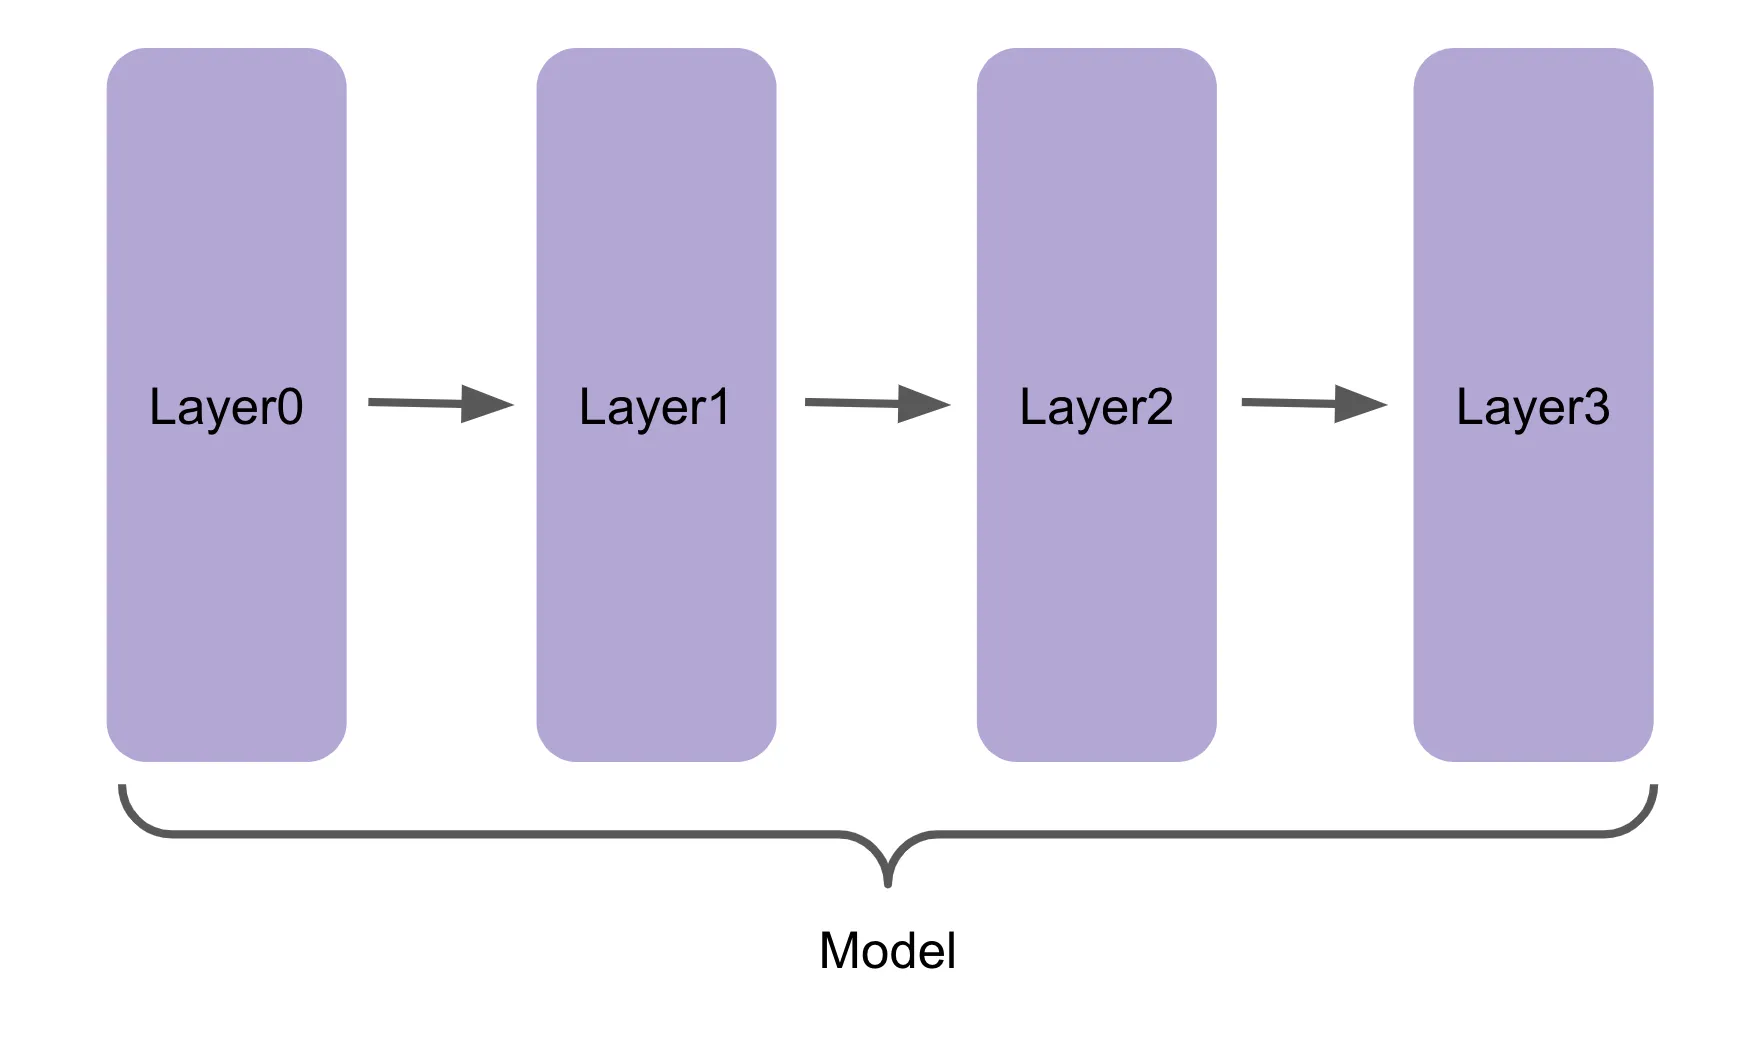

앞선 코드에서는 `nn.Module`을 상속받아 모델을 정의해 봤습니다. 레이어가 순차적으로 연결된 간단한 구조의 모델이었는데요. 즉, 모델에 입력된 텐서가 첫 번째 레이어에 들어가고, 이어지는 레이어들은 직전 레이어의 출력을 입력으로 받습니다(경우에 따라 중간에 활성화 함수가 적용될 수 있습니다). 그렇게 연산이 이어지다 마지막 레이어의 출력이 모델의 출력이 됩니다.

아래 코드에서는 모델에 입력된 텐서가 `self.linear0`을 통과하고 그 결과에 `self.relu` 활성화 함수를 적용했습니다. 이어서 그 결과가 `self.linear1`을 통과한 다음, 또 `self.relu` 활성화 함수를 통과했고요. 여기서 나온 텐서는 마지막으로 `self.linear2`를 통과하여 모델의 출력이 되죠.

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 'nn.Sequential'을 사용하여 신경망 모델을 더 간편하게 만드는 방법을 배우는 것입니다.
# 이전 코드에서는 'nn.Module'을 상속받아 __init__에서 부품을 정의하고 forward에서 데이터 흐름을 일일이 코딩했습니다.
# 하지만 많은 모델은 입력부터 출력까지 데이터가 한 방향으로 순차적으로만 흐르는 간단한 구조를 가집니다.
# 'nn.Sequential'은 바로 이런 '순차적인(Sequential)' 모델을 단 몇 줄로 정의할 수 있게 해주는 편리한 컨테이너(Container)입니다.
# 이를 통해 코드의 가독성을 높이고 실수를 줄일 수 있습니다.
# ====================================================================================================

import torch
import torch.nn as nn

# --- 비교를 위한 nn.Module 기반 모델 (이전 코드 복습) ---

# [구동 과정 설명]
# 이 클래스는 nn.Module을 상속받아 직접 모델을 정의하는 '정석적인' 방법입니다.
# __init__에서 각 레이어를 속성으로 정의하고, forward에서 이들을 순서대로 연결합니다.
# 이 방식은 데이터의 흐름이 복잡할 때 (예: 특정 레이어의 출력을 건너뛰어 다른 레이어의 입력으로 사용) 필수적입니다.
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(8, 4)
        self.l2 = nn.Linear(4, 6)
        self.l3 = nn.Linear(6, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        y = self.l3(x)
        return y

#### `nn.Sequential`로 모델 만들기

그런데 방금처럼 레이어들이 순차적으로 연결된 모델은 `nn.Sequential`을 이용해 더 간편하게 만들 수도 있습니다. 사용법은 간단해요. 순차적으로 연결할 레이어(또는 활성화 함수) 객체들을 하나하나 콤마로 구분해 `nn.Sequential()`의 입력으로 넣어 주면 됩니다.

`nn.Sequential` 객체에 텐서를 입력하면 각 레이어의 출력이 다음 레이어의 입력으로 자동으로 전달됩니다. 따로 `__init__()` 메소드와 `forward()` 메소드를 구현할 필요가 없어 코드가 간결해지죠.

실제로 아래 코드로 모델 객체를 만들면 위의 `MyModel` 클래스로 만든 모델 객체와 구조가 동일합니다.

In [ ]:
# --- nn.Sequential로 동일한 모델 만들기 ---

# [nn.Sequential 설명]
# nn.Sequential은 여러 nn.Module(레이어, 활성화 함수 등)을 담을 수 있는 순서가 있는 컨테이너입니다.
# 여기에 담긴 모듈들은 __init__에 정의된 순서대로, 입력 데이터에 순차적으로 적용됩니다.
# 사용자는 forward 메소드를 직접 구현할 필요가 없습니다. nn.Sequential이 알아서 데이터 흐름을 처리해주기 때문입니다.

# [모델 인스턴스 생성]
# mymodel: nn.Module을 상속받아 직접 만든 클래스의 인스턴스.
mymodel = MyModel()

# model: nn.Sequential을 사용하여 만든 모델 인스턴스.
# nn.Sequential()의 인자로, 모델을 구성할 레이어와 활성화 함수들을 순서대로 나열합니다.
# 파이토치는 이 순서를 기억하고, 데이터가 들어오면 0번(Linear) -> 1번(ReLU) -> 2번(Linear) ... 순으로 자동 실행합니다.
# MyModel 클래스의 forward 메소드에 정의된 흐름과 완전히 동일한 구조입니다.
model = nn.Sequential(
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 6),
    nn.ReLU(),
    nn.Linear(6, 3)
)

In [ ]:
# --- 두 모델의 출력 비교 ---
print("--- nn.Sequential vs nn.Module 비교 ---")
y = model(input_tensor)
print("nn.Sequential 모델의 출력:")
print(y)
# [결과 분석: tensor([...], [...], grad_fn=<AddmmBackward0>)]
# - (2, 3) 모양의 텐서가 출력됩니다. 입력 (2, 8)이 Sequential 모델을 순차적으로 통과하여 최종적으로 (2, 3) 모양이 되었습니다.

y2 = mymodel(input_tensor)
print("\nnn.Module 상속 모델의 출력:")
print(y2)
# [결과 분석: tensor([...], [...], grad_fn=<AddmmBackward0>)]
# - 마찬가지로 (2, 3) 모양의 텐서가 출력됩니다. 구조는 동일하기 때문입니다.
# [가장 중요한 점]
# y와 y2의 '값'은 다릅니다. 왜냐하면 model과 mymodel은 구조만 같을 뿐, 서로 다른 객체이기 때문입니다.
# 신경망 레이어는 생성될 때 내부의 가중치(weight)와 편향(bias)이 '무작위(random)'로 초기화됩니다.
# 따라서 두 모델은 서로 다른 무작위 가중치를 가지므로, 같은 입력을 넣어도 다른 계산 결과가 나옵니다.
# 하지만 두 모델의 '구조'와 '기능'은 완벽하게 동일합니다.

--- nn.Sequential vs nn.Module 비교 ---
nn.Sequential 모델의 출력:
tensor([[-0.0422, -0.2446,  0.0763],
        [ 0.0316, -0.2734,  0.2323]], grad_fn=<AddmmBackward0>)

nn.Module 상속 모델의 출력:
tensor([[ 0.3968,  0.1234, -0.1434],
        [ 0.4052,  0.1288, -0.1395]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- nn.Module 안에서 nn.Sequential 사용하기 ---
# [구동 과정 설명]
# nn.Sequential은 모델 전체를 정의할 때도 쓰이지만, 더 복잡한 모델의 '일부 블록'을 묶는 데에도 매우 유용합니다.
# 예를 들어, 모델의 특정 부분이 순차적인 구조를 가질 때, 그 부분만 nn.Sequential로 묶어 코드를 깔끔하게 만들 수 있습니다.
print("\n--- nn.Module 내부에 nn.Sequential 블록 사용 ---")
class MyModelSeq(nn.Module):
    def __init__(self):
        super().__init__()
        # self.block: 모델의 순차적인 부분을 nn.Sequential로 묶어서 하나의 '블록'으로 정의합니다.
        # 이렇게 하면 __init__이 더 깔끔해지고, 모델의 구조를 파악하기 쉬워집니다.
        self.block = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 6),
            nn.ReLU(),
            nn.Linear(6, 3),
            nn.ReLU() # 이전 MyModel과 달리 마지막에 ReLU를 추가한 버전입니다.
        )
        # self.layer: 위 블록의 출력(3개 특성)을 입력으로 받는 추가적인 레이어입니다.
        self.layer = nn.Linear(3, 4)

    def forward(self, x):
        # 입력 x를 self.block 전체에 한 번에 통과시킵니다.
        # Sequential 블록이 알아서 내부의 레이어들을 순서대로 실행해줍니다.
        x = self.block(x)
        # 블록의 최종 출력을 다음 레이어(self.layer)에 전달합니다.
        y = self.layer(x)
        return y


--- nn.Module 내부에 nn.Sequential 블록 사용 ---


In [ ]:
# --- 복잡한 forward 흐름에서 nn.Sequential 재사용하기 ---
print("\n--- 복잡한 forward 흐름 예시 ---")
class MyModelSeq2(nn.Module):
    def __init__(self):
        super().__init__()
        # self.block: 입력과 출력의 특성 개수가 8개로 동일한 순차 블록을 정의합니다. (8 -> 4 -> 6 -> 8)
        # 이렇게 입/출력 크기를 맞추면, 이 블록을 여러 번 반복해서 적용할 수 있습니다.
        # 마치 레고 블록처럼 재사용 가능한 부품을 만드는 것과 같습니다.
        self.block = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 6),
            nn.ReLU(),
            nn.Linear(6, 8), # 출력을 다시 8로 맞춤
            nn.ReLU()
        )
        # self.l1, self.layer: 블록 처리 후 최종 출력을 만들기 위한 추가 레이어들.
        self.l1 = nn.Linear(8, 3)
        self.layer = nn.Linear(3, 4)

    def forward(self, x):
        # [데이터 흐름 설명]
        # 이 forward 메소드는 단순한 순차 구조가 아닙니다.
        # self.block을 4번 반복해서 통과시키는 복잡한 흐름을 가집니다.
        # 이런 경우에는 nn.Sequential만으로 모델 전체를 정의할 수 없으며,
        # 반드시 nn.Module을 상속받아 forward 메소드를 직접 구현해야 합니다.
        x = self.block(x) # 1번 통과
        x = self.block(x) # 2번 통과
        x = self.block(x) # 3번 통과
        x = self.block(x) # 4번 통과
        # 4번의 블록 처리가 끝난 x를 추가 레이어에 통과시켜 최종 결과를 만듭니다.
        x = self.l1(x)
        y = self.layer(x)
        return y


--- 복잡한 forward 흐름 예시 ---


In [ ]:
model_seq2 = MyModelSeq2()
y = model_seq2(input_tensor)
print("복잡한 모델의 최종 출력:")
print(y)
# [결과 분석: tensor([...], [...], grad_fn=<AddmmBackward0>)]
# - 입력 (2, 8)이 복잡한 forward 경로를 거쳐 최종적으로 (2, 4) 모양의 텐서로 변환되었습니다.

복잡한 모델의 최종 출력:
tensor([[ 0.0184, -0.5912, -0.0880, -0.6589],
        [ 0.0184, -0.5912, -0.0880, -0.6589]], grad_fn=<AddmmBackward0>)


In [ ]:
# --- 모델 구조 출력 ---
print("\n모델의 전체 구조 출력:")
print(model_seq2)
# [결과 분석: MyModelSeq2(...)]
# - print(모델객체)를 하면 모델의 전체 구조를 시각적으로 보여줍니다.
# - (block): Sequential(...)
#   - (0): Linear(...)
#   - ...
#   - (5): ReLU()
# - (l1): Linear(...)
# - (layer): Linear(...)
# - __init__에서 정의한 부품들(self.block, self.l1, self.layer)이 어떤 것들인지,
#   그리고 Sequential 블록 내부에 어떤 레이어들이 어떤 순서로 들어있는지 한눈에 파악할 수 있습니다.
#   모델이 의도한 대로 잘 만들어졌는지 확인할 때 매우 유용합니다.


모델의 전체 구조 출력:
MyModelSeq2(
  (block): Sequential(
    (0): Linear(in_features=8, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=8, bias=True)
    (5): ReLU()
  )
  (l1): Linear(in_features=8, out_features=3, bias=True)
  (layer): Linear(in_features=3, out_features=4, bias=True)
)


# 복잡한 모델 설계

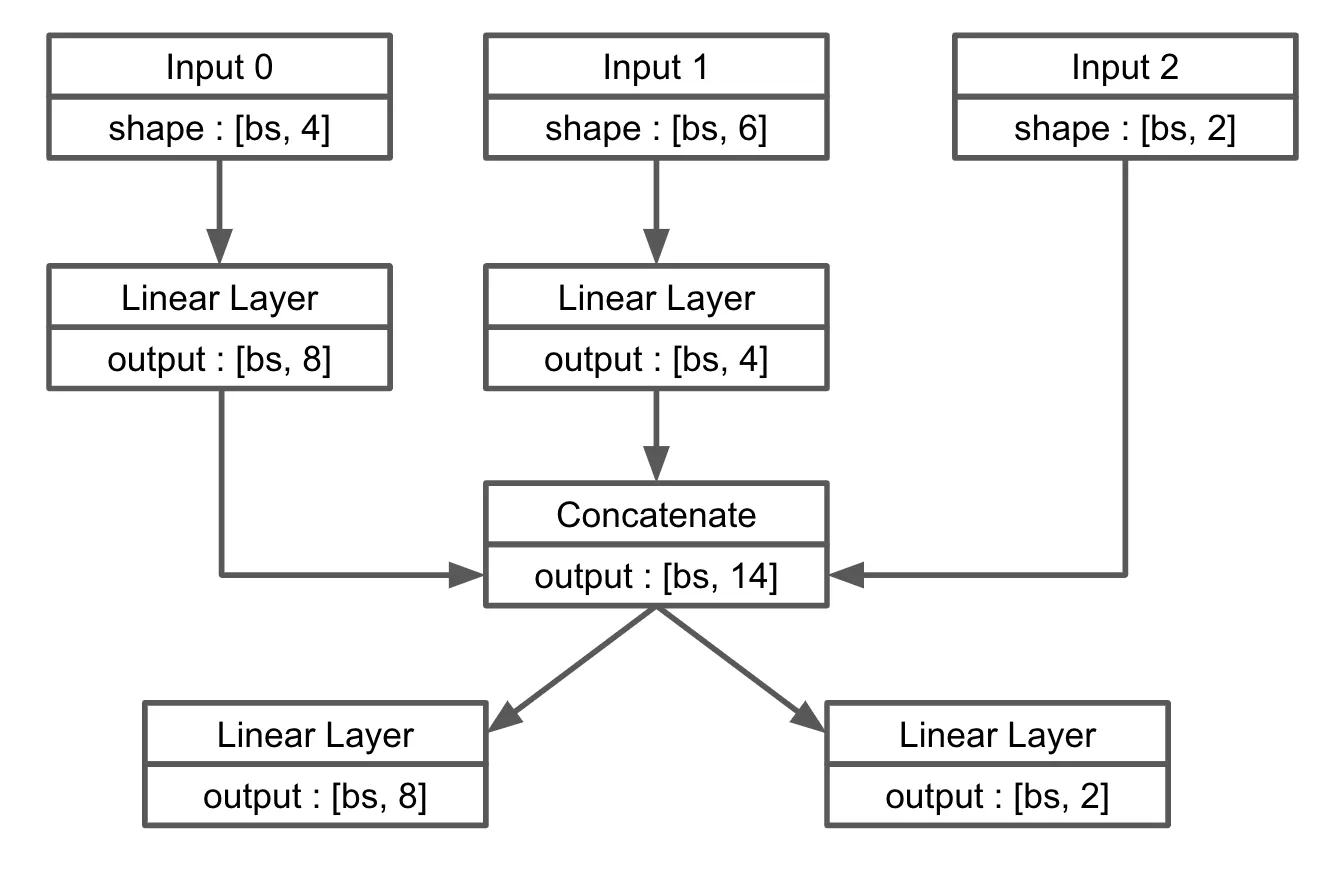

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 'nn.Sequential'로는 만들 수 없는, '복잡한 구조의' 신경망 모델을 설계하는 방법을 이해하는 것입니다.
# 실제 딥러닝 모델들은 데이터가 단순히 한 줄로 흐르지 않는 경우가 많습니다.
# 예를 들어, 여러 종류의 입력을 받아서 처리하거나(Multi-input), 여러 종류의 예측을 동시에 출력해야(Multi-output) 할 수 있습니다.
# 이 코드에서는 3개의 서로 다른 텐서를 입력받아 병렬로 처리하고, 그 결과들을 하나로 합친 뒤,
# 다시 2개의 서로 다른 텐서를 출력하는 모델을 'nn.Module'을 상속받아 직접 구현합니다.
# 이를 통해 'forward' 메소드를 자유롭게 설계하여 어떤 복잡한 데이터 흐름도 만들 수 있다는 것을 배웁니다.
# ====================================================================================================

import torch
import torch.nn as nn

# --- 다중 입력/출력을 갖는 복잡한 모델 클래스 정의 ---
class ComplexModel(nn.Module):
    # [1. 모델의 부품 정의: __init__ 메소드]
    # __init__ 메소드에서는 모델을 구성하는 데 필요한 모든 부품(레이어 등)을 미리 정의합니다.
    # 이 모델은 순차적이지 않으므로, 각 부품이 어떻게 연결될지는 forward 메소드에서 결정합니다.
    def __init__(self):
        super().__init__() # 부모 클래스 nn.Module의 생성자를 호출하여 기본 기능을 상속받습니다. 반드시 필요합니다.

        # [레이어 정의]
        # 모델의 각 부분에서 사용할 선형 레이어들을 정의합니다.
        # 이름(l0_0, l0_1)을 통해 각 레이어가 모델의 어느 부분에서 사용될지 유추할 수 있도록 짓는 것이 좋습니다.
        self.l0_0 = nn.Linear(4, 8)     # 4개 특성을 입력받아 8개로 변환할 레이어.
        self.l0_1 = nn.Linear(6, 4)     # 6개 특성을 입력받아 4개로 변환할 레이어.
        self.l1_0 = nn.Linear(14, 8)    # 14개 특성을 입력받아 8개로 변환할 레이어.
        self.l1_1 = nn.Linear(14, 2)    # 14개 특성을 입력받아 2개로 변환할 레이어.
        self.relu = nn.ReLU()           # 비선형성을 추가하기 위한 ReLU 활성화 함수.

    # [2. 데이터의 흐름 정의: forward 메소드]
    # forward 메소드는 데이터가 모델 내부에서 어떻게 흘러갈지를 정의합니다.
    # 이 모델은 3개의 입력을 받으므로, 매개변수도 3개(input0, input1, input2)를 받도록 정의합니다.
    def forward(self, input0, input1, input2):

        # --- 첫 번째 병렬 레이어 처리 ---
        # 두 개의 서로 다른 입력(input0, input1)이 각각 다른 레이어를 '동시에(병렬로)' 통과합니다.
        h0_0 = self.relu(self.l0_0(input0)) # input0(특성 4개)가 l0_0을 통과하여 8개 특성의 h0_0으로 변환됩니다.
        h0_1 = self.relu(self.l0_1(input1)) # input1(특성 6개)이 l0_1을 통과하여 4개 특성의 h0_1로 변환됩니다.

        # --- 중간 결과들을 하나로 합치기 (Concatenate) ---
        # 이전 단계에서 나온 결과들과 아직 사용하지 않은 세 번째 입력(input2)을 하나로 합칩니다.
        # torch.cat은 여러 텐서를 지정된 차원(dim)을 따라 이어 붙이는 함수입니다.
        # [h0_0, h0_1, input2]: 이어 붙일 텐서들을 리스트로 전달합니다. (모양: [bs, 8], [bs, 4], [bs, 2])
        # dim=1: '어떤 차원을 기준으로 붙일지'를 지정합니다.
        #        - dim=0 이었다면 배치(행) 방향으로 붙여서 (bs+bs+bs, ...) 모양이 됩니다.
        #        - dim=1 이므로 특성(열) 방향으로 붙여서 (bs, 8+4+2) 즉, (bs, 14) 모양의 텐서가 됩니다.
        #          일반적으로 특성을 합칠 때는 dim=1을 사용합니다.
        h1 = torch.cat([h0_0, h0_1, input2], dim = 1) # 3개의 텐서를 특성(열) 방향으로 이어 붙여 14개 특성의 h1을 만듭니다.

        # --- 최종 출력 생성 ---
        # 하나로 합쳐진 텐서(h1)를 입력으로 사용하여, 두 개의 서로 다른 출력을 만듭니다.
        # 동일한 h1 텐서가 각각 다른 출력 레이어로 들어가서 서로 다른 목적의 결과를 계산합니다.
        output0 = self.l1_0(h1) # 합쳐진 h1(특성 14개)을 l1_0에 통과시켜 8개 특성의 첫 번째 출력을 만듭니다.
        output1 = self.l1_1(h1) # 동일한 h1을 l1_1에 통과시켜 2개 특성의 두 번째 출력을 만듭니다.

        # [다중 출력 반환]
        # 모델의 최종 결과물인 두 개의 텐서를 튜플 형태로 반환합니다.
        return output0, output1

In [ ]:
# --- 모델 사용 예시 ---

# [모델 인스턴스화]
model = ComplexModel() # 위에서 설계한 ComplexModel 클래스의 실제 객체를 생성합니다.

# [가상의 입력 텐서 생성]
bs = 4 # 배치 크기(Batch Size)를 4로 설정합니다. 즉, 4개의 샘플을 한 번에 처리합니다.
x0 = torch.randn(bs, 4) # 첫 번째 입력. forward의 input0에 해당하며, l0_0의 입력 특성 개수(4)와 일치해야 합니다.
x1 = torch.randn(bs, 6) # 두 번째 입력. forward의 input1에 해당하며, l0_1의 입력 특성 개수(6)와 일치해야 합니다.
x2 = torch.randn(bs, 2) # 세 번째 입력. forward의 input2에 해당하며, 나중에 cat 될 텐서입니다.

In [ ]:
# [모델 실행 및 출력 받기]
# 모델을 함수처럼 호출하며, forward 메소드에 정의된 순서대로 3개의 입력 텐서를 전달합니다.
# 모델이 2개의 출력을 반환하므로, 2개의 변수(y0, y1)로 각각 받습니다.
y0, y1 = model(x0, x1, x2)

# [출력 텐서의 모양 확인]
print("첫 번째 출력 텐서의 크기:")
print(y0.size()) # 첫 번째 출력(output0)의 모양을 출력합니다.
# [결과 분석: torch.Size([4, 8])]
# - 배치 크기 4는 그대로 유지되었습니다.
# - 특성의 개수는 l1_0 레이어의 출력 차원(out_features=8)과 일치하는 8이 되었습니다.

print("\n두 번째 출력 텐서의 크기:")
print(y1.size()) # 두 번째 출력(output1)의 모양을 출력합니다.
# [결과 분석: torch.Size([4, 2])]
# - 배치 크기 4는 그대로 유지되었습니다.
# - 특성의 개수는 l1_1 레이어의 출력 차원(out_features=2)과 일치하는 2가 되었습니다.

첫 번째 출력 텐서의 크기:
torch.Size([4, 8])

두 번째 출력 텐서의 크기:
torch.Size([4, 2])


1. **병렬 레이어**
    - `input0`은 `Linear(4, 8)`로 처리 → 출력 크기: `[batch, 8]`
    - `input1`은 `Linear(6, 4)`로 처리 → 출력 크기: `[batch, 4]`
2. **컨캐터네이트**
    - `[batch, 8]` + `[batch, 4]` + `[batch, 2]` → `[batch, 14]`
3. **출력 레이어**
    - `[batch, 14]` → `Linear(14, 8)` → `output0` 크기: `[batch, 8]`
    - `[batch, 14]` → `Linear(14, 2)` → `output1` 크기: `[batch, 2]`

# 실습

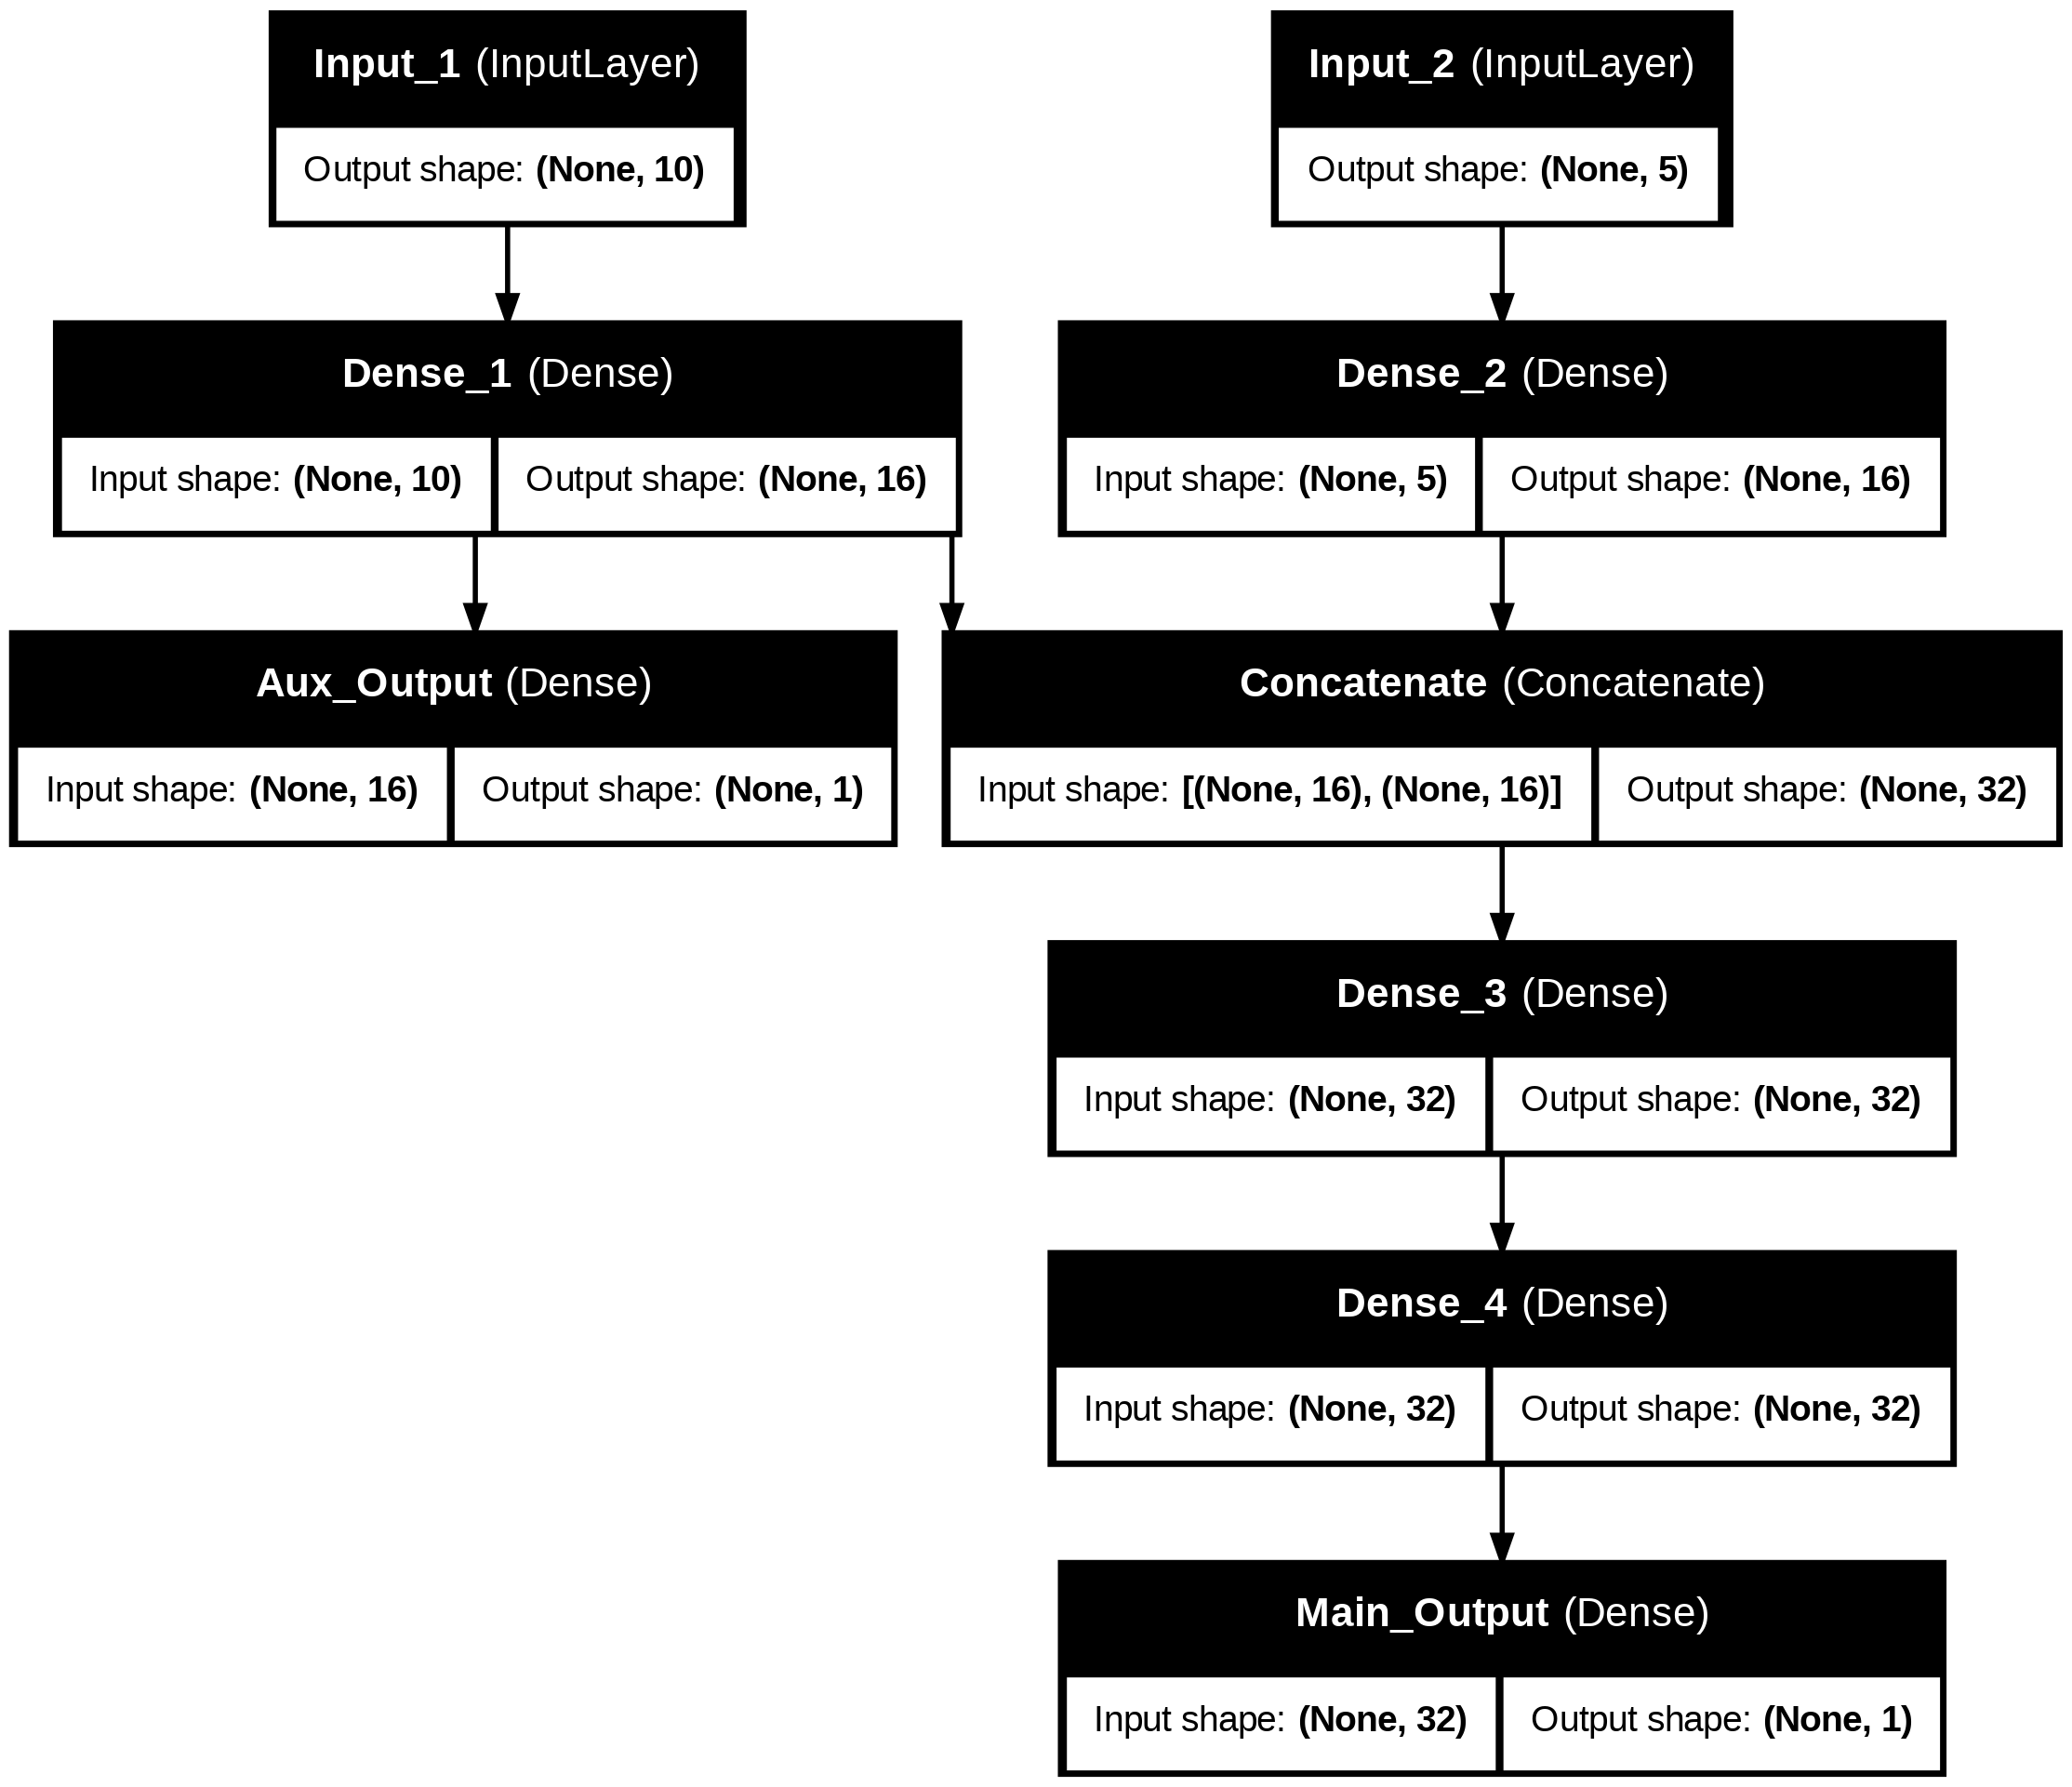

In [ ]:
# Input_1 (10차원) ───> Dense_1 (16차원) ──────┐
#                                                       │
#                                                       ├─> Concatenate ──> Dense_3 (32차원) ──> Dense_4 (32차원) ──> Main_Output (1차원)
# Input_2 (5차원)  ───> Dense_2 (16차원) ──────┘
#                                                   └────────────> Aux_Output (1차원)

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드는 주어진 다이어그램을 보고, 복잡한 구조의 신경망을 직접 코드로 구현하는 '실습'입니다.
# 이 모델은 이전 예제들보다 더 현실적인 구조를 가지고 있습니다.
#   1. 다중 입력 (Multi-input): 서로 다른 두 종류의 데이터를 입력으로 받습니다.
#   2. 병렬 처리 (Parallel Processing): 두 입력은 각각 별도의 레이어에서 독립적으로 처리됩니다.
#   3. 분기 및 다중 출력 (Branching & Multi-output): 처리된 데이터의 흐름이 중간에 나뉩니다.
#      - 한 갈래(주요 경로)는 다른 데이터와 합쳐져(Concatenate) 여러 레이어를 더 통과한 후 'Main_Output'을 만듭니다.
#      - 다른 갈래(보조 경로)는 중간 결과에서 바로 'Aux_Output'(보조 출력)을 만듭니다.
# 이러한 구조는 모델이 중간 과정에서도 유용한 예측을 하도록 훈련시키는 '보조 손실(Auxiliary Loss)' 기법 등에서 실제로 사용됩니다.
# 이 실습을 통해 'nn.Module'을 사용하여 어떤 복잡한 구조의 모델이든 자유롭게 설계할 수 있음을 완전히 이해하게 됩니다.
# ====================================================================================================

import torch
import torch.nn as nn

# --- 다이어그램 기반의 복잡한 모델 클래스 정의 ---

class ComplexModel2(nn.Module):
    # [1. 모델의 부품 정의: __init__ 메소드]
    # 주어진 다이어그램에 명시된 모든 레이어(Dense, Output)들을 미리 정의합니다.
    def __init__(self):
        super().__init__() # nn.Module의 기본 기능을 상속받기 위해 생성자를 호출합니다.

        # [입력 분기 레이어]
        self.dense1 = nn.Linear(10, 16) # Input_1(10차원)을 받아 16차원으로 변환하는 첫 번째 Dense 레이어.
        self.dense2 = nn.Linear(5, 16)  # Input_2(5차원)를 받아 16차원으로 변환하는 두 번째 Dense 레이어.

        # [주요 경로(Main Path) 레이어]
        # 이 레이어들은 두 입력이 합쳐진 후에 사용됩니다.
        self.dense3 = nn.Linear(32, 32) # 합쳐진 텐서(16+16=32차원)를 입력받아 32차원으로 변환합니다.
        self.dense4 = nn.Linear(32, 32) # 이전 레이어의 출력(32차원)을 받아 다시 32차원으로 변환합니다.

        self.relu = nn.ReLU() # 모델 중간중간에 비선형성을 더해줄 활성화 함수.

        # [출력 레이어]
        self.aux_output = nn.Linear(16, 1) # 보조 출력(Aux_Output). dense1의 출력(16차원)을 받아 1차원으로 변환합니다.
        self.main_output = nn.Linear(32, 1) # 주요 출력(Main_Output). 주요 경로의 최종 결과(32차원)를 받아 1차원으로 변환합니다.

    # [2. 데이터의 흐름 정의: forward 메소드]
    # 다이어그램에 그려진 화살표들을 따라 데이터의 흐름을 그대로 코드로 구현합니다.
    # 이 모델은 2개의 입력을 받으므로, 매개변수도 2개(input_1, input_2)를 받습니다.
    def forward(self, input_1, input_2):
        # [Input_1 경로 처리 및 보조 출력(Aux_Output) 생성]
        x1 = self.relu(self.dense1(input_1)) # input_1(10차원)을 dense1에 통과시켜 16차원의 텐서 x1을 만듭니다.

        # === 분기점 (Branching Point) ===
        # x1 텐서는 두 갈래 길로 나뉩니다.
        # 1) 하나는 바로 보조 출력 레이어로 향합니다.
        # 2) 다른 하나는 나중에 x2와 합쳐지기 위해 대기합니다.
        out1 = self.aux_output(x1) # x1을 보조 출력 레이어에 통과시켜 첫 번째 결과(out1)를 즉시 계산합니다.

        # [Input_2 경로 처리 및 Concatenate]
        x2 = self.relu(self.dense2(input_2)) # input_2(5차원)를 dense2에 통과시켜 16차원의 텐서 x2를 만듭니다.
        # 변수 x2를 재사용합니다. 이전 x2(dense2의 출력)와 x1을 합친 결과를 다시 x2에 저장합니다.
        # (더 명확하게 하려면 'concatenated_x = torch.cat(...)'처럼 새 변수를 쓰는 것도 좋은 방법입니다.)
        x2 = torch.cat([x1, x2], dim = 1) # x1(16차원)과 x2(16차원)를 특성(dim=1) 기준으로 합쳐 32차원의 텐서를 만듭니다.

        # [주요 경로(Main Path) 처리 및 주요 출력(Main_Output) 생성]
        x2 = self.relu(self.dense3(x2)) # 합쳐진 32차원 텐서를 dense3에 통과시킵니다.
        x2 = self.relu(self.dense4(x2)) # 그 결과를 다시 dense4에 통과시킵니다.
        out2 = self.main_output(x2) # 최종적으로 main_output 레이어를 통과시켜 두 번째 결과(out2)를 계산합니다.

        return out1, out2 # 계산된 보조 출력과 주요 출력을 튜플 형태로 반환합니다.

In [ ]:
# --- 모델 사용 예시 ---
model = ComplexModel2() # 위에서 설계한 모델의 실제 객체(인스턴스)를 생성합니다.
bs = 6 # 배치 크기를 6으로 설정합니다.
input1 = torch.randn(bs, 10) # 첫 번째 입력 데이터. dense1이 기대하는 10차원 특성을 가집니다.
input2 = torch.randn(bs, 5)  # 두 번째 입력 데이터. dense2가 기대하는 5차원 특성을 가집니다.

output1, output2 = model(input1, input2) # 모델에 두 입력을 전달하고, 반환되는 두 출력을 각각 변수에 저장합니다.

print("보조 출력(Aux_Output):")
print(output1)
# [결과 분석: tensor([...], grad_fn=<AddmmBackward0>)]
# - 모양(shape)은 (6, 1) 입니다. 배치 크기 6, aux_output 레이어의 출력 차원 1과 일치합니다.
# - 이것은 Input_1 데이터만으로 생성된 중간 예측값입니다.

print("\n주요 출력(Main_Output):")
print(output2)
# [결과 분석: tensor([...], grad_fn=<AddmmBackward0>)]
# - 모양(shape)은 (6, 1) 입니다. 배치 크기 6, main_output 레이어의 출력 차원 1과 일치합니다.
# - 이것은 Input_1과 Input_2 데이터를 모두 조합하여 만든 최종 예측값입니다.

보조 출력(Aux_Output):
tensor([[ 0.1541],
        [-0.2309],
        [-0.6149],
        [ 0.0450],
        [-0.2628],
        [-0.2553]], grad_fn=<AddmmBackward0>)

주요 출력(Main_Output):
tensor([[-0.2239],
        [-0.1233],
        [-0.1059],
        [-0.2029],
        [-0.1149],
        [-0.1758]], grad_fn=<AddmmBackward0>)


# 모델 정보 확인하기

PyTorch 모델에 담긴 다양한 정보를 확인하는 방법을 살펴봅니다. 모델 구조, 레이어 정보, 파라미터 등을 확인하여 모델 디버깅과 분석에 활용할 수 있습니다.

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 잘 만들어진 파이토치(PyTorch) 모델의 내부를 '들여다보는' 다양한 방법을 배우는 것입니다.
# 모델을 만들고 나면, 그 구조가 의도한 대로 잘 짜였는지, 어떤 레이어들이 포함되어 있는지,
# 그리고 학습될 파라미터(가중치, 편향)는 무엇인지 확인하는 과정은 매우 중요합니다.
# 이 코드를 통해 모델의 전체 구조 출력, 서브 모듈(레이어) 순회, 그리고 학습 파라미터 확인 등
# 모델을 분석하고 디버깅하는 데 필수적인 여러 가지 방법을 익힙니다.
# ====================================================================================================

import torch
import torch.nn as nn

# --- 분석할 샘플 모델 정의 ---
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # [__init__에서의 정의 순서]
        # __init__ 메소드 안에서 레이어를 정의하는 순서는 forward 메소드의 실행 순서와는 무관합니다.
        # print(model)을 했을 때 나오는 순서는 여기서 정의한 순서를 따릅니다.
        # 하지만 실제 데이터의 흐름은 forward 메소드에 의해 결정됩니다.
        self.l1 = nn.Linear(8, 4)
        self.l2 = nn.Linear(4, 6)
        self.l3 = nn.Linear(6, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 이 forward 메소드가 실제 데이터의 연산 순서를 결정합니다.
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        y = self.l3(x)
        return y

# --- 모델 인스턴스화 ---
model = MyModel() # 위에서 설계한 MyModel 클래스의 실제 객체(인스턴스)를 생성합니다.

In [ ]:
# ====================================================================================================
# 1. 모델의 전체 구조 출력하기 (print)
# ====================================================================================================
print("--- 1. 모델 전체 구조 출력 ---")
print(model)
# [구동 과정 및 결과 분석]
# - print(모델 객체)는 모델의 __repr__ 메소드를 호출하여 사람이 읽기 좋은 형태로 모델의 구조를 출력합니다.
# - 출력 결과는 MyModel 클래스가 어떤 서브 모듈(submodule)들을 가지고 있는지 보여줍니다.
# - (l1): Linear(...) 처럼, __init__에서 'self.이름'으로 정의한 '이름'과 해당 '모듈의 정보'가 함께 표시됩니다.
# - 이를 통해 모델의 전체적인 레이어 구성과 각 레이어의 입출력 차원 등을 한눈에 파악할 수 있어,
#   모델이 의도한 대로 잘 설계되었는지 확인하는 가장 기본적인 방법입니다.

--- 1. 모델 전체 구조 출력 ---
MyModel(
  (l1): Linear(in_features=8, out_features=4, bias=True)
  (l2): Linear(in_features=4, out_features=6, bias=True)
  (l3): Linear(in_features=6, out_features=3, bias=True)
  (relu): ReLU()
)


In [ ]:
# ====================================================================================================
# 2. 서브 모듈(레이어) 순회하기 (children)
# ====================================================================================================
print("\n--- 2. 서브 모듈(레이어) 순회 (이름 없이) ---")
# [구동 과정 및 결과 분석]
# - model.children()은 모델의 '직계 자식' 모듈들을 순회하는 '이터레이터(iterator)'를 반환합니다.
#   - 여기서 '직계 자식'이란 MyModel이 직접 가지고 있는 nn.Module들 (l1, l2, l3, relu)을 의미합니다.
#   - 만약 한 모듈이 다른 모듈을 포함하는 계층 구조라면, children()은 가장 바깥쪽 모듈만 보여줍니다.
# - list() 함수를 사용하여 이터레이터의 모든 내용을 리스트로 만들어 출력합니다.
# - 결과적으로, 모델을 구성하는 각 레이어(nn.Linear, nn.ReLU) 객체들이 리스트에 담겨 나옵니다.
# - 이 방법은 레이어의 '이름'은 필요 없고, 단순히 모든 레이어에 대해 동일한 작업을 반복하고 싶을 때 유용합니다.
print(list(model.children()))


--- 2. 서브 모듈(레이어) 순회 (이름 없이) ---
[Linear(in_features=8, out_features=4, bias=True), Linear(in_features=4, out_features=6, bias=True), Linear(in_features=6, out_features=3, bias=True), ReLU()]


In [ ]:
# ====================================================================================================
# 3. 이름과 함께 서브 모듈 순회하기 (named_children)
# ====================================================================================================
print("\n--- 3. 이름과 함께 서브 모듈 순회 ---")
# [구동 과정 및 결과 분석]
# - model.named_children()은 children()과 유사하지만, 각 모듈의 '이름'과 '모듈 객체'를 튜플 형태로 묶어서 반환합니다.
# - for 루프를 사용하여 각 튜플을 순회하며 출력합니다.
# - 출력 결과는 ('l1', Linear(...)), ('l2', Linear(...)) 와 같은 형식입니다.
# - 특정 이름을 가진 레이어에만 접근하거나, 이름에 따라 다른 처리를 하고 싶을 때 매우 유용합니다.
for named_child in model.named_children():
    print(named_child)


--- 3. 이름과 함께 서브 모듈 순회 ---
('l1', Linear(in_features=8, out_features=4, bias=True))
('l2', Linear(in_features=4, out_features=6, bias=True))
('l3', Linear(in_features=6, out_features=3, bias=True))
('relu', ReLU())


In [ ]:
## ====================================================================================================
# 4. 모델 파라미터 확인하기 (parameters)
# ====================================================================================================
print("\n--- 4. 모델 파라미터 확인 (이름 없이) ---")
# [구동 과정 및 결과 분석]
# - '파라미터(parameter)'란 학습 과정에서 값이 업데이트되는 텐서, 즉 '학습 가능한 가중치(weight)와 편향(bias)'을 의미합니다.
# - model.parameters()는 모델에 포함된 모든 파라미터 텐서들을 순회하는 이터레이터를 반환합니다.
# - for 루프를 통해 각 파라미터 텐서의 모양(shape)을 출력합니다.
#   - nn.Linear 레이어는 (출력차원, 입력차원) 모양의 가중치 텐서와 (출력차원,) 모양의 편향 텐서, 이렇게 2개의 파라미터를 가집니다.
#   - nn.ReLU와 같은 활성화 함수는 학습 가능한 파라미터가 없으므로 아무것도 반환하지 않습니다.
# - 이 메소드는 옵티마이저(optimizer)에 어떤 텐서들을 업데이트해야 하는지 알려주기 위해 내부적으로 사용되는 핵심 기능입니다.
for param in model.parameters():
    print(param.shape) # 각 파라미터 텐서의 모양(shape)을 출력합니다.


--- 4. 모델 파라미터 확인 (이름 없이) ---
torch.Size([4, 8])
torch.Size([4])
torch.Size([6, 4])
torch.Size([6])
torch.Size([3, 6])
torch.Size([3])


In [ ]:
# ====================================================================================================
# 5. 이름과 함께 모델 파라미터 확인하기 (named_parameters)
# ====================================================================================================
print("\n--- 5. 이름과 함께 모델 파라미터 확인 ---")
# [구동 과정 및 결과 분석]
# - model.named_parameters()는 각 파라미터의 '이름'과 '파라미터 텐서'를 튜플 형태로 묶어서 반환합니다.
# - 파라미터의 이름은 '모듈이름.파라미터종류' 형식의 계층적인 구조를 가집니다.
#   - 예: 'l1.weight', 'l1.bias'
# - 이 방법은 특정 파라미터의 값을 직접 확인하거나, 특정 레이어의 파라미터만 동결(freeze)시키거나,
#   레이어별로 다른 학습률(learning rate)을 적용하는 등의 고급 기법을 사용할 때 필수적입니다.
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}") # 각 파라미터의 이름과 모양을 함께 출력합니다.



--- 5. 이름과 함께 모델 파라미터 확인 ---
Name: l1.weight, Shape: torch.Size([4, 8])
Name: l1.bias, Shape: torch.Size([4])
Name: l2.weight, Shape: torch.Size([6, 4])
Name: l2.bias, Shape: torch.Size([6])
Name: l3.weight, Shape: torch.Size([3, 6])
Name: l3.bias, Shape: torch.Size([3])


# 모델이 포함된 모델

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 한 'nn.Module'이 다른 'nn.Module'을 서브 모듈로 포함하는, '중첩된(nested)' 또는
# '계층적인(hierarchical)' 모델의 내부를 어떻게 들여다보는지 이해하는 것입니다.
# 이전 코드에서 만든 MyModel을 하나의 '블록' 또는 '부품'으로 사용하여 더 큰 모델 MyModel2를 만들었습니다.
# 이 코드를 통해 .children(), .named_children(), .parameters(), .named_parameters()와 같은
# 모델 분석 도구들이 이런 중첩 구조를 어떻게 처리하는지, 특히 어떻게 재귀적으로(recursively) 동작하여
# 가장 깊은 곳에 있는 레이어나 파라미터까지 찾아내는지 배웁니다.
# 이를 통해 복잡한 최신 딥러닝 모델들의 구조를 분석하고 이해하는 능력을 기릅니다.
# ====================================================================================================

# --- 분석에 필요한 기본 모델(MyModel) 정의 (이건 위에 이전 코드와 동일) ---
# MyModel2가 MyModel을 사용하므로, 먼저 MyModel 클래스를 정의해야 코드가 실행됩니다.
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(8, 4)
        self.l2 = nn.Linear(4, 6)
        self.l3 = nn.Linear(6, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        y = self.l3(x)
        return y

# --- 다른 모델을 포함하는 중첩된 모델(MyModel2) 정의 ---
class MyModel2(nn.Module):
    def __init__(self):
        super().__init__()
        # [서브 모듈 정의]
        # self.block: MyModel 클래스의 인스턴스를 MyModel2의 서브 모듈로 포함시킵니다.
        #             이제 MyModel 전체가 MyModel2의 하나의 큰 부품처럼 작동합니다.
        self.block = MyModel()
        # self.linear: MyModel 블록의 출력(3차원)을 입력으로 받는 새로운 레이어를 추가합니다.
        self.linear = nn.Linear(3, 4)

    def forward(self, x):
        x = self.block(x) # 입력 x를 MyModel 블록 전체에 통과시킵니다.
        return self.linear(x) # 블록의 출력을 최종 linear 레이어에 통과시켜 결과를 반환합니다.

model2 = MyModel2() # MyModel2의 실제 객체(인스턴스)를 생성합니다.

In [ ]:
# ====================================================================================================
# 1. 중첩된 모델의 전체 구조 출력하기
# ====================================================================================================
print("--- 1. 중첩된 모델 전체 구조 출력 ---")
print(model2)
# [구동 과정 및 결과 분석: MyModel2(...)]
# - print(model2)를 실행하면 모델의 구조가 계층적으로 들여쓰기 되어 출력됩니다.
# - (block): MyModel(...)
#   - (l1): Linear(...)
#   ...
# - 최상위 모듈인 MyModel2가 'block'과 'linear'라는 두 개의 서브 모듈을 가지고 있음을 보여줍니다.
# - 그리고 'block' 모듈을 펼쳐서, 그 안에 'l1', 'l2', 'l3', 'relu'가 포함되어 있음을 자세히 보여줍니다.
# - 이 출력을 통해 복잡한 모델의 전체적인 아키텍처를 한눈에 파악할 수 있습니다.

--- 1. 중첩된 모델 전체 구조 출력 ---
MyModel2(
  (block): MyModel(
    (l1): Linear(in_features=8, out_features=4, bias=True)
    (l2): Linear(in_features=4, out_features=6, bias=True)
    (l3): Linear(in_features=6, out_features=3, bias=True)
    (relu): ReLU()
  )
  (linear): Linear(in_features=3, out_features=4, bias=True)
)


In [ ]:
# ====================================================================================================
# 2. 중첩된 모델의 직계 자식 모듈 확인하기 (named_children)
# ====================================================================================================
print("\n--- 2. 중첩 모델의 직계 자식 모듈 확인 ---")
for named_child in model2.named_children(): # model2의 '직계 자식' 모듈들을 순회합니다.
    print(named_child)
# [구동 과정 및 결과 분석]
# - .named_children()은 '재귀적'으로 동작하지 않습니다. 즉, 가장 바깥쪽 레벨의 자식들만 보여줍니다.
# - MyModel2의 직계 자식은 'block' (MyModel 인스턴스)과 'linear' (nn.Linear 인스턴스) 두 개뿐입니다.
# - 따라서 출력 결과는 ('block', MyModel(...))와 ('linear', Linear(...)) 두 줄만 나옵니다.
# - 'block' 내부에 있는 l1, l2, l3 등은 '손자' 모듈이므로 여기서는 보이지 않습니다.


--- 2. 중첩 모델의 직계 자식 모듈 확인 ---
('block', MyModel(
  (l1): Linear(in_features=8, out_features=4, bias=True)
  (l2): Linear(in_features=4, out_features=6, bias=True)
  (l3): Linear(in_features=6, out_features=3, bias=True)
  (relu): ReLU()
))
('linear', Linear(in_features=3, out_features=4, bias=True))


In [ ]:
# ====================================================================================================
# 3. 중첩된 모델의 모든 파라미터 확인하기 (named_parameters)
# ====================================================================================================
print("\n--- 3. 중첩 모델의 모든 파라미터 확인 ---")
for named_param in model2.named_parameters(): # model2에 포함된 '모든' 파라미터들을 순회합니다.
    print(named_param[0]) # 파라미터의 이름만 출력하여 구조를 명확히 봅니다. (값은 너무 길어서 생략)
# [구동 과정 및 결과 분석]
# - .named_parameters()는 .named_children()과 달리 '재귀적(recursively)'으로 동작합니다.
# - 즉, 최상위 모듈(MyModel2)부터 시작해서 가장 깊은 곳에 있는 서브 모듈까지 모두 탐색하여
#   학습 가능한 모든 파라미터(weight, bias)를 찾아내 반환합니다.
# - 파라미터의 이름은 '부모모듈이름.자식모듈이름.파라미터종류' 와 같이 점(.)으로 구분된 계층적인 경로로 표시됩니다.
#   - 예: 'block.l1.weight'는 'model2'의 'block' 모듈 안에 있는 'l1' 레이어의 'weight' 파라미터를 의미합니다.
# - 이 재귀적인 특성 덕분에, 아무리 복잡하게 중첩된 모델이라도 단 한 번의 호출로 모든 파라미터를
#   옵티마이저에 전달하여 학습시킬 수 있습니다. 이것이 nn.Module의 매우 강력한 기능입니다.


--- 3. 중첩 모델의 모든 파라미터 확인 ---
block.l1.weight
block.l1.bias
block.l2.weight
block.l2.bias
block.l3.weight
block.l3.bias
linear.weight
linear.bias


# 모델과 연산장치

앞서 텐서에 대해 배울 때 텐서의 연산 장치를 어떻게 지정할 수 있는지 배웠습니다. 따로 설정하지 않으면 텐서는 기본적으로 CPU에 만들어지는데요. to() 메소드로 텐서를 CPU에서 GPU로, 또는 GPU에서 CPU로 옮길 수 있었죠. 장치 설정은 'cpu'나 'cuda'처럼 문자열을 사용해도 됐고, torch.device 객체를 만들어 사용하는 것도 가능했습니다. 텐서끼리 연산을 하려면 모든 텐서가 동일한 연산 장치를 사용해야 한다는 것도 배웠어요.

PyTorch에서는 텐서뿐만 아니라 모델도 어떤 장치에서 사용할지 설정할 수 있습니다. 일단 텐서와 마찬가지로 모델도 기본적으로 CPU에 만들어져요.

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이번 코드의 목표는 파이토치(PyTorch) 모델과 텐서를 특정 연산 장치(CPU 또는 GPU)로 보내고,
# 이들 간의 상호작용 규칙을 이해하는 것입니다.
# 딥러닝 연산은 매우 많은 행렬 곱셈을 포함하기 때문에, 병렬 처리에 특화된 GPU를 사용하면 CPU보다 훨씬 빠르게
# 모델을 학습시킬 수 있습니다.
# 파이토치에서는 .to() 메소드를 사용하여 모델과 텐서를 원하는 장치로 쉽게 옮길 수 있습니다.
# 가장 중요한 규칙은 '연산에 참여하는 모든 모델과 텐서는 반드시 동일한 장치에 있어야 한다'는 것입니다.
# 이 코드를 통해 장치를 설정하고, 모델과 텐서를 이동시키며, 장치가 일치하지 않을 때 발생하는 문제를 확인합니다.
# ====================================================================================================

# --- 1. 연산 장치 설정하기 ---
# [구동 과정 설명]
# 이 코드는 현재 실행 환경에서 GPU(CUDA)를 사용할 수 있는지 확인하고,
# 가능하면 'cuda'를, 불가능하면 'cpu'를 device 변수에 저장하는 표준적인 방법입니다.
# torch.cuda.is_available(): 시스템에 CUDA를 지원하는 NVIDIA GPU가 설치되어 있고, 파이토치가 이를 인식할 수 있으면 True를 반환합니다.
# 'cuda' if ... else 'cpu': 파이썬의 삼항 연산자로, 조건이 참이면 'cuda'를, 거짓이면 'cpu'를 선택합니다.
# torch.device(...): 선택된 문자열('cuda' 또는 'cpu')로 device 객체를 생성합니다.
# 이렇게 하면 코드를 수정하지 않아도 GPU가 있는 환경과 없는 환경 모두에서 코드가 잘 동작하게 됩니다 (장치-독립적 코드).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. 모델을 특정 장치로 이동시키기 ---

# 아래 코드는 모델을 생성한 뒤 .to() 메소드를 사용하여 지정된 장치로 이동시키는 예시입니다.
# model = MyModel().to('cuda') # 이 코드를 실행하면 모델의 모든 파라미터가 CUDA(GPU) 장치로 이동합니다.
# 또는 위에서 만든 device 객체를 사용하여 model = MyModel().to(device) 와 같이 사용할 수 있습니다.
# .to(device) 메소드는 모델 내부의 모든 서브 모듈과 파라미터를 '재귀적으로' 탐색하여 지정된 장치로 보냅니다.
# [중요] .to()는 모델 자체를 바꾸는 것이 아니라, 장치로 '이동된 새로운 모델 객체'를 반환합니다.
# 따라서 model = model.to(device) 처럼 다시 할당해주는 것이 일반적입니다.
model = MyModel() # 이번 실습에서는 기본 장치인 CPU에 모델을 그대로 둡니다.

# --- 3. 모델 파라미터의 현재 장치 확인하기 ---
print("--- 모델 파라미터의 장치 확인 ---")
for name, param in model.named_parameters(): # 모델의 모든 파라미터를 순회합니다.
    # param.device: 각 파라미터 텐서가 현재 어느 장치에 있는지('cpu' 또는 'cuda:0' 등)를 알려주는 속성입니다.
    print(f'{name}: {param.device}') # 파라미터의 이름과 그 파라미터가 위치한 장치를 출력합니다.
# [결과 분석]
# l1.weight: cpu
# ...
# - 모델을 생성만 하고 .to('cuda')를 호출하지 않았기 때문에, 모든 파라미터는 기본값인 'cpu'에 위치해 있습니다.
# - 만약 model = MyModel().to('cuda')를 실행했다면, 모든 결과가 'cuda:0'으로 출력될 것입니다.

# --- 4. 모델과 입력 텐서의 장치 일치시키기 ---
print("\n--- 모델과 입력 텐서의 장치 불일치 문제 ---")
# [가장 중요한 규칙]
# model(input_tensor)와 같은 연산을 수행할 때,
# model의 파라미터들과 input_tensor는 '반드시' 같은 장치에 있어야 합니다.
# 만약 model은 GPU에 있는데 input_tensor는 CPU에 있다면, 둘은 서로 소통할 수 없어 'RuntimeError'가 발생합니다.
# "RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!"
# 라는 에러 메시지가 대표적입니다.

--- 모델 파라미터의 장치 확인 ---
l1.weight: cpu
l1.bias: cpu
l2.weight: cpu
l2.bias: cpu
l3.weight: cpu
l3.bias: cpu

--- 모델과 입력 텐서의 장치 불일치 문제 ---


In [ ]:
# model과 input_tensor의 device가 다르면 에러가 난다

# [올바른 실행 예시]
# 현재 model은 CPU에 있습니다. 이제 입력 텐서를 생성해봅니다.
input_tensor = torch.randn(2, 8) # 텐서도 기본적으로 CPU에 생성됩니다.
print(f'입력 텐서의 장치: {input_tensor.device}') # .device 속성으로 텐서의 위치를 확인합니다.

# [모델 실행]
# model(CPU)과 input_tensor(CPU)가 모두 같은 장치(CPU)에 있으므로, 연산이 정상적으로 수행됩니다.
y = model(input_tensor)
print("\n모델 실행 결과:")
print(y)
# [결과 분석]
# - 최종 출력 텐서 y도 연산이 수행된 장치인 CPU에 생성됩니다. (y.device를 확인해보면 'cpu'입니다.)
# - 만약 GPU에서 연산을 했다면, 다음과 같이 코드를 작성해야 합니다.
#   device = torch.device('cuda')
#   model = MyModel().to(device)
#   input_tensor = torch.randn(2, 8).to(device) # <-- 입력 텐서도 반드시 GPU로 보내야 함!
#   y = model(input_tensor)

입력 텐서의 장치: cpu

모델 실행 결과:
tensor([[ 0.0284, -0.1606,  0.1629],
        [ 0.0268, -0.1480,  0.1839]], grad_fn=<AddmmBackward0>)


# 모델 학습시키기

In [ ]:
# ====================================================================================================
# [전체적인 목표]
# 이 코드는 딥러닝 모델 학습의 전체 과정을 처음부터 끝까지 보여주는 완벽한 예제입니다.
# 1. 데이터 준비: 웹에서 데이터를 불러와 정제하고, 학습/검증/테스트 용도로 나눕니다.
# 2. 데이터 파이프라인 구축: PyTorch의 Dataset과 DataLoader를 사용하여 모델에 데이터를 효율적으로 공급할 준비를 합니다.
# 3. 모델 설계: 해결할 문제(전복 나이 예측)에 맞는 간단한 신경망 모델을 정의합니다.
# 4. 모델 학습: 정의된 모델을 사용하여 '학습 루프(Training Loop)'를 실행합니다. 이 과정에서 모델은 데이터를 보고, 예측하고,
#               정답과 비교하여 스스로의 파라미터(가중치)를 점차 개선해 나갑니다.
# 5. 모델 평가: 학습이 끝난 모델이 이전에 본 적 없는 '테스트 데이터'에 대해 얼마나 좋은 성능을 내는지 최종적으로 평가하고 시각화합니다.
# 이 전체 흐름을 이해하는 것이 딥러닝 프로젝트를 수행하는 핵심입니다.
# ====================================================================================================

# --- 1. 기본 라이브러리 및 설정 ---
import numpy as np # 수치 연산을 위한 라이브러리, 주로 데이터를 배열 형태로 다룰 때 사용합니다.
import pandas as pd # 데이터 분석 및 조작을 위한 라이브러리, 특히 표 형태의 데이터를 다루는 데 편리합니다. (CSV 파일 읽기 등)
from sklearn.preprocessing import StandardScaler # 데이터의 스케일을 조정(표준화)하기 위한 Scikit-learn의 도구입니다.

import torch # 파이토치 핵심 라이브러리입니다.
import torch.nn as nn # 신경망 모델을 구성하는 레이어, 활성화 함수 등이 포함된 모듈입니다.
from torch.utils.data import Dataset, DataLoader # 데이터를 모델에 효율적으로 공급하기 위한 유틸리티 클래스입니다.


In [ ]:
# [연산 장치 설정]
# 이전에 배운 대로, 사용 가능한 경우 GPU(cuda)를, 그렇지 않으면 CPU를 사용하도록 설정합니다.
# 이 device 변수는 나중에 모델과 데이터를 해당 장치로 보내는 데 사용됩니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# --- 2. 데이터 준비 (Loading and Preprocessing) ---

# [데이터 불러오기]
# pandas의 read_csv 함수를 사용하여 웹 URL로부터 전복(abalone) 데이터셋을 직접 불러옵니다.
# names=[...]: CSV 파일에 헤더(열 이름)가 없으므로, 각 열의 이름을 직접 지정해줍니다.
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)
# 이 데이터셋의 목표는 7개의 특성('Length' ~ 'Shell weight')을 사용하여 'Age'를 예측하는 회귀(Regression) 문제입니다.
# input: 7 (7개의 특성)
# target: 1 ('Age'라는 1개의 값)

# [입력(feature)과 타깃(label) 분리]
# .drop(columns=['Age']): 'Age' 열을 제외한 나머지 모든 열을 선택합니다. 이것이 모델의 입력(input)이 됩니다.
# .to_numpy(): pandas DataFrame을 NumPy 배열로 변환합니다.
# .astype(np.float32): 딥러닝 연산의 표준 자료형인 32비트 실수형(float32)으로 데이터 타입을 통일합니다.
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)
# abalone_df['Age']: 'Age' 열만 선택합니다. 이것이 모델이 맞춰야 할 정답(target)입니다.
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

In [ ]:
# [PyTorch 커스텀 데이터셋 클래스 정의]
# PyTorch의 Dataset 클래스를 상속받아 우리 데이터에 맞는 커스텀 데이터셋을 만듭니다.
# DataLoader가 데이터를 효율적으로 배치(batch) 단위로 묶어주려면 이 형식을 따라야 합니다.
class AbaloneDataset(Dataset):
    # __init__: 데이터셋이 처음 생성될 때 실행됩니다. 입력 데이터와 타깃 데이터를 멤버 변수로 저장합니다.
    def __init__(self, input_data, target_data):
        self.input_data = input_data
        self.target_data = target_data

    # __len__: 데이터셋의 총 샘플 개수를 반환합니다. DataLoader가 전체 데이터 크기를 파악하는 데 사용합니다.
    def __len__(self):
        return len(self.input_data)

    # __getitem__: 특정 인덱스(index)에 해당하는 데이터 샘플 하나를 반환합니다. DataLoader가 배치 데이터를 구성하기 위해 반복적으로 호출합니다.
    def __getitem__(self, index):
        # NumPy 배열을 PyTorch 텐서로 변환합니다. 딥러닝 모델은 텐서 형태의 입력을 받습니다.
        input_tensor = torch.tensor(self.input_data[index], dtype = torch.float32) # dtype을 명시하여 데이터 타입을 보장합니다.
        target_tensor = torch.tensor(self.target_data[index], dtype = torch.float32) # 이는 데이터 로딩 시 발생할 수 있는 타입 에러를 방지합니다.
        return input_tensor, target_tensor

In [ ]:
# [학습/검증/테스트 데이터 분할]
# 전체 데이터를 학습용(80%), 검증용(10%), 테스트용(10%)으로 나눕니다.
# - 학습용(train): 모델이 직접 보고 배우는 데이터.
# - 검증용(validation): 학습 중에 모델 성능을 중간 점검하여 과적합(overfitting) 여부를 확인하는 데이터.
# - 테스트용(test): 모든 학습이 끝난 후, 모델의 최종 성능을 평가하는, 모델이 한 번도 본 적 없는 데이터.
train_size = int(len(input_data) * 0.8)
val_size = int(len(input_data) * 0.1)

train_inputs, train_targets = input_data[:train_size], target_data[:train_size]
val_inputs, val_targets = input_data[train_size:train_size + val_size], target_data[train_size:train_size + val_size]
test_inputs, test_targets = input_data[train_size + val_size:], target_data[train_size + val_size:]

# [데이터 표준화 (Standardization)]
# 각 특성(feature)의 범위(scale)가 다르면 모델 학습이 불안정해질 수 있습니다.
# StandardScaler는 각 특성의 평균을 0, 표준편차를 1로 만들어주어 학습 안정성과 성능을 높입니다.
scaler = StandardScaler()
# [중요] scaler.fit()은 '학습 데이터'에 대해서만 수행해야 합니다.
# 검증/테스트 데이터는 학습 데이터의 통계치(평균, 표준편차)를 그대로 사용하여 변환만 해야 '데이터 누수(data leakage)'를 막을 수 있습니다.
scaler.fit(train_inputs)

train_inputs_scaled = scaler.transform(train_inputs)
val_inputs_scaled = scaler.transform(val_inputs)
test_inputs_scaled = scaler.transform(test_inputs)

# [데이터셋 및 데이터 로더 생성]
# 위에서 준비한 데이터로 Dataset 객체를 만들고, 이를 DataLoader로 감싸줍니다.
train_dataset = AbaloneDataset(train_inputs_scaled, train_targets)
val_dataset = AbaloneDataset(val_inputs_scaled, val_targets)
test_dataset = AbaloneDataset(test_inputs_scaled, test_targets)

# DataLoader는 Dataset으로부터 데이터를 받아와 지정된 배치 크기로 묶고, 섞어주는 등의 역할을 합니다.
# batch_size=32: 한 번의 스텝(step)에서 32개의 데이터를 묶어서 처리합니다.
# shuffle=True: 학습 시, 매 에폭마다 데이터의 순서를 섞어줍니다. 모델이 데이터 순서를 외우는 것을 방지하여 일반화 성능을 높입니다.
# drop_last=True: 전체 데이터 개수가 배치 크기로 나누어 떨어지지 않을 때, 마지막의 작은 배치를 버립니다. 모든 배치의 크기를 동일하게 유지해줍니다.
train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle = True, drop_last = True)
val_dataloader = DataLoader(val_dataset, batch_size = 32)
test_dataloader = DataLoader(test_dataset, batch_size = 32)

In [ ]:
# --- 3. 모델 정의 및 생성 ---
# 입력 특성 7개를 받아 최종적으로 1개의 값(나이)을 예측하는 간단한 다층 퍼셉트론(MLP) 모델입니다.
class AbaloneModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(7, 32) # fc는 Fully-Connected의 약자입니다.
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1) # 최종 출력은 1개의 숫자여야 합니다.
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x) # 회귀 문제의 마지막 레이어에는 보통 활성화 함수를 적용하지 않습니다.
        return x

# 모델을 생성하고, 위에서 설정한 device(CPU 또는 GPU)로 보냅니다.
model = AbaloneModel().to(device)
print(model) # 모델의 구조를 출력하여 확인합니다.

AbaloneModel(
  (fc1): Linear(in_features=7, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
# --- 4. 모델 생성 및 학습 장소 배정 ---
# [흐름] 훈련시킬 학생(모델)을 생성하고, 공부할 책상(CPU 또는 GPU)을 배정해줍니다.

# [구동 과정 심층 분석] `model = AbaloneModel().to(device)`
# 1. `AbaloneModel()`: 이전에 정의한 모델 설계도를 바탕으로, 아직 아무것도 학습하지 않은 '백지 상태'의 모델 객체를 생성합니다.
# 2. `.to(device)`: 생성된 모델 객체를 `.to()` 메서드를 통해 `device` 변수에 지정된 장치(CPU 또는 GPU)로 보냅니다.
#    모델의 모든 파라미터(가중치, 편향)와 계산 과정이 이제부터 해당 장치에서 이루어지게 됩니다.
#    (GPU를 사용할 수 있다면, 무거운 계산을 GPU가 대신하여 학습 속도가 비약적으로 빨라집니다.)
model = AbaloneModel().to(device)

# [구동 과정] `print(model)`: 생성된 모델 객체의 구조를 사람이 보기 좋은 형태로 출력합니다.
#            우리가 `__init__`에서 정의한 레이어들이 순서대로 잘 포함되어 있는지 확인할 수 있습니다.
print(model)


# --- 5. 학습 계획 수립 (손실 함수, 옵티마이저 설정) ---
# [흐름] 본격적인 과외를 시작하기 전에, 학습의 규칙과 방법을 정하는 단계입니다.

# [구동 과정] `torch.optim` 라이브러리를 `optim`이라는 별명으로 가져옵니다. 여기에는 SGD, Adam 등 다양한 '과외 선생님'들이 들어있습니다.
import torch.optim as optim

# [구동 과정] `epochs = 10`: '연습 문제집 전체를 총 10번 반복해서 풀겠다'는 학습 계획을 세우고, `epochs` 변수에 저장합니다.
epochs = 10
# [구동 과정] `step = 0`: 총 몇 번의 문제(배치)를 풀었는지 기록하기 위한 카운터를 0으로 초기화합니다.
step = 0

# [구동 과정] `loss_fn = nn.MSELoss()`:
# '빨간펜 채점 도구'로 `nn.MSELoss`를 선택합니다. 이 도구는 (예측값 - 정답)²의 평균을 계산하는 규칙을 가지고 있으며,
# 주택 가격 예측과 같은 회귀 문제에 표준적으로 사용됩니다. 생성된 채점 도구 객체를 `loss_fn` 변수에 저장합니다.
loss_fn = nn.MSELoss()

# [구동 과정] `opt = optim.SGD(...)`
# '개인 과외 선생님'으로 `optim.SGD` (확률적 경사 하강법)를 고용합니다. 이 선생님을 고용할 때 몇 가지 중요한 계약 조건을 설정합니다.
# - `model.parameters()`: "선생님, 당신이 가르쳐야 할 학생은 바로 이 `model`의 모든 파라미터(뇌)입니다." 라고 대상을 명확히 알려줍니다.
# - `lr=0.001`: 학습률(Learning Rate). "학생을 가르칠 때, 한 번에 0.001만큼의 작은 단계로 조금씩만 교정해주세요."
#               이 값이 너무 크면 학생이 혼란에 빠지고, 너무 작으면 학습이 매우 느려집니다.
# - `momentum=0.9`: "이전에 가르쳤던 방향을 90% 정도는 유지하면서, 새로운 방향으로 조금씩 수정해주세요."
#                  관성처럼 작용하여, 학습이 샛길로 빠지는 것을 막고 더 빠르고 안정적으로 올바른 방향으로 나아가도록 돕습니다.
opt = optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9)


# --- 6. [핵심] 학습 및 검증 루프 실행 ---
# [흐름] 세운 계획에 따라, '에포크' 단위로 문제집 풀이(학습)와 모의고사(검증)를 반복합니다.

# [구동 과정] `for epoch in range(epochs):`
# `epochs`(10) 만큼, 즉 총 10번 동안 문제집 전체를 반복해서 풀기 위한 외부 루프를 시작합니다. `epoch` 변수에는 0부터 9까지의 숫자가 차례로 들어갑니다.
for epoch in range(epochs):
    # --- [6-1. 학습 모드: 연습문제 풀이] ---
    # [구동 과정] `model.train()`: 모델 객체에게 "지금부터는 훈련 시간이야!"라고 알려주는 스위치입니다.
    #            이 모드가 켜지면, Dropout이나 BatchNorm과 같이 훈련 시에만 동작해야 하는 기능들이 활성화됩니다.
    model.train()
    # [구동 과정] `for train_batch in train_dataloader:`
    # `train_dataloader` (연습 문제집)에서 한 묶음의 문제('배치')를 꺼내 `train_batch`에 담는 내부 루프를 시작합니다.
    # 이 루프는 문제집의 모든 문제를 다 풀 때까지 계속됩니다.
    for train_batch in train_dataloader:
        # --- [딥러닝 학습의 5단계] ---
        # 이 5단계는 거의 모든 딥러닝 훈련 코드에서 반복되는 핵심 패턴입니다.

        # [1단계: 이전 계산 흔적 지우기 (칠판 지우기)]
        # [구동 과정] `opt.zero_grad()`: 과외 선생님(`opt`)에게 "이전 문제 풀 때 썼던 계산 과정(그래디언트)은 이제 필요 없으니, 칠판을 깨끗이 지워주세요" 라고 지시합니다.
        #           이 과정을 생략하면 이전 문제의 계산 흔적이 다음 문제 계산에 더해져, 엉뚱한 방향으로 학습이 진행됩니다.
        opt.zero_grad()

        # [구동 과정] `train_batch` (문제 묶음)에서 입력(문제지)과 타겟(정답지)을 분리하고, `.to(device)`를 통해
        #           모델이 있는 동일한 책상(CPU/GPU)으로 보냅니다.
        x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)

        # [2단계: 문제 풀기 (순전파)]
        # [구동 과정] `pred = model(x_train).squeeze()`:
        # 1. `model(x_train)`: 학생(`model`)에게 문제지(`x_train`)를 주고 풀게 합니다. 모델의 `forward` 메서드가 실행되어 예측값이 계산됩니다.
        # 2. `.squeeze()`: 모델의 출력 형태(예: [32, 1])와 정답지 형태(예: [32])가 미묘하게 다를 때, 불필요한 차원(사이즈가 1인 차원)을 제거하여
        #                   모양을 똑같이 맞춰주는 '정리' 작업입니다.
        # 3. 최종 예측 결과가 `pred` 변수에 저장됩니다.
        pred = model(x_train).squeeze()

        # [3단계: 채점하기 (손실 계산)]
        # [구동 과정] `loss = loss_fn(pred, y_train)`: 채점 도구(`loss_fn`)를 이용해 학생의 답안지(`pred`)와 실제 정답지(`y_train`)를
        #           비교하여 '오차 점수(loss)'를 계산합니다. 이 점수가 높을수록 많이 틀렸다는 의미입니다.
        loss = loss_fn(pred, y_train)

        # [4단계: 오답 원인 분석 (역전파)]
        # [구동 과정] `loss.backward()`: 계산된 오차 점수(`loss`)에 대해 `.backward()`를 호출합니다.
        #           이 명령은 PyTorch의 Autograd 엔진을 작동시켜, "이 오차가 발생한 데에 각 파라미터(뇌세포)들이 얼마나 책임이 있는지"
        #           그 '책임량(그래디언트)'을 자동으로 계산하여 각 파라미터에 기록해두는, 마법 같은 과정입니다.
        loss.backward()

        # [5단계: 지식 교정 (파라미터 업데이트)]
        # [구동 과정] `opt.step()`: 과외 선생님(`opt`)에게 "이제 오답 분석이 끝났으니, 분석 결과(그래디언트)를 바탕으로
        #           학생의 뇌(파라미터)를 올바른 방향으로 수정해주세요" 라고 지시합니다.
        #           이때 `lr`만큼의 보폭으로 파라미터 값이 실제로 업데이트되며, 모델이 '학습'하는 순간입니다.
        opt.step()
        step += 1

        # [구동 과정] 100번 문제를 풀 때마다 중간 점검을 위해 현재 상황을 출력합니다.
        if step % 100 == 0:
            print(f'epoch: {epoch + 1}, step: {step}, train loss: {loss.item():.4f}')

    # --- [6-2. 평가 모드: 모의고사] ---
    # [구동 과정] `model.eval()`: 모델에게 "이제 훈련은 끝났고, 시험 시간이야!"라고 알려주는 스위치입니다.
    #            이 모드가 켜지면, Dropout 등 훈련 시에만 사용되던 기능들이 비활성화되어, 일관된 평가가 가능해집니다.
    model.eval()
    # [구동 과정] `with torch.no_grad():`: "지금부터 채점만 할 거니까, 복잡한 오답 원인 분석(그래디언트 계산)은 잠시 멈춰줘!" 라고 지시합니다.
    #           이 블록 안의 코드는 계산 흔적을 남기지 않으므로, 훨씬 적은 메모리를 사용하고 속도도 매우 빨라집니다.
    with torch.no_grad():
        losses = [] # 모의고사 각 문제의 오차 점수를 기록할 빈 리스트
        # [구동 과정] `val_dataloader` (모의고사 문제집)에서 한 묶음의 문제를 꺼내 루프를 시작합니다.
        for val_batch in val_dataloader:
            x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
            pred = model(x_val).squeeze()
            loss = loss_fn(pred, y_val)
            # [구動 과정] `.item()`으로 텐서에서 숫자 값만 추출하여 `losses` 리스트에 추가합니다.
            losses.append(loss.item())
        # [구동 과정] 모든 문제의 오차 점수 합계를 문제 개수로 나누어, 이번 모의고사의 '평균 오차'를 계산합니다.
        val_loss_avg = sum(losses) / len(losses)
        print(f'epoch: {epoch + 1}/{epochs}, val_loss: {val_loss_avg:.4f}\n') # 에폭별 최종 성적표(평균 검증 손실)를 출력합니다.

AbaloneModel(
  (fc1): Linear(in_features=7, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)
epoch: 1/10, val_loss: 5.2393

epoch: 2, step: 100, train loss: 4.9067
epoch: 2/10, val_loss: 5.2335

epoch: 3, step: 200, train loss: 2.1990
epoch: 3/10, val_loss: 4.1508

epoch: 4, step: 300, train loss: 8.7719
epoch: 4/10, val_loss: 3.8863

epoch: 5, step: 400, train loss: 4.1586
epoch: 5/10, val_loss: 3.8605

epoch: 6/10, val_loss: 3.9895

epoch: 7, step: 500, train loss: 6.4325
epoch: 7/10, val_loss: 4.0316

epoch: 8, step: 600, train loss: 6.3519
epoch: 8/10, val_loss: 4.1618

epoch: 9, step: 700, train loss: 2.3323
epoch: 9/10, val_loss: 3.6723

epoch: 10, step: 800, train loss: 4.7722
epoch: 10/10, val_loss: 3.6623



In [ ]:
# --- 7. 학습 후 상태 확인 ---
for name, param in model.named_parameters():
    # param.requires_grad: 특정 파라미터가 학습 과정에서 그래디언트 계산 및 업데이트가 필요한지 여부를 나타내는 불리언(boolean) 값입니다.
    # 기본적으로 모든 레이어의 파라미터는 True로 설정되어 학습 대상이 됩니다.
    print(f'{name}: {param.requires_grad}')

fc1.weight: True
fc1.bias: True
fc2.weight: True
fc2.bias: True
fc3.weight: True
fc3.bias: True
fc4.weight: True
fc4.bias: True


In [ ]:
# --- 8. 최종 테스트 데이터 평가 ---
# 학습 과정에 전혀 사용되지 않은 테스트 데이터로 모델의 최종 성능을 측정합니다.
model.eval() # 평가 모드로 설정
with torch.no_grad(): # 그래디언트 계산 비활성화
    losses = []
    for test_batch in test_dataloader:
        x_test, y_test = test_batch[0].to(device), test_batch[1].to(device)
        pred = model(x_test).squeeze()
        loss = loss_fn(pred, y_test)
        losses.append(loss.item())

    test_loss_avg = sum(losses) / len(losses)
    print(f'test_loss: {test_loss_avg:.4f}')

test_loss: 5.5106


test_loss: 5.5106


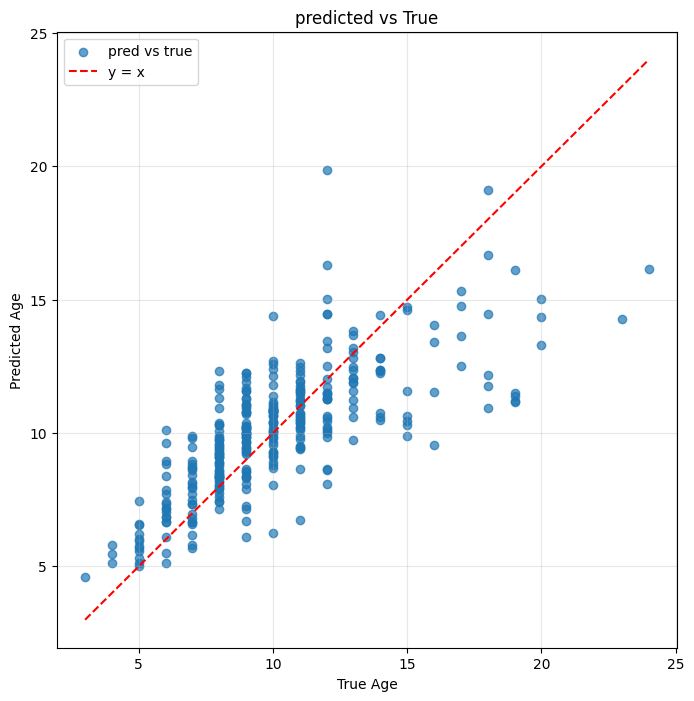

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 모델의 최종 성적표, 결과 시각화 완벽 이해하기]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 모델 훈련을 마친 후, 우리는 "그래서 이 모델이 얼마나 똑똑해졌는가?"라는 근본적인 질문에 답해야 합니다.
# `test_loss: 0.5312`와 같은 숫자만으로는 모델의 성능을 직관적으로 파악하기 어렵습니다.
# 시각화는 모델의 예측 결과를 사람의 눈으로 직접 확인할 수 있는 '성적표'를 만들어주는 과정입니다.
# 우리는 이 성적표(그래프)를 통해 모델이 어떤 예측은 잘하고 어떤 예측은 못하는지, 전반적인 경향은 어떤지 등을
# 한눈에 파악하고, 모델의 '진짜 실력'을 깊이 있게 이해할 수 있습니다.
#
# [핵심 비유: 학생의 최종 수능 시험 및 성적 분석]
#
# 1. 테스트 데이터셋 (`test_dataloader`): "한 번도 풀어본 적 없는 '실제 수능 시험지'"
#    - 이 시험지는 훈련(연습문제)이나 검증(모의고사) 과정에서 단 한 번도 사용되지 않은, 모델의 진짜 실력을
#      평가하기 위한 마지막 시험지입니다.
#
# 2. 모델 평가 루프 (`for test_batch in ...`): "수능 시험을 치르고, 예측 답안과 실제 정답을 수집하는 과정"
#    - 학생(모델)이 시험지의 모든 문제를 풀고, 학생이 제출한 답안지(`preds`)와
#      실제 정답지(`targets`)를 나란히 모아둡니다.
#
# 3. 시각화 (`matplotlib`): "수집한 답안지와 정답지를 바탕으로 '성적 분석 그래프' 그리기"
#    - 가로축(x축)에는 '실제 정답'을, 세로축(y축)에는 '학생의 답'을 점으로 찍어,
#      학생이 어떤 문제를 맞췄고 틀렸는지, 전반적인 실력이 어느 정도인지 한눈에 보여주는 그래프를 만듭니다.
#
# [지금 무엇을 하고 있는가?]
# 훈련을 마친 우리 모델을 최종 시험장에 들여보내 시험을 치르게 하고, 그 결과를 바탕으로
# 모델의 성능을 가장 직관적으로 분석할 수 있는 '예측-정답 비교 그래프'라는 성적표를 만드는 전 과정을 배우고 있습니다.
# ====================================================================================================


# --- 1. [1단계: 최종 시험] 테스트 데이터로 모델 성능 평가 ---
# [흐름] 훈련이 끝난 모델을 최종 테스트 데이터셋으로 평가하여, 예측값과 실제 정답값을 모두 수집하는 과정입니다.

# [구동 과정] `model.eval()`: 모델에게 "이제 시험 시간이야!"라고 알려주는 스위치입니다.
#            이 모드가 켜지면, Dropout 등 훈련 시에만 사용되던 기능들이 비활성화되어, 일관된 평가가 가능해집니다.
model.eval()
# [구동 과정] `with torch.no_grad():`: "지금부터는 채점만 할 거니까, 복잡한 오답 원인 분석(그래디언트 계산)은 잠시 멈춰줘!" 라고 지시합니다.
#           이 블록 안의 코드는 계산 흔적을 남기지 않으므로, 훨씬 적은 메모리를 사용하고 속도도 매우 빨라집니다.
with torch.no_grad():
    # [구동 과정] 평가 결과를 담을 빈 리스트들을 생성합니다.
    losses = []    # 각 배치의 오차 점수(loss)를 담을 리스트
    preds = []     # 모델의 예측 답안(`pred`)을 모두 모아둘 리스트
    targets = []   # 실제 정답(`y_test`)을 모두 모아둘 리스트

    # [구동 과정] `for test_batch in test_dataloader:`
    # `test_dataloader` (수능 시험지 묶음)에서 한 묶음의 문제('배치')를 꺼내 루프를 시작합니다.
    for test_batch in test_dataloader:
        # [구동 과정] 문제지와 정답지를 모델이 있는 책상(CPU/GPU)으로 보냅니다.
        x_test, y_test = test_batch[0].to(device), test_batch[1].to(device)
        # [구동 과정] 모델이 문제(`x_test`)를 풀고 예측 답안(`pred`)을 제출합니다. `.squeeze()`로 모양을 정리합니다.
        pred = model(x_test).squeeze()
        # [구동 과정] 채점 도구(`loss_fn`)로 오차 점수를 계산합니다.
        loss = loss_fn(pred, y_test)
        # [구동 과정] 계산된 오차 점수 텐서에서 숫자 값만 꺼내(`item()`) `losses` 리스트에 추가합니다.
        losses.append(loss.item())

        # --- [데이터 변환: GPU 전문가 -> CPU 범용 계산가 -> 시각화 아티스트] ---
        # [개념] `matplotlib` 같은 시각화 라이브러리는 GPU에 있는 PyTorch 텐서를 직접 다루지 못합니다.
        #        따라서 시각화를 위해, 데이터를 CPU로 가져온 뒤, 모두가 이해하는 공용어인 NumPy 배열로 변환하는 과정이 필요합니다.
        #
        # [구동 과정] `preds.extend(pred.cpu().numpy())`
        # 1. `pred.cpu()`: 만약 `pred` 텐서가 GPU에 있다면, 이 텐서를 CPU 메모리로 복사합니다. (CPU에 있다면 변화 없음)
        # 2. `.numpy()`: CPU로 온 텐서를 NumPy 배열로 변환합니다.
        # 3. `preds.extend(...)`: 변환된 예측값 NumPy 배열의 모든 원소를 `preds` 리스트의 끝에 추가합니다.
        preds.extend(pred.cpu().numpy())
        # [구동 과정] `targets.extend(y_test.cpu().numpy())`: 실제 정답값에 대해서도 위와 동일한 과정을 수행합니다.
        targets.extend(y_test.cpu().numpy())

    # [구동 과정] `test_loss_avg = sum(losses) / len(losses)`
    # 모든 배치의 오차 점수(`losses` 리스트)의 평균을 계산하여, 이번 수능 시험의 '평균 오차'를 구합니다.
    test_loss_avg = sum(losses) / len(losses)
    print(f'test_loss: {test_loss_avg:.4f}')


# --- 2. [2단계: 성적표 만들기] 결과 시각화 ---
# [흐름] 위에서 수집한 예측 답안(`preds`)과 실제 정답(`targets`)을 이용해, 모델의 성능을 한눈에 보여주는 그래프를 그립니다.

# [구동 과정] `import matplotlib.pyplot as plt`: 시각화 아티스트인 `matplotlib` 라이브러리를 `plt`라는 별명으로 불러옵니다.
import matplotlib.pyplot as plt

# [구동 과정] `plt.figure(figsize = (8, 8))`: 그림을 그릴 도화지를 준비합니다. 가로, 세로 크기를 각각 8인치로 설정합니다.
plt.figure(figsize = (8, 8))

# [구동 과정 심층 분석] `plt.scatter(...)`
# '산점도(scatter plot)'를 그리는 핵심 명령입니다. 점 하나하나를 찍어 데이터를 표현합니다.
# - `targets`: 모든 점의 **x축 위치**는 '실제 정답(나이)'이 됩니다.
# - `preds`: 모든 점의 **y축 위치**는 '모델의 예측(나이)'이 됩니다.
# - `alpha=0.7`: 점이 겹칠 때를 대비해, 점의 투명도를 70%로 설정합니다.
# - `label='pred vs true'`: 이 점들이 무엇을 의미하는지 범례에 표시될 이름을 정합니다.
# [결과 해석] 이 코드가 실행되면, 332개의 (실제 나이, 예측 나이) 쌍이 좌표평면에 점으로 찍힙니다.
plt.scatter(targets, preds, alpha = 0.7, label = 'pred vs true')

# [구동 과정 심층 분석] `plt.plot(..., 'r--')`
# 'y = x'에 해당하는 '완벽한 정답선'을 그리는 명령입니다.
# 1. `min_val`, `max_val`: 모든 실제값과 예측값 중 가장 작은 값과 가장 큰 값을 찾아, 그래프의 범위를 설정합니다.
# 2. `plt.plot([min_val, max_val], [min_val, max_val], ...)`: (min_val, min_val) 지점에서 (max_val, max_val) 지점까지 선을 긋습니다.
#    이것이 바로 y=x 직선입니다.
# 3. `'r--'`: 선의 스타일을 '빨간색(red) 점선(dashed line)'으로 설정합니다.
# [결과 해석] 이 선은 예측과 정답이 100% 일치하는 이상적인 상태를 나타냅니다.
min_val = min(min(targets), min(preds))
max_val = max(max(targets), max(preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label = 'y = x')

# [구동 과정] 그래프의 제목, x축/y축 이름 등 성적표를 꾸미는 과정입니다.
plt.title('predicted vs True') # 그래프 제목
plt.xlabel('True Age') # x축 라벨
plt.ylabel('Predicted Age') # y축 라벨
plt.legend() # `label`로 지정한 범례를 표시합니다.
plt.grid(alpha = 0.3) # 배경에 연한 격자 무늬를 추가하여 가독성을 높입니다.
# [구동 과정] `plt.show()`: 지금까지 설정한 모든 내용을 바탕으로, 최종 그래프를 화면에 "짠!"하고 보여줍니다.
plt.show()

# --- [그래프 최종 해석] ---
# - **파란색 점들이 빨간색 점선에 얼마나 가깝게 모여 있나요?**
#   - 점들이 빨간 선 주위에 좁고 빽빽하게 모여있을수록, 모델이 실제 정답에 매우 가깝게 예측했다는 의미이며, **성능이 좋은 모델**입니다.
#   - 점들이 빨간 선에서 멀리, 넓게 흩어져 있을수록, 모델의 예측이 많이 빗나갔다는 의미이며, **성능이 나쁜 모델**입니다.
# 이 그래프를 통해 우리는 모델의 전반적인 예측 정확도와 경향성을 숫자가 아닌 그림으로 직관적으로 파악할 수 있습니다.

# 모델 저장

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 모델의 '지식' 보존하기 (모델 저장 & 불러오기)]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 딥러닝 모델을 몇 시간, 며칠 동안 힘들게 학습시키는 것은 마치 RPG 게임에서 캐릭터를 며칠 밤낮으로 육성하는 것과 같습니다.
# 만약 게임을 끌 때 '저장'을 하지 않는다면, 힘들게 올린 레벨과 아이템은 모두 사라집니다. 모델 학습도 마찬가지입니다.
# 학습된 모델을 파일로 저장하는 것은, 우리의 모든 노력과 컴퓨터의 연산 결과를 보존하여 나중에 다시 사용하거나
# 다른 사람에게 공유하기 위한 필수적인 과정입니다.
# 이 코드에서는 PyTorch가 권장하는 가장 안전하고 유연한 방법, 즉 모델의 '뼈대(구조)'와 '영혼(학습된 지식)'을
# 분리하여 '영혼'만 저장하고 불러오는 방법을 배웁니다.
#
# [핵심 비유: 비디오 게임 저장 & 불러오기 🎮💾]
#
# 1. 모델의 구조 (클래스 코드, 예: `AbaloneModel`):
#    '게임 소프트웨어' 그 자체입니다. 게임의 규칙, 캐릭터 구조, 월드맵 등 모든 뼈대가 정의된
#    CD나 설치 파일과 같습니다.
#
# 2. 초기화된 모델 객체 (`model = AbaloneModel()`):
#    '새로 시작한 게임'입니다. 캐릭터는 레벨 1이고, 모든 능력치(가중치)는 기본값(무작위 초기값)입니다.
#
# 3. 학습된 모델의 상태 (`model.state_dict()`):
#    '게임 세이브 파일'입니다. 이 파일에는 게임 소프트웨어 전체가 들어있지 않습니다.
#    오직 '캐릭터의 성장 데이터'(레벨, 능력치, 아이템 등)만 기록되어 있습니다.
#    즉, 학습을 통해 얻어진 모델의 지식(가중치와 편향)이 바로 이것입니다.
# ====================================================================================================


# --- 1. 모델의 '지식' 저장하기 (게임 저장하기) ---
# [흐름] 열심히 훈련시켜 레벨 99가 된 우리 모델 캐릭터의 '능력치' 정보만 추출하여 '세이브 파일'로 만드는 과정입니다.

# [구동 과정 심층 분석] `torch.save(model.state_dict(), 'model.pth')`
# 1. `model.state_dict()`: "캐릭터, 현재 너의 모든 능력치(가중치)를 적은 '상태창'을 보여줘!"
#    - `model` 객체가 자신의 모든 학습 가능한 파라미터(예: 'fc1.weight', 'fc1.bias' 등)와
#      그에 해당하는 텐서(값)들을 파이썬 딕셔너리 형태로 반환합니다. 이것이 바로 '세이브 데이터'입니다.
# 2. `torch.save(..., 'model.pth')`: "이 '상태창' 내용을 'model.pth'라는 이름의 세이브 파일로 메모리카드에 저장해줘!"
#    - `torch.save` 함수가 이 딕셔너리를 받아, 'model.pth'라는 파일에 효율적인 형식으로 기록(저장)합니다.
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# --- 2. 저장된 '지식' 불러오기 및 모델에 적용하기 (게임 불러오기) ---
# [흐름] 새 컴퓨터에서 게임을 다시 할 때, 예전에 저장해 둔 세이브 파일을 불러와서 레벨 99 캐릭터를 복원하는 과정입니다.

# [구동 과정] `state_dict_loaded = torch.load('model.pth')`
# "메모리카드('model.pth')에서 세이브 파일을 읽어와 컴퓨터의 임시 기억장치(RAM)에 올립니다."
# - `torch.load` 함수가 'model.pth' 파일을 열어, 저장되어 있던 파라미터 딕셔너리를 메모리로 복원하고 `state_dict_loaded` 변수에 저장합니다.
state_dict_loaded = torch.load('model.pth')
print(state_dict_loaded) # 레벨 99짜리 캐릭터의 상세 능력치 목록이 보입니다.

OrderedDict({'fc1.weight': tensor([[ 0.0861,  0.1714, -0.4093,  0.1594, -0.1168,  0.0786,  0.2486],
        [ 0.1958, -0.1759, -0.1254,  0.2488, -0.1833,  0.1936, -0.2862],
        [ 0.2191,  0.2046, -0.1871,  0.0932, -0.1035, -0.1147, -0.1258],
        [-0.2427, -0.2979, -0.3302,  0.0233,  0.1407,  0.3091,  0.2334],
        [-0.3626,  0.2308, -0.2467,  0.1087, -0.2802, -0.1650,  0.0377],
        [ 0.1833, -0.0925, -0.3949,  0.1109,  0.1493,  0.1569, -0.2139],
        [ 0.1543, -0.2371,  0.1785,  0.0251, -0.0742,  0.1411, -0.3378],
        [ 0.0490,  0.3189, -0.3203, -0.4350,  0.3031, -0.3012,  0.0283],
        [-0.3850, -0.4197, -0.3961, -0.0256,  0.4127,  0.2460,  0.0617],
        [ 0.0139,  0.1087,  0.0747, -0.1106, -0.2112,  0.1526,  0.1908],
        [ 0.0262, -0.2332, -0.2570, -0.3046,  0.0917, -0.2106,  0.3238],
        [-0.3194,  0.0790, -0.1431, -0.3899,  0.3087, -0.3899,  0.2306],
        [ 0.2821,  0.0165,  0.2152, -0.2934,  0.2403,  0.0860, -0.3655],
        [-0.3541, -0.213

In [ ]:
# --- [가장 중요하고 헷갈리는 부분] ---
# [개념] "파이널 판타지 세이브 파일"을 불러오려면, 컴퓨터에 **"파이널 판타지 게임"이 먼저 설치되어 있어야 합니다.**
#        세이브 파일(가중치)은 데이터일 뿐, 그 데이터가 들어갈 '틀(모델 구조)'이 필요합니다.

# [구동 과정] `model_loaded = AbaloneModel()`:
# "새 컴퓨터에 파이널 판타지 게임(AbaloneModel)을 새로 설치합니다."
# - AbaloneModel 클래스(설계도)로부터 새로운 모델 객체를 생성합니다.
# - 이 순간, `__init__` 메서드가 실행되어 모든 레이어가 '무작위' 가중치로 초기화됩니다.
# - 지금 `model_loaded`는 막 게임을 시작한 '레벨 1짜리 캐릭터' 상태입니다.
model_loaded = AbaloneModel()

In [ ]:
# [구동 과정] `model_loaded.load_state_dict(state_dict_loaded)`:
# "새로 설치한 게임에, 예전에 했던 세이브 파일을 로드합니다."
# - `load_state_dict` 메서드는 `state_dict_loaded`(레벨 99 능력치 딕셔너리)를 가져와서,
#   `model_loaded`(레벨 1 캐릭터)의 파라미터들과 이름을 하나하나 비교합니다.
# - 이름이 같은 파라미터를 찾으면, `state_dict_loaded`에 있는 텐서 값을 `model_loaded`의 파라미터에 그대로 '복사하여 덮어씁니다'.
# - 이 명령이 실행되는 순간, 레벨 1 캐릭터의 모든 능력치는 레벨 99 캐릭터의 능력치로 완벽하게 교체됩니다.
model_loaded.load_state_dict(state_dict_loaded)

<All keys matched successfully>

In [ ]:
model_loaded.state_dict() # 실행하면, 이제 파라미터 값이 state_dict_loaded와 완전히 동일해진 것을 확인할 수 있습니다.
# 이로써 학습된 모델이 완벽하게 복원되었습니다.

OrderedDict([('fc1.weight',
              tensor([[ 0.0861,  0.1714, -0.4093,  0.1594, -0.1168,  0.0786,  0.2486],
                      [ 0.1958, -0.1759, -0.1254,  0.2488, -0.1833,  0.1936, -0.2862],
                      [ 0.2191,  0.2046, -0.1871,  0.0932, -0.1035, -0.1147, -0.1258],
                      [-0.2427, -0.2979, -0.3302,  0.0233,  0.1407,  0.3091,  0.2334],
                      [-0.3626,  0.2308, -0.2467,  0.1087, -0.2802, -0.1650,  0.0377],
                      [ 0.1833, -0.0925, -0.3949,  0.1109,  0.1493,  0.1569, -0.2139],
                      [ 0.1543, -0.2371,  0.1785,  0.0251, -0.0742,  0.1411, -0.3378],
                      [ 0.0490,  0.3189, -0.3203, -0.4350,  0.3031, -0.3012,  0.0283],
                      [-0.3850, -0.4197, -0.3961, -0.0256,  0.4127,  0.2460,  0.0617],
                      [ 0.0139,  0.1087,  0.0747, -0.1106, -0.2112,  0.1526,  0.1908],
                      [ 0.0262, -0.2332, -0.2570, -0.3046,  0.0917, -0.2106,  0.3238],
               

In [ ]:
# --- 3. 구조가 다른 모델에 상태를 불러오려고 할 때 (잘못된 게임에 세이브 파일 로드) ---
# [비유] 이것은 **"스타크래프트 세이브 파일"**을 **"월드 오브 워크래프트"**에 불러오려는 시도와 같습니다.

# [상황] 이 모델은 첫 번째 레이어의 출력 차원이 30으로, 원래 모델(32)과 구조가 다릅니다.
#       즉, 캐릭터의 '능력치 종류'나 '가방 크기'가 다른 새로운 게임입니다.
class AbaloneModel_ex(nn.Module):
    def __init__(self):
        super().__init__()
        # fc1 레이어의 출력 뉴런 수가 30개. 원본은 32개였음.
        self.fc1 = nn.Linear(7, 30)
        self.fc2 = nn.Linear(30, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# [구동 과정] `model_loaded2.load_state_dict(state_dict_loaded)`
# 1. `load_state_dict`는 `state_dict_loaded`(스타크래프트 세이브 파일)를 `model_loaded2`(워크래프트)에 덮어씌우려고 시도합니다.
# 2. 첫 번째 능력치인 `fc1.weight`를 비교합니다.
# 3. 스타크래프트 세이브 파일의 `fc1.weight` 모양은 `[32, 7]`인데,
#    워크래프트 캐릭터의 `fc1.weight` 모양은 `[30, 7]`입니다.
# 4. 모양(shape)이 다르므로, 데이터를 복사할 수 없습니다. "세이브 파일이 이 게임과 호환되지 않습니다!" 라는 `RuntimeError`를 발생시킵니다.
#    (에러 메시지 예: "size mismatch for fc1.weight: copying a param with shape torch.Size([32, 7]) from checkpoint,
#    the shape in current model is torch.Size([30, 7]).")
#
# try:
#     model_loaded2 = AbaloneModel_ex()
#     model_loaded2.load_state_dict(state_dict_loaded)
# except RuntimeError as e:
#     print(f"\n--- 구조가 다른 모델에 로드 시 에러 발생 ---\n{e}")

In [ ]:
# --- 4. 학습 중 모델 저장하기 (체크포인팅 / 중간 저장) ---
# [개념] 이것은 게임에서 **"어려운 보스전을 앞두고 중간 저장(체크포인트)"**을 하는 것과 같습니다.
#        몇 시간 동안 진행한 학습이 컴퓨터가 꺼지는 등의 이유로 날아가는 것을 방지하고,
#        학습 과정 중 가장 좋았던 시점을 기록하기 위한 매우 중요한 기술입니다.

# [구동 과정] 학습 루프를 다시 시작하기 위해 모델과 옵티마이저를 초기화합니다.
import torch.optim as optim
epochs = 10
step = 0
loss_fn = nn.MSELoss()
model = AbaloneModel().to(device)
opt = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# [전략 2를 위한 변수] 역대 최고 점수(가장 낮은 검증 손실)를 기록하기 위한 변수. 무한대로 초기화.
best_val_loss = float('inf')

# [구동 과정] `for epoch in range(epochs):` -> 총 10번의 게임 스테이지를 진행합니다.
for epoch in range(epochs):
    # --- 학습 과정 (이전과 동일) ---
    model.train()
    for train_batch in train_dataloader:
        x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)
        pred = model(x_train).squeeze()
        loss = loss_fn(pred, y_train)
        loss.backward()
        opt.step()
        opt.zero_grad()
        step += 1
        if step % 100 == 0:
            print(f"epoch : {epoch+1}, step : {step}, train loss: {loss.item():.4f}")

    # --- 검증 과정 (이전과 동일) ---
    model.eval()
    with torch.no_grad():
        losses = []
        for val_batch in val_dataloader:
            x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
            pred = model(x_val).squeeze()
            loss = loss_fn(pred, y_val)
            losses.append(loss.item())
        val_loss_avg = sum(losses)/len(losses)
        print(f'epoch {epoch+1}/{epochs}, val_loss : {val_loss_avg:.4f}\n')

    # --- [핵심] 똑똑하게 중간 저장하기 ---
    # [전략 1: 특정 주기로 저장]
    # 비유: "게임 스테이지를 10개 클리어할 때마다 무조건 저장하기"
    # [구동 과정] `if (epoch + 1) % 10 == 0:`
    # 현재 에포크 숫자에 1을 더한 값이 10으로 나누어 떨어질 때만 (즉, 10, 20, 30... 에포크일 때만) 아래 저장 코드를 실행합니다.
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pt')
        print(f"--- Epoch {epoch+1} 모델 저장 완료 ---")

    # [전략 2: 최고 성능 모델 저장 (Best Practice)]
    # 비유: "게임을 하다가 '역대 최고 점수'를 경신했을 때만, 그 순간을 '최고 기록'으로 저장하기"
    # [개념] 이 방법이 가장 널리 쓰이는 좋은 전략입니다. 학습이 진행되다가 오히려 성능이 나빠지는 경우(과적합)가 있는데,
    #       이 전략을 사용하면 그런 경우와 상관없이 학습 전 과정에서 가장 성능이 좋았던 '전성기' 시절의 모델을 확보할 수 있습니다.
    # [구동 과정]
    # 1. 현재 에포크의 평균 검증 손실(`val_loss_avg`)이 역대 최저 손실(`best_val_loss`)보다 더 낮은지 비교합니다.
    if val_loss_avg < best_val_loss:
        # 2. 만약 더 낮다면 (성능이 더 좋다면),
        print(f"*** 최고 성능 경신! (이전: {best_val_loss:.4f} -> 현재: {val_loss_avg:.4f}) ***")
        # 2-1. `torch.save`를 호출하여 현재 모델의 상태를 '최고 기록' 파일('model_best.pt')에 저장(덮어쓰기)합니다.
        torch.save(model.state_dict(), 'model_best.pt')
        # 2-2. `best_val_loss` 변수의 값을 현재의 더 낮은 손실값으로 업데이트하여, 다음 에포크에서 비교할 수 있도록 합니다.
        best_val_loss = val_loss_avg

epoch 1/10, val_loss : 5.0342

*** 최고 성능 경신! (이전: inf -> 현재: 5.0342) ***
epoch : 2, step : 100, train loss: 6.0892
epoch 2/10, val_loss : 4.0948

*** 최고 성능 경신! (이전: 5.0342 -> 현재: 4.0948) ***
epoch : 3, step : 200, train loss: 4.8214
epoch 3/10, val_loss : 3.9237

*** 최고 성능 경신! (이전: 4.0948 -> 현재: 3.9237) ***
epoch : 4, step : 300, train loss: 3.4511
epoch 4/10, val_loss : 3.8642

*** 최고 성능 경신! (이전: 3.9237 -> 현재: 3.8642) ***
epoch : 5, step : 400, train loss: 2.8725
epoch 5/10, val_loss : 3.8588

*** 최고 성능 경신! (이전: 3.8642 -> 현재: 3.8588) ***
epoch 6/10, val_loss : 3.9250

epoch : 7, step : 500, train loss: 5.3534
epoch 7/10, val_loss : 3.9363

epoch : 8, step : 600, train loss: 3.7696
epoch 8/10, val_loss : 3.8390

*** 최고 성능 경신! (이전: 3.8588 -> 현재: 3.8390) ***
epoch : 9, step : 700, train loss: 2.9672
epoch 9/10, val_loss : 3.6226

*** 최고 성능 경신! (이전: 3.8390 -> 현재: 3.6226) ***
epoch : 10, step : 800, train loss: 4.7065
epoch 10/10, val_loss : 3.5892

--- Epoch 10 모델 저장 완료 ---
*** 최고 성능 경신! 

# torch.nn.functional

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: PyTorch의 두 가지 얼굴, 객체(nn.Module)와 함수(F.functional) 완벽 구분하기]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# PyTorch는 신경망의 부품을 만드는 두 가지 방식을 제공합니다. 이는 마치 우리가 '가구'를 얻는 두 가지 방법과 같습니다.
#
# 1. nn.Module 객체 방식: 'IKEA 가구' 구매하기
#    - `nn.Linear`, `nn.Conv2d` 등은 학습 가능한 '상태(가중치, 편향)'를 가진 복잡한 부품입니다.
#    - 이들은 IKEA에서 판매하는 '조립식 가구'와 같습니다. 한 번 구매(객체 생성)해서 우리 집(`__init__`)에 설치해두면,
#      가구 자체의 속성(색상, 크기 등)이 유지되면서 계속해서 사용할 수 있습니다.
#    - '상태'를 저장하고 관리해야 하므로, 반드시 객체로 만들어 사용해야 합니다.
#
# 2. torch.nn.functional (F) 함수 방식: '망치나 드라이버' 사용하기
#    - `F.relu`, `F.max_pool2d` 등은 학습할 파라미터가 없는 단순한 '연산'입니다.
#    - 이들은 '망치'나 '드라이버' 같은 '연장'과 같습니다. 연장을 우리 집에 '설치'해두지는 않습니다.
#      필요할 때마다 연장통(`F`)에서 꺼내서 한 번 사용하고, 다시 넣어둡니다.
#    - '상태'가 없으므로, 굳이 객체로 만들어 관리할 필요 없이 필요할 때마다 함수로 바로 호출하는 것이 더 간결하고 효율적입니다.
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금 PyTorch라는 거대한 공방에서, 언제 '복잡한 기계(nn.Module 객체)'를 설치해서 써야 하고,
# 언제 '간단한 연장(F.functional 함수)'을 꺼내 써야 하는지에 대한 프로페셔널한 사용법을 배우고 있습니다.
# 더불어, 텐서라는 '목재'를 다룰 때, 원본을 보존하며 새로운 목재를 만들어내는 '안전한 방식(out-of-place)'과
# 원본 목재 자체를 깎아내는 '위험하지만 효율적인 방식(in-place)'의 차이점도 함께 알아봅니다.
# ====================================================================================================


# --- 0. 기본 도구 준비 ---
import torch
import torch.nn as nn
# [구동 과정 심층 분석] `import torch.nn.functional as F`
# 1. `torch.nn` 모듈 안에 있는 `functional`이라는 하위 모듈을 가져옵니다.
# 2. 이 모듈에는 학습 가능한 파라미터가 없는 수많은 함수(relu, softmax, mse_loss 등)들이 들어있습니다.
# 3. `as F`는 "앞으로 이 긴 이름을 `F`라는 짧은 별명으로 부르겠다"는 약속입니다.
#    이는 PyTorch 개발자들 사이의 표준적인 관례(convention)입니다.
import torch.nn.functional as F


# --- 1. nn.Module 객체 방식 vs. nn.functional 함수 방식 ---
# [흐름] 동일한 기능(ReLU, MSELoss, MaxPool2d)을 두 가지 다른 방식으로 구현해보며 그 차이점을 명확히 이해합니다.

# --- [1-1. ReLU 예시: 비선형 활성화] ---
print("--- ReLU 예시 ---")
# [구동 과정] `x`라는 변수에 (2, 4) 모양의, 무작위 숫자로 채워진 텐서를 생성하여 저장합니다.
x = torch.randn(2, 4)

# [방법 1: nn.Module 객체 방식 - "ReLU 기계를 작업실에 설치하기"]
# [구동 과정] `relu_obj = nn.ReLU()`:
# `nn.ReLU` 클래스(설계도)를 이용해, ReLU 연산을 수행하는 `relu_obj`라는 객체(기계)를 생성합니다.
# 이 객체는 내부에 학습할 파라미터는 없지만, `nn.Module`의 모든 표준 기능을 상속받습니다.
relu_obj = nn.ReLU()
# [구동 과정] `y_obj = relu_obj(x)`:
# 설치된 `relu_obj` 기계에 `x`라는 재료를 넣어 작동시킵니다. 그 결과물이 `y_obj`에 저장됩니다.
y_obj = relu_obj(x)

# [방법 2: F.functional 함수 방식 - "연장통에서 ReLU 망치를 꺼내 쓰기"]
# [구동 과정] `y_func = F.relu(x)`:
# `F`라는 연장통에서 `relu`라는 함수(망치)를 꺼내, `x`라는 재료에 바로 사용합니다.
# 객체를 생성하는 중간 단계 없이, 한 줄로 즉시 결과를 얻습니다. 훨씬 간결합니다.
y_func = F.relu(x)


# --- [1-2. 손실 함수 예시: MSE Loss] ---
print("\n--- 손실 함수 예시 ---")
# [구동 과정] 예측값과 정답값에 해당하는 가상의 텐서를 각각 생성합니다.
pred = torch.randn(4)
y_train = torch.randn(4)

# [방법 1: 객체 방식 - "MSE 채점 기계 준비하기"]
loss_fn_obj = nn.MSELoss()
loss_obj = loss_fn_obj(pred, y_train)

# [방법 2: 함수 방식 - "MSE 채점 공식 바로 적용하기"]
loss_func = F.mse_loss(pred, y_train)


# --- [1-3. 풀링 레이어 예시: Max Pooling] ---
print("\n--- 풀링 레이어 예시 ---")
# [구동 과정] CNN에서 사용되는 (배치, 채널, 높이, 너비) 모양의 4차원 이미지 텐서를 가정하여 생성합니다.
image_tensor = torch.randn(1, 1, 4, 4)

# [방법 1: 객체 방식 - "맥스 풀링 기계 설치하기"]
# [구동 과정] `nn.MaxPool2d(...)`: `kernel_size`와 `stride` 같은 '기계 설정값'을 객체 생성 시 미리 지정합니다.
maxpool_obj = nn.MaxPool2d(kernel_size=2, stride=2)
pooled_obj = maxpool_obj(image_tensor)

# [방법 2: 함수 방식 - "맥스 풀링 연장 사용하기"]
# [구동 과정] `F.max_pool2d(...)`: 연산에 필요한 `kernel_size`, `stride` 같은 '옵션'들을 함수 호출 시에 직접 전달합니다.
pooled_func = F.max_pool2d(image_tensor, kernel_size=2, stride=2)


# [결론 및 전문가 가이드라인]
# - **학습할 파라미터가 있는가? (예: `nn.Linear`) -> Yes**: 반드시 `__init__`에서 **`nn.Module` 객체**로 생성해야 합니다.
#                                                           PyTorch가 이 객체의 파라미터를 '학습 대상'으로 인식하고 추적하기 때문입니다.
# - **학습할 파라미터가 없는가? (예: `ReLU`, `MaxPool2d`) -> Yes**: 모델의 `forward` 메서드 안에서 **`F.functional` 함수**를
#                                                                   직접 사용하는 것이 코드를 더 깔끔하고 간결하게 만듭니다.
#   (물론 `nn.ReLU` 객체로 만들어도 기능상 문제는 전혀 없지만, 굳이 '설치'할 필요 없는 간단한 '연장'을 설치하는 것과 같습니다.)


# --- 2. In-place 연산: 원본을 수정하는 위험한 기술 ---
# [개념] 파이토치의 연산은 대부분 'out-of-place' 방식, 즉 원본을 보존하고 결과를 새롭게 만들어내는 '안전한' 방식입니다.
#        하지만 'in-place'는 원본 데이터 자체를 직접 수정하여 덮어쓰는 '위험하지만' 메모리 효율적인 방식입니다.

# --- [2-1. Out-of-place (안전한 방식) 예시] ---
# [비유] 수학 문제를 풀 때, 이전 줄의 계산 결과를 그대로 두고 '다음 줄에' 새로운 계산 결과를 쓰는 방식입니다.
print("\n--- Out-of-place 연산 예시 ---")
# [구동 과정] `x = torch.ones(1, 4)`: (1, 4) 모양의 2차원 텐서를 생성하여 `x`에 저장합니다.
x = torch.ones(1, 4)
# [구동 과정] `x_sq = x.squeeze()`:
# 1. `x.squeeze()` 메서드가 호출됩니다.
# 2. 이 메서드는 `x`의 내용물을 바탕으로 squeeze 연산을 수행한 결과를 담은 **새로운 텐서**를 메모리의 **새로운 공간**에 생성합니다.
# 3. 이 새로 생성된 텐서가 `x_sq` 변수에 저장됩니다.
# 4. **원본 `x` 텐서는 이 과정에서 전혀 영향을 받지 않고 그대로 유지됩니다.**
x_sq = x.squeeze()

print(f"원본 텐서 x의 모양: {x.size()}")
print(f"결과 텐서 x_sq의 모양: {x_sq.size()}")

# --- [2-2. In-place (위험한 방식) 예시] ---
# [비유] 수학 문제를 풀 때, 이전 줄의 계산 결과를 '지우개로 지우고 그 위에' 새로운 계산 결과를 덮어쓰는 방식입니다.
#        파이토치에서는 이러한 연산 메서드 이름 끝에 보통 밑줄(`_`)을 붙여 구분합니다. (예: `add_`, `squeeze_`)
print("\n--- In-place 연산 예시 ---")
# [구동 과정] 다시 (1, 4) 모양의 텐서를 생성하여 `x`에 저장합니다.
x = torch.ones(1, 4)
# [구동 과정] `x.squeeze_()`:
# 1. `squeeze_()` 메서드가 호출됩니다.
# 2. 이 메서드는 새로운 텐서를 만들지 않습니다. 대신, **`x` 텐서가 차지하고 있는 메모리 공간으로 직접 찾아가**
#    그 내부의 데이터를 squeeze 연산 결과로 **직접 수정하고 덮어씁니다.**
# 3. `x` 변수는 여전히 똑같은 메모리 주소를 가리키고 있지만, 그 안의 내용물이 바뀌어버렸습니다.
x.squeeze_()

print(f"squeeze_() 호출 후 원본 x의 모양: {x.size()}")


# --- [In-place 연산의 치명적인 단점] ---
# - **역전파(Backpropagation) 방해**: PyTorch의 자동 미분 시스템('Autograd')은 기울기를 계산하기 위해 순전파 때의
#   '계산 과정과 중간 값들'을 기억해두어야 합니다. In-place 연산으로 원본 텐서의 값이 바뀌어 버리면,
#   기울기 계산에 필요했던 이전 값이 사라져버려 "계산 기록이 손상되었습니다!" 라는 `RuntimeError`를 유발할 수 있습니다.
#   (비유: 학생이 풀이 과정을 지우고 답만 써놓으면, 선생님은 학생이 어디서 틀렸는지 분석할 수 없는 것과 같습니다.)
#
# [최종 권장사항]
# 메모리 효율이 정말 정말 극단적으로 중요하고, 기울기 계산이 필요 없는 제한적인 상황이 아니라면,
# 코드의 안정성과 예측 가능성을 위해 **in-place 연산(`_`가 붙은 메소드)의 사용은 가급적 피하는 것이 좋습니다.**
# 딥러닝 모델의 `forward` 메서드 안에서는 절대 사용하지 않는다고 생각하셔도 무방합니다.

--- ReLU 예시 ---

--- 손실 함수 예시 ---

--- 풀링 레이어 예시 ---

--- Out-of-place 연산 예시 ---
원본 텐서 x의 모양: torch.Size([1, 4])
결과 텐서 x_sq의 모양: torch.Size([4])

--- In-place 연산 예시 ---
squeeze_() 호출 후 원본 x의 모양: torch.Size([4])
